# Lección 7.2 · Mapeo en la práctica: BWA-MEM, minimap2 y samtools

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-07-mapeo/7.2_bwa_minimap2_samtools.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 7 — Mapeo de lecturas** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lecciones 2.1 (SAM, CIGAR, FLAG), 3.2 (programación dinámica), 3.4 (BLAST), 7.1 (BWT e índice FM), 6.2 (lecturas de *E. coli* y su limpieza) y 6.3 (cobertura) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué no se puede alinear cada lectura contra todo el genoma con programación dinámica y cómo la
   estrategia **semilla → encadenamiento → extensión** (*seed–chain–extend*) reduce el problema en muchos órdenes de
   magnitud.
2. **Calcular a mano** los **minimizers** de una secuencia (ventana $w$, $k$-meros, orden), **demostrar** que su
   densidad esperada es $2/(w+1)$ y **verificarlo** sobre el genoma real de *E. coli* B REL606.
3. **Programar** un mapeador de juguete completo en NumPy (índice de minimizers, encadenamiento por programación
   dinámica y extensión Smith–Waterman con bandas) y **comparar** sus resultados con BWA-MEM.
4. **Interpretar** la calidad de mapeo $\operatorname{MAPQ} = -10\log_{10}\big(1-\Pr(\hat u\mid q)\big)$, **derivarla** de
   las candidatas (definición bayesiana, fórmula empírica de minimap2 y puntuación de pares $S_{ij}$ de BWA-MEM) y
   **explicar** por qué las lecturas de los operones de rRNA y de los elementos IS1 reciben MAPQ 0.
5. **Ejecutar** el flujo profesional en Colab: `bwa index`, `bwa mem` con pares, `samtools fixmate -m → sort →
   markdup → index`, el filtro `-F 0x904`, `flagstat/stats/idxstats/depth`, la conversión a **CRAM** y
   `minimap2 -ax sr`, y **leer** el BAM resultante con **pysam**.
6. **Diagnosticar** un mapeo con datos reales: distribución de MAPQ, orientación de los pares (FR/RF), tamaño de
   inserto, errores por ciclo a partir de las etiquetas `NM`/`MD`, recortes suaves (*soft clipping*) y perfil de
   cobertura a lo largo del genoma.
7. **Comparar** BWA-MEM, minimap2 y nuestro mapeador (tiempo, fracción mapeada, concordancia de posiciones) y
   **mapear** lecturas largas con `minimap2 -x map-ont` para resolver las repeticiones que las lecturas cortas no pueden.

## 🗺️ Mapa de la clase

1. Del alineamiento al mapeo: ¿por qué no basta con Smith–Waterman?
2. 🧪 Los datos: el genoma de *E. coli* B REL606, sus repeticiones y las lecturas de la Lección 6.2 (y el mapeo como un $\arg\max$ sobre dos hebras)
3. La estrategia semilla → encadenamiento → extensión (SMEM, *X-drop*, BWA-SW y Bowtie 2)
4. Minimizers a mano y su densidad $2/(w+1)$ (🎬 animación)
5. Un mapeador de juguete en NumPy (🎬 animación de una lectura mapeándose)
6. La calidad de mapeo (MAPQ) y las lecturas multimapeadas (definición bayesiana y fórmula de minimap2)
7. 🧪 El flujo real en Colab: BWA-MEM, `fixmate` → `sort` → `markdup` → `index`, el filtro `-F 0x904`, CRAM y minimap2
8. Leer el BAM con pysam: MAPQ, pares y su puntuación $S_{ij}$, errores por ciclo y cobertura (🔍 interactivos)
9. BWA-MEM vs minimap2 vs nuestro mapeador
10. Lecturas largas: cuando la lectura es más larga que la repetición
11. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, gzip, json, time, shutil, subprocess
from collections import Counter
from numpy.lib.stride_tricks import sliding_window_view
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle

try:
    import pysam                                   # lectura de SAM/BAM desde Python (envuelve htslib y samtools)
except ImportError:
    %pip install -q pysam
    import pysam

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (NCBI…);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def course_file(name):
    """Deja una copia local de un archivo del curso y devuelve su ruta (para herramientas de línea de comandos)."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        open(name, "wb").write(course_bytes(name))
    return name

rng = np.random.default_rng(72)       # semilla fija: todos obtenemos los mismos números
print("pysam", pysam.__version__, "· Listo para la Lección 7.2")

Entorno listo ✔  |  Colab: False
pysam 0.24.1 · Listo para la Lección 7.2


## 1. Del alineamiento al mapeo: ¿por qué no basta con Smith–Waterman?

En el Módulo 3 aprendimos a alinear dos secuencias con programación dinámica: Needleman–Wunsch para alineamientos
globales y Smith–Waterman para locales (Lección 3.2). Esos algoritmos son **exactos**: garantizan encontrar el mejor
alineamiento según el sistema de puntuación. Su problema es el costo. Llenar la matriz exige una celda por cada par
(posición de la lectura, posición del genoma).

Hagamos la cuenta con los datos de hoy, los **30 000 pares** de lecturas de *E. coli* que limpiamos en la Lección 6.2:

| Magnitud | Valor |
|---|---|
| Lecturas | $n = 60\,000$ (30 000 pares) |
| Longitud de cada lectura | $L = 150$ |
| Longitud del genoma | $G \approx 4.63 \times 10^{6}$ pb |
| Celdas por lectura (Smith–Waterman contra todo el genoma, dos hebras) | $2\,L\,G \approx 1.4 \times 10^{9}$ |
| Celdas en total | $2\,n\,L\,G \approx 8.3 \times 10^{13}$ |

Aunque un programa en C optimizado llene mil millones de celdas por segundo, tardaría **casi un día** en mapear un
archivo que BWA-MEM procesa en **un segundo**. Y un experimento real no tiene 60 000 lecturas, sino cientos de millones,
contra genomas mil veces más grandes (el humano tiene 3 100 Mb).

Es como buscar en qué página de una enciclopedia aparece una frase: nadie la lee de principio a fin comparando letra
por letra. Se usa el **índice** alfabético: se busca una palabra poco común de la frase, el índice dice en qué páginas
aparece, y sólo esas pocas páginas se leen con cuidado. Los mapeadores hacen exactamente eso:

* **Indexan** el genoma una sola vez (segundos o minutos), guardando dónde aparece cada "palabra" corta.
* Para cada lectura, buscan en el índice unas pocas palabras (las **semillas**), que señalan un puñado de posiciones
  candidatas.
* Sólo en esas candidatas hacen la programación dinámica, y además restringida a una **banda** estrecha alrededor de la
  diagonal.

A esta tarea (encontrar el origen de millones de lecturas cortas en un genoma de referencia conocido) se le llama
**mapeo** (*read mapping*), para distinguirla del alineamiento general de dos secuencias. Hoy veremos cómo lo hacen
los dos mapeadores más usados del mundo, **BWA-MEM** (Li, 2013) y **minimap2** (Li, 2018), programaremos un mapeador
pequeño con sus mismas ideas y aprenderemos a interpretar su salida con **samtools** (Danecek *et al.*, 2021).

Antes de seguir, midamos la velocidad real de una programación dinámica escrita en Python puro, la misma que usaremos
en la sección 5, para convertir la tabla anterior en tiempos concretos.

In [2]:
def sw_score(q, r, match=1, mismatch=4, gap=6):
    """Smith–Waterman completo (sólo la puntuación), en Python puro, para medir su velocidad."""
    prev = [0] * (len(r) + 1)
    best = 0
    for qi in q:
        cur = [0] * (len(r) + 1)
        for j, rj in enumerate(r, start=1):
            v = max(0, prev[j - 1] + (match if qi == rj else -mismatch), prev[j] - gap, cur[j - 1] - gap)
            cur[j] = v
            best = v if v > best else best
        prev = cur
    return best

demo_q = "".join(rng.choice(list("ACGT"), 150))
demo_r = "".join(rng.choice(list("ACGT"), 2000))
t0 = time.perf_counter()
sw_score(demo_q, demo_r)
cells_per_s = 150 * 2000 / (time.perf_counter() - t0)

n_reads, L, G = 60_000, 150, 4_629_812
cells = 2 * n_reads * L * G
speeds = {"SW en Python puro (medido)": cells_per_s,
          "SW en C (10⁹ celdas/s)": 1e9,
          "SW SIMD, 16 núcleos (10¹¹ celdas/s)": 1e11}
for k, v in speeds.items():
    print(f"{k:58s}: {cells / v / 86400:>12,.1f} días")
print(f"\nCeldas totales: {cells:.2e} · velocidad de Python medida: {cells_per_s:,.0f} celdas/s")

SW en Python puro (medido)                                :        149.4 días
SW en C (10⁹ celdas/s)                                    :          1.0 días
SW SIMD, 16 núcleos (10¹¹ celdas/s)                       :          0.0 días

Celdas totales: 8.33e+13 · velocidad de Python medida: 6,458,106 celdas/s


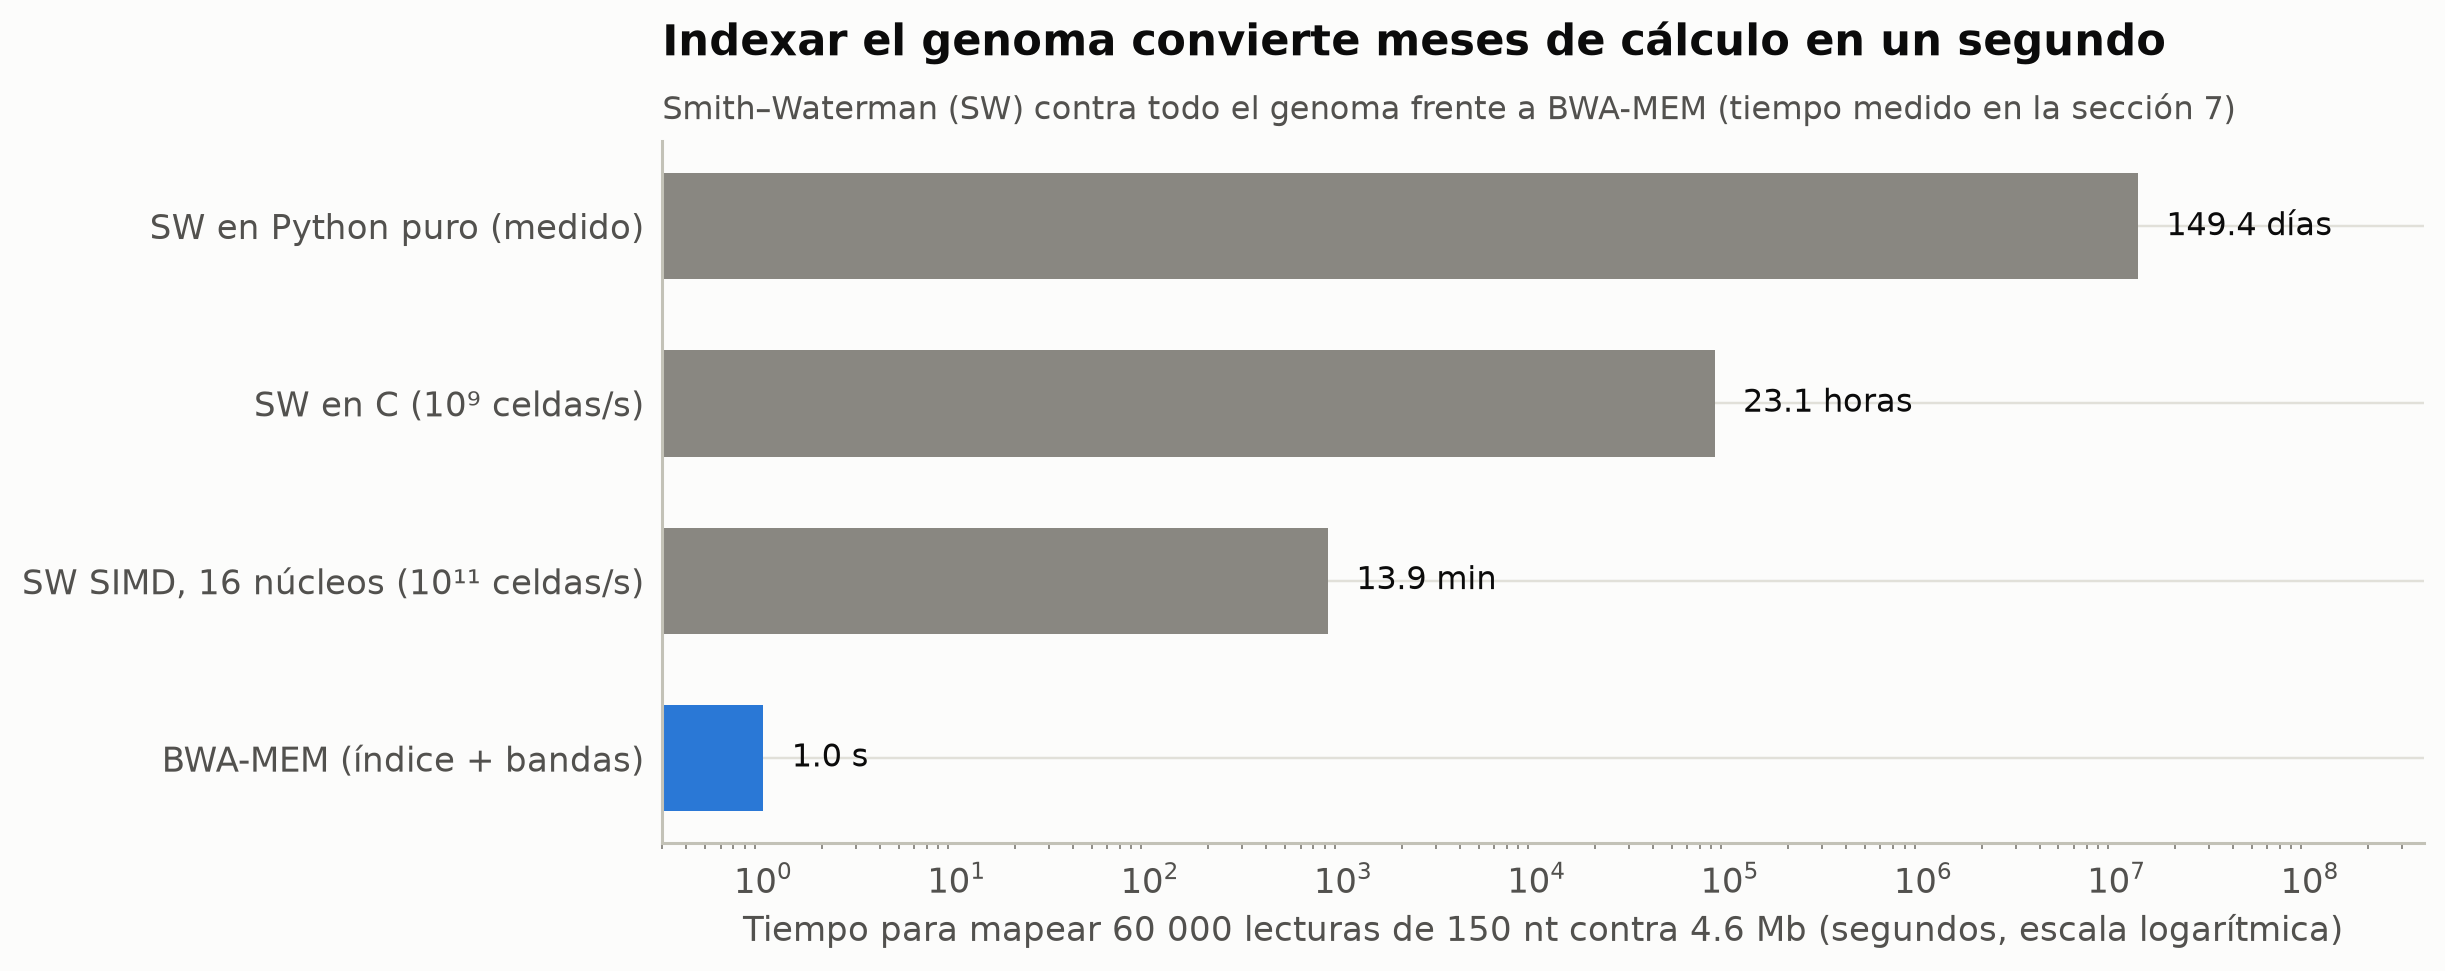

In [3]:
labels = list(speeds) + ["BWA-MEM (índice + bandas)"]
seconds = [cells / v for v in speeds.values()] + [1.0]
fig, ax = plt.subplots(figsize=(11, 4.3))
cols = [ec.MUTED, ec.MUTED, ec.MUTED, ec.BLUE]
y = np.arange(len(labels))[::-1]
ax.barh(y, seconds, color=cols, height=0.6)
ax.set_xscale("log")
units = [(86400 * 365, "años"), (86400, "días"), (3600, "horas"), (60, "min"), (1, "s")]
for yi, s in zip(y, seconds):
    u, name = next((u, n) for u, n in units if s >= u) if s >= 1 else (1, "s")
    ax.text(s * 1.4, yi, f"{s / u:,.1f} {name}", va="center", fontsize=10.5, color=ec.INK)
ax.set_yticks(y, labels)
ax.set_xlim(0.3, max(seconds) * 30)
ax.set_xlabel("Tiempo para mapear 60 000 lecturas de 150 nt contra 4.6 Mb (segundos, escala logarítmica)")
ec.title(ax, "Indexar el genoma convierte meses de cálculo en un segundo",
         "Smith–Waterman (SW) contra todo el genoma frente a BWA-MEM (tiempo medido en la sección 7)")
plt.show()

> 🔎 **Qué observamos.** Cada barra está en escala logarítmica: la diferencia entre Python puro y BWA-MEM no es de
> 10 veces, sino de **varios millones** de veces. Ni siquiera el hardware más rápido salva la programación dinámica
> exhaustiva; lo que la salva es **no hacerla** en casi todo el genoma. El índice descarta de antemano el
> 99.999 % de las posiciones, y la DP sólo se aplica donde ya sabemos que hay una coincidencia prometedora. Es la
> misma idea de BLAST (Lección 3.4), llevada al extremo para millones de lecturas casi idénticas a la referencia.

## 2. 🧪 Los datos: el genoma de *E. coli* B REL606, sus repeticiones y las lecturas de la Lección 6.2

### La referencia correcta

Las lecturas de la Lección 6.2 (corrida **SRR2584863**) vienen de un clon del experimento de evolución a largo plazo de
Lenski (Tenaillon *et al.*, 2016). Todos los clones de ese experimento descienden del ancestro ***E. coli* B REL606**,
cuyo genoma completo está en RefSeq con el número de acceso **NC_012967.1** (Jeong *et al.*, 2009): un único cromosoma
**circular** de 4 629 812 pb. Mapear contra la referencia del ancestro, y no contra *E. coli* K-12, es lo correcto: así
las diferencias que veamos serán mutaciones del clon y no las decenas de miles de diferencias que separan a las cepas
B y K-12.

La celda descarga el FASTA con **Entrez** (`efetch` de NCBI) si no encuentra la copia del curso (`data/`), y comprueba
la longitud. Guardamos también la anotación (genes, rRNA, tRNA) en una tabla comprimida.

In [4]:
ACC = "NC_012967.1"
EFETCH = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACC}&rettype=fasta&retmode=text"
raw_fa = course_bytes(f"{ACC}.fasta.gz", live_url=EFETCH)
fa_text = gzip.decompress(raw_fa).decode() if raw_fa[:2] == b"\x1f\x8b" else raw_fa.decode()
if not os.path.exists("REL606.fa"):                  # copia sin comprimir para bwa/minimap2
    open("REL606.fa", "w").write(fa_text)
ref_header = fa_text.splitlines()[0]
genome = "".join(fa_text.splitlines()[1:]).upper()
G = len(genome)
assert G == 4_629_812, "La longitud no coincide con NC_012967.1"
gc = (genome.count("G") + genome.count("C")) / G
print(ref_header)
print(f"Longitud: {G:,} pb · GC = {gc:.1%} · bases distintas de ACGT: {G - sum(genome.count(b) for b in 'ACGT')}")

feat = pd.read_csv(io.BytesIO(course_bytes(f"{ACC}_features.tsv.gz")), sep="\t", comment="#", compression="gzip")
feat["product"] = feat["product"].fillna("")
print(feat.type.value_counts().to_string())

>NC_012967.1 Escherichia coli B str. REL606, complete sequence
Longitud: 4,629,812 pb · GC = 50.8% · bases distintas de ACGT: 0
type
CDS              4391
tRNA               85
rRNA               22
ncRNA               8
repeat_region       2
tmRNA               1


### Las repeticiones: el enemigo natural del mapeo

Un genoma bacteriano es casi todo **secuencia única**: cada tramo de 150 pb aparece una sola vez. Pero hay excepciones
importantes, y son justamente las que ponen a prueba a un mapeador:

* **Operones de ARN ribosómico (*rrn*)**. *E. coli* tiene **siete** copias del operón 16S–23S–5S, de unos 5 kb cada
  una. La célula necesita producir muchísimos ribosomas, y varias copias del mismo operón multiplican la producción.
  Las copias son casi idénticas entre sí porque la recombinación entre ellas las homogeniza continuamente.
* **Secuencias de inserción (elementos IS)**. Son transposones mínimos, de 0.7 a 2.5 kb, que sólo codifican la
  transposasa que los mueve. Cada copia nueva es idéntica a la original. El genoma de REL606 está especialmente cargado
  de **IS1** (768 pb), y el IS150 es el responsable de muchas de las mutaciones del experimento de Lenski.

Una lectura de 150 pb que cae **dentro** de una de esas copias no tiene forma de saber de cuál de ellas vino. Veamos
cuántas hay en la anotación.

In [5]:
rrna = feat[feat.type == "rRNA"].sort_values("start")
operons = []                                   # agrupar 16S, 23S y 5S vecinos en operones
for s, e, st in zip(rrna.start, rrna.end, rrna.strand):
    if operons and s - operons[-1][1] < 1000:
        operons[-1][1] = max(operons[-1][1], e)
    else:
        operons.append([s, e, st])
operons = pd.DataFrame(operons, columns=["start", "end", "strand"])
operons["name"] = [f"rrn-{i + 1}" for i in range(len(operons))]
operons["length"] = operons.end - operons.start + 1

cds = feat[feat.type == "CDS"]
is_mask = cds["product"].str.contains(r"^IS|\bIS\d|transposase", regex=True) & ~cds["product"].str.contains("REP-associated|Rpn")
is_elems = cds[is_mask].copy()
is_elems["family"] = is_elems["product"].str.extract(r"(IS\w+)")[0].fillna("otra transposasa")
is1 = is_elems[is_elems["product"].str.contains("IS1A family|IS1 family", regex=True)]

print(f"Operones rrn: {len(operons)}")
print(operons.to_string(index=False))
print(f"\nCDS de transposasas de elementos IS: {len(is_elems)} · de ellas, IS1: {len(is1)}")
print(is_elems.family.value_counts().head(8).to_string())

Operones rrn: 7
  start     end strand  name  length
 226609  231797      + rrn-1    5189
2647562 2652564      - rrn-2    5003
3351317 3356667      - rrn-3    5351
3903615 3908617      + rrn-4    5003
4013904 4019099      + rrn-5    5196
4146520 4151533      + rrn-6    5014
4187734 4192830      + rrn-7    5097

CDS de transposasas de elementos IS: 70 · de ellas, IS1: 28
family
IS1                 28
IS3                 17
IS4                  7
ISAs1                7
otra transposasa     5
IS200                1
ISL3                 1
ISNCY                1


¿Qué tan parecidas son las copias? Los genes 16S de los siete operones miden exactamente lo mismo (1 542 pb), así que
podemos compararlos posición por posición sin alinear: basta con poner cada copia en la misma orientación (las copias
en la hebra − se toman en complemento inverso) y contar diferencias.

Longitudes de las copias de 16S: {1542}


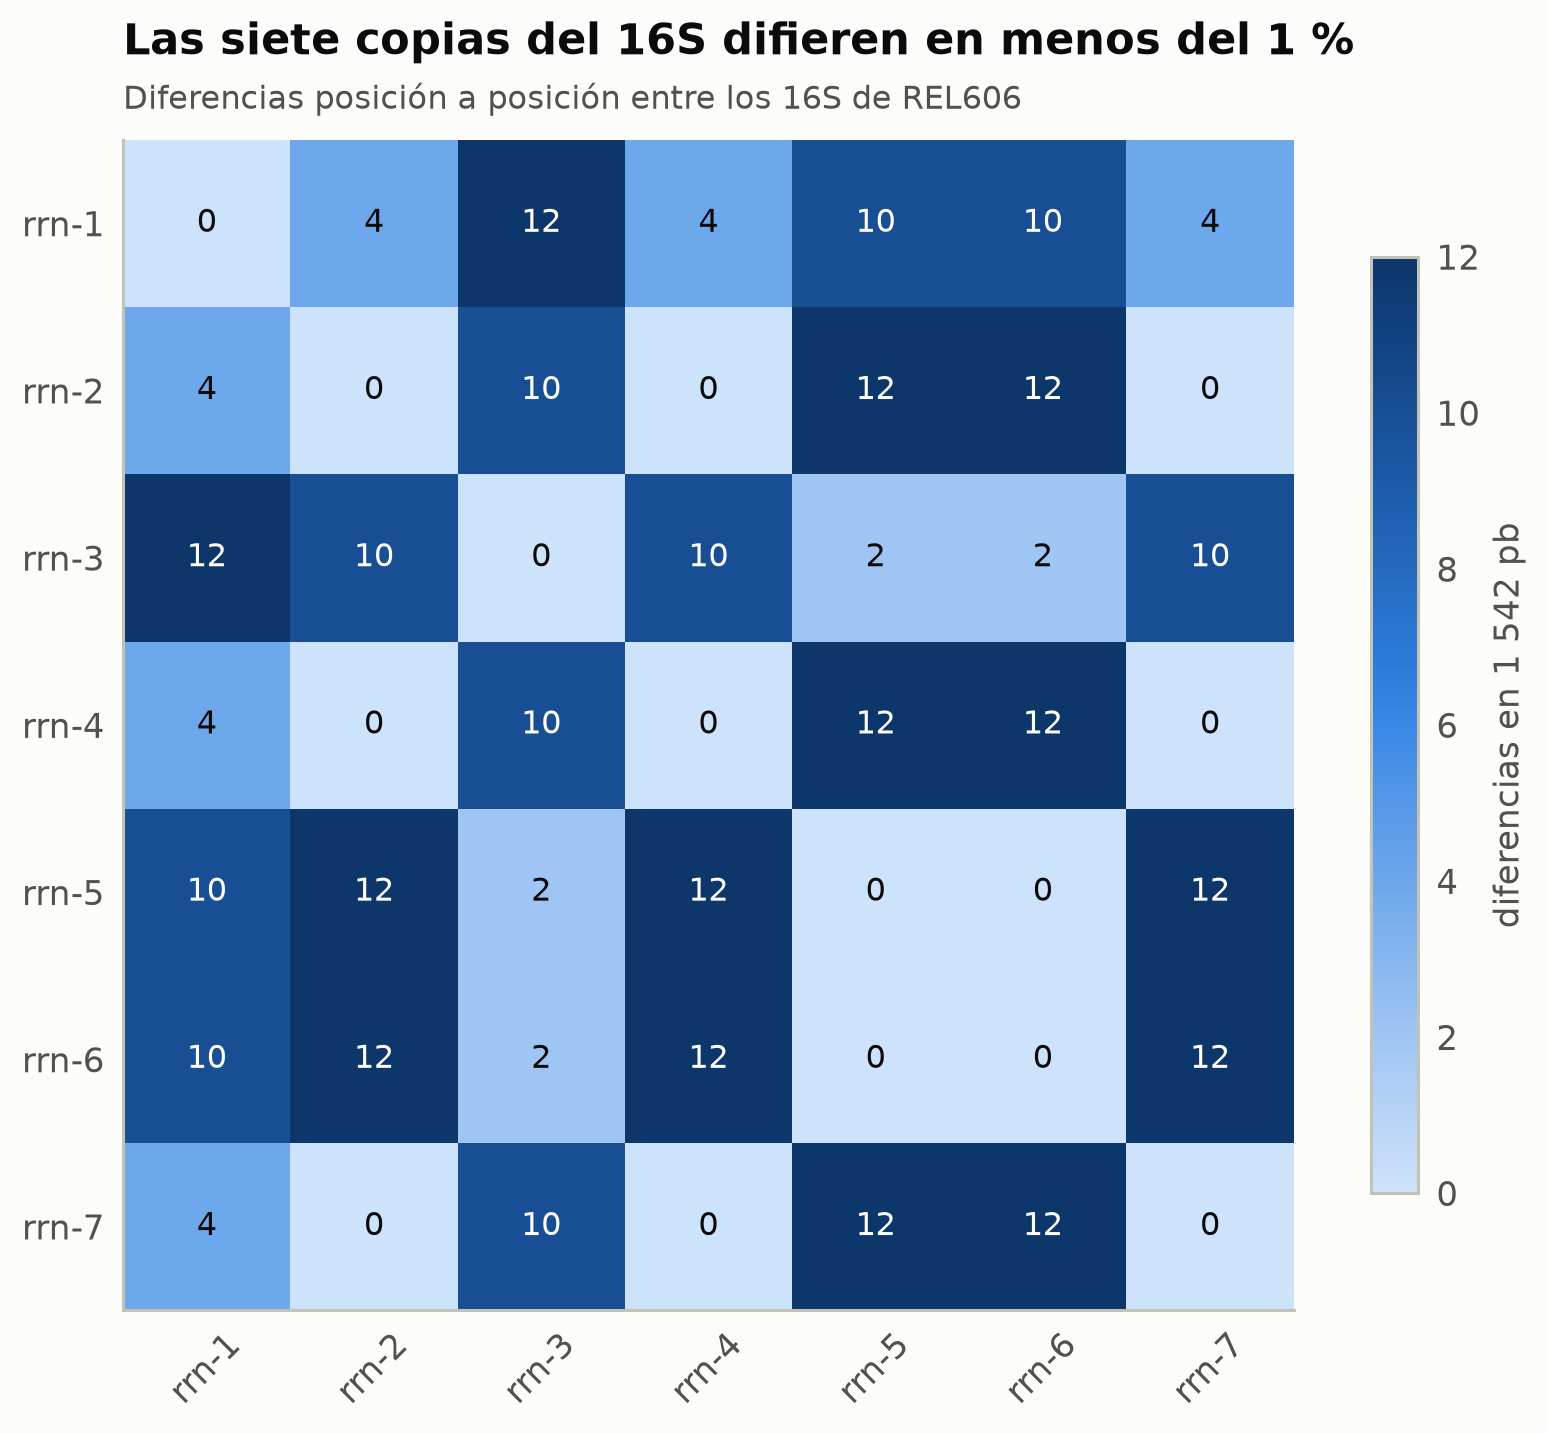

In [6]:
COMP = str.maketrans("ACGTN", "TGCAN")

def revcomp(s):
    """Complemento inverso de una secuencia de ADN."""
    return s.translate(COMP)[::-1]

s16 = rrna[rrna["product"].str.startswith("16S")].sort_values("start")
copies = []
for s, e, st in zip(s16.start, s16.end, s16.strand):
    seq = genome[s - 1:e]
    copies.append(seq if st == "+" else revcomp(seq))
lens = {len(c) for c in copies}
print("Longitudes de las copias de 16S:", lens)
n16 = len(copies)
diff16 = np.array([[sum(a != b for a, b in zip(copies[i], copies[j])) for j in range(n16)] for i in range(n16)])

fig, ax = plt.subplots(figsize=(8.2, 6.4))
im = ax.imshow(diff16, cmap=ec.CMAP_SEQ)
for i in range(n16):
    for j in range(n16):
        ax.text(j, i, diff16[i, j], ha="center", va="center", fontsize=10.5,
                color="white" if diff16[i, j] > diff16.max() * 0.55 else ec.INK)
ax.set_xticks(range(n16), operons.name, rotation=45); ax.set_yticks(range(n16), operons.name)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="diferencias en 1 542 pb")
ec.title(ax, "Las siete copias del 16S difieren en menos del 1 %",
         "Diferencias posición a posición entre los 16S de REL606")
plt.show()

> 🔎 **Qué observamos.** Entre dos copias cualesquiera hay, como mucho, 12 diferencias en 1 542 pb (0.8 %), y varias
> copias son **idénticas** base a base (rrn-2, rrn-4 y rrn-7 entre sí; rrn-5 y rrn-6 entre sí). Las copias forman dos
> "familias" que difieren en unas pocas posiciones. Una lectura de 150 pb tomada al azar del 16S tiene una buena
> probabilidad de no contener **ninguna** de esas diferencias: es idéntica en varias copias. Lo mismo pasa, de forma
> todavía más extrema, con las copias de IS1, que suelen ser idénticas base a base. Guarde esta figura en la memoria:
> en la sección 6 veremos las consecuencias sobre la calidad de mapeo.

### Las lecturas

Usamos los mismos 30 000 pares de la Lección 6.2 (Illumina HiSeq 2500, 2 × 150, biblioteca Nextera). Una aclaración
importante: en la 6.2 los limpiamos, pero los archivos limpios se generaban al ejecutar esa lección y no se guardaron.
Hoy mapeamos las lecturas **crudas** del curso a propósito: BWA-MEM y minimap2 hacen alineamiento **local** en los
extremos y **recortan suavemente** (*soft clipping*, operación `S` de la CIGAR, Lección 2.1) las colas de adaptador y
de baja calidad. Así veremos, en la sección 8, cómo los problemas que diagnosticamos en la 6.2 reaparecen en el BAM.

In [7]:
def read_fastq_gz(data):
    """Lee un FASTQ comprimido (bytes) y devuelve nombres, secuencias y calidades."""
    lines = gzip.decompress(data).decode().splitlines()
    names = [h[1:].split()[0] for h in lines[0::4]]
    return names, lines[1::4], lines[3::4]

RUN = "SRR2584863"
names1, seqs1, quals1 = read_fastq_gz(course_bytes(f"{RUN}_30k_1.fastq.gz"))
names2, seqs2, quals2 = read_fastq_gz(course_bytes(f"{RUN}_30k_2.fastq.gz"))
FQ1, FQ2 = course_file(f"{RUN}_30k_1.fastq.gz"), course_file(f"{RUN}_30k_2.fastq.gz")
L = len(seqs1[0])
print(f"{len(seqs1):,} pares · longitud {L} · bases totales {2 * len(seqs1) * L / 1e6:.1f} Mb")
print(f"Cobertura esperada: c = N·L/G = {2 * len(seqs1) * L / G:.2f}×  (Lección 6.3)")
print("Primer par:", names1[0], seqs1[0][:40] + "…", "|", seqs2[0][:40] + "…")

30,000 pares · longitud 150 · bases totales 9.0 Mb
Cobertura esperada: c = N·L/G = 1.94×  (Lección 6.3)
Primer par: SRR2584863.1 TTCACATCCTGACCATTCAGTTGAGCAAAATAGTTCTTCA… | GGCGACATTACTGACCCGCNNNNNNNNNNNNNNNNNNNCG…


### Formalicemos: mapear es un $\arg\max$ sobre las **dos** hebras

Antes de construir nada, escribamos con precisión qué le pedimos a un mapeador. Piense en un cartero que recibe un
trozo de sobre con media dirección escrita: debe decir a qué casa pertenece **y** cuán seguro está. Si el trozo dice
"calle 7, número 1…", puede haber varias casas compatibles, y un buen cartero lo avisa.

Hay una complicación propia del ADN: el fragmento que se secuenció pudo venir de **cualquiera de las dos hebras** de la
molécula. Si vino de la hebra −, la lectura que sale del secuenciador es el **reverso complementario** de lo que está
escrito en el FASTA de la referencia. Por eso hay que buscar la lectura tal cual **y** su reverso complementario.

**Ejemplo a mano.** Referencia de $G = 10$ bases, $R =$ `GACTTAGGCA`, y una lectura de $m = 4$ bases, $q =$ `CCTA`.
Su reverso complementario es $\bar q =$ `TAGG`. Con la puntuación de BWA-MEM (+1 coincidencia, −4 diferencia):

| Candidato | Mejor tramo de $R$ | Alineamiento | Puntuación |
|---|---|---|---|
| $q =$ `CCTA` (hebra +) | $R_{3..4} =$ `CT` (o $R_{5..6} =$ `TA`) | sólo 2 bases coinciden seguidas | $S = 2$ |
| $\bar q =$ `TAGG` (hebra −) | $R_{5..8} =$ `TAGG` | 4 coincidencias | $S = 4$ |

El máximo está en la hebra −: la lectura procede de $(\hat u, \hat v) = (5, 8)$, leída "al revés". Formalmente:

$$
(\hat u,\hat v) \;=\; \arg\max_{1\le u\le v\le G}\; \max\big\{S(q, R_{u..v}),\; S(\bar q, R_{u..v})\big\}
$$

| Símbolo | Significado |
|---|---|
| $R = r_1 r_2\cdots r_G$,  $G$ | secuencia de referencia (cromosomas concatenados) y su longitud en bases; aquí REL606, $G = 4\,629\,812$ |
| $q = q_1\cdots q_m$,  $m$ | la lectura y su longitud ($m = 150$; en el código de esta lección la variable se llama `L`) |
| $\bar q$ | reverso complementario de la lectura: el fragmento pudo secuenciarse desde cualquiera de las dos hebras |
| $R_{u..v}$ | subcadena de la referencia entre las posiciones $u$ y $v$ (base 1, ambas incluidas) |
| $S(\cdot,\cdot)$ | puntuación del mejor alineamiento local (Smith–Waterman, Lección 3.2) |
| $(\hat u,\hat v)$ | intervalo elegido: el origen más probable de la lectura |

La definición tiene una **segunda mitad**, tan importante como la primera y que a menudo se olvida: además de
$(\hat u, \hat v)$, el mapeador debe **cuantificar la probabilidad** de que ese sea el origen verdadero. Esa es la
calidad de mapeo de la sección 6.

¿Por qué no resolver la ecuación por fuerza bruta? En un genoma humano a $30\times$ hay unos $6.2\times10^{8}$ lecturas
de 150 pb contra $3.1\times10^{9}$ bases: cada lectura exige $m\times G = 150 \times 3.1\times10^{9} \approx
4.7\times10^{11}$ celdas, y todas juntas $\approx 2.9\times10^{20}$. A mil millones de celdas por segundo serían **unos
nueve mil años**. Hay que **filtrar**: descartar en un instante casi todo el genoma y reservar la programación dinámica
para unas pocas regiones candidatas.

> 🤔 **Antes de ejecutar, prediga.** Tomamos una lectura **real** del clon y la comparamos, base a base, con 2 kb de
> REL606 alrededor de su origen. ¿Veremos un pico de puntuación en las dos curvas (hebra + y hebra −) o sólo en una?

In [8]:
def sw_local(q, r, match=1, mismatch=4, gap=6):
    """Smith–Waterman local (Python puro). Devuelve (S, u, v) en base 1 sobre r y, para cada columna j,
    la mejor puntuación de un alineamiento que termina en r_j (máximo de la columna de la matriz H)."""
    n = len(r)
    prev, prev_st = [0] * (n + 1), [0] * (n + 1)
    colmax = [0] * n
    best = (0, 0, 0)
    for qi in q:
        cur, cur_st = [0] * (n + 1), [0] * (n + 1)
        for j in range(1, n + 1):
            dg = prev[j - 1] + (match if qi == r[j - 1] else -mismatch)
            up, lf = prev[j] - gap, cur[j - 1] - gap
            v = max(0, dg, up, lf)
            if v > 0:
                cur_st[j] = (prev_st[j - 1] if prev[j - 1] > 0 else j) if v == dg else (prev_st[j] if v == up else cur_st[j - 1])
            cur[j] = v
            if v > colmax[j - 1]:
                colmax[j - 1] = v
            if v > best[0]:
                best = (v, cur_st[j], j)
        prev, prev_st = cur, cur_st
    return best, np.array(colmax)

# 1) el ejemplo a mano
R_toy, q_toy = "GACTTAGGCA", "CCTA"
(Sp, up_, vp_), _ = sw_local(q_toy, R_toy)
(Sm, um_, vm_), _ = sw_local(revcomp(q_toy), R_toy)
print(f"Ejemplo a mano: S(q, R) = {Sp} en R[{up_}..{vp_}] · S(q̄, R) = {Sm} en R[{um_}..{vm_}] → "
      f"(û, v̂) = ({um_}, {vm_}) en la hebra −" if Sm > Sp else "hebra +")

# 2) una lectura real de R1: buscamos su origen con un k-mero exacto (sólo para elegir la ventana de 2 kb)
for i_real, s_ in enumerate(seqs1[:200]):
    hit = genome.find(revcomp(s_)[:30])
    if hit > 2000 and "N" not in s_:
        break
w0_ = hit - 1000
window = genome[w0_:w0_ + 2000]
t0 = time.perf_counter()
(Sq, uq, vq), col_q = sw_local(seqs1[i_real], window)
(Sb, ub, vb), col_b = sw_local(revcomp(seqs1[i_real]), window)
t_argmax = time.perf_counter() - t0
strand_hat = "−" if Sb > Sq else "+"
u_hat, v_hat = (ub, vb) if Sb > Sq else (uq, vq)
print(f"Lectura real {names1[i_real]} (m = {len(seqs1[i_real])}): máx S(q, ·) = {Sq} · máx S(q̄, ·) = {Sb}")
print(f"(û, v̂) = ({w0_ + u_hat:,}, {w0_ + v_hat:,}) en REL606, hebra {strand_hat} · "
      f"{2 * len(seqs1[i_real]) * len(window):,} celdas en {t_argmax:.2f} s")
t_one = t_argmax * G / len(window)
print(f"Al mismo ritmo, todo el genoma: {t_one / 60:,.0f} min para esta sola lectura; "
      f"{t_one * 2 * len(seqs1) / 86400 / 30:,.0f} meses para las {2 * len(seqs1):,} lecturas")

Ejemplo a mano: S(q, R) = 2 en R[3..4] · S(q̄, R) = 4 en R[5..8] → (û, v̂) = (5, 8) en la hebra −


Lectura real SRR2584863.1 (m = 150): máx S(q, ·) = 11 · máx S(q̄, ·) = 150
(û, v̂) = (3,339,155, 3,339,304) en REL606, hebra − · 600,000 celdas en 0.11 s
Al mismo ritmo, todo el genoma: 4 min para esta sola lectura; 6 meses para las 60,000 lecturas


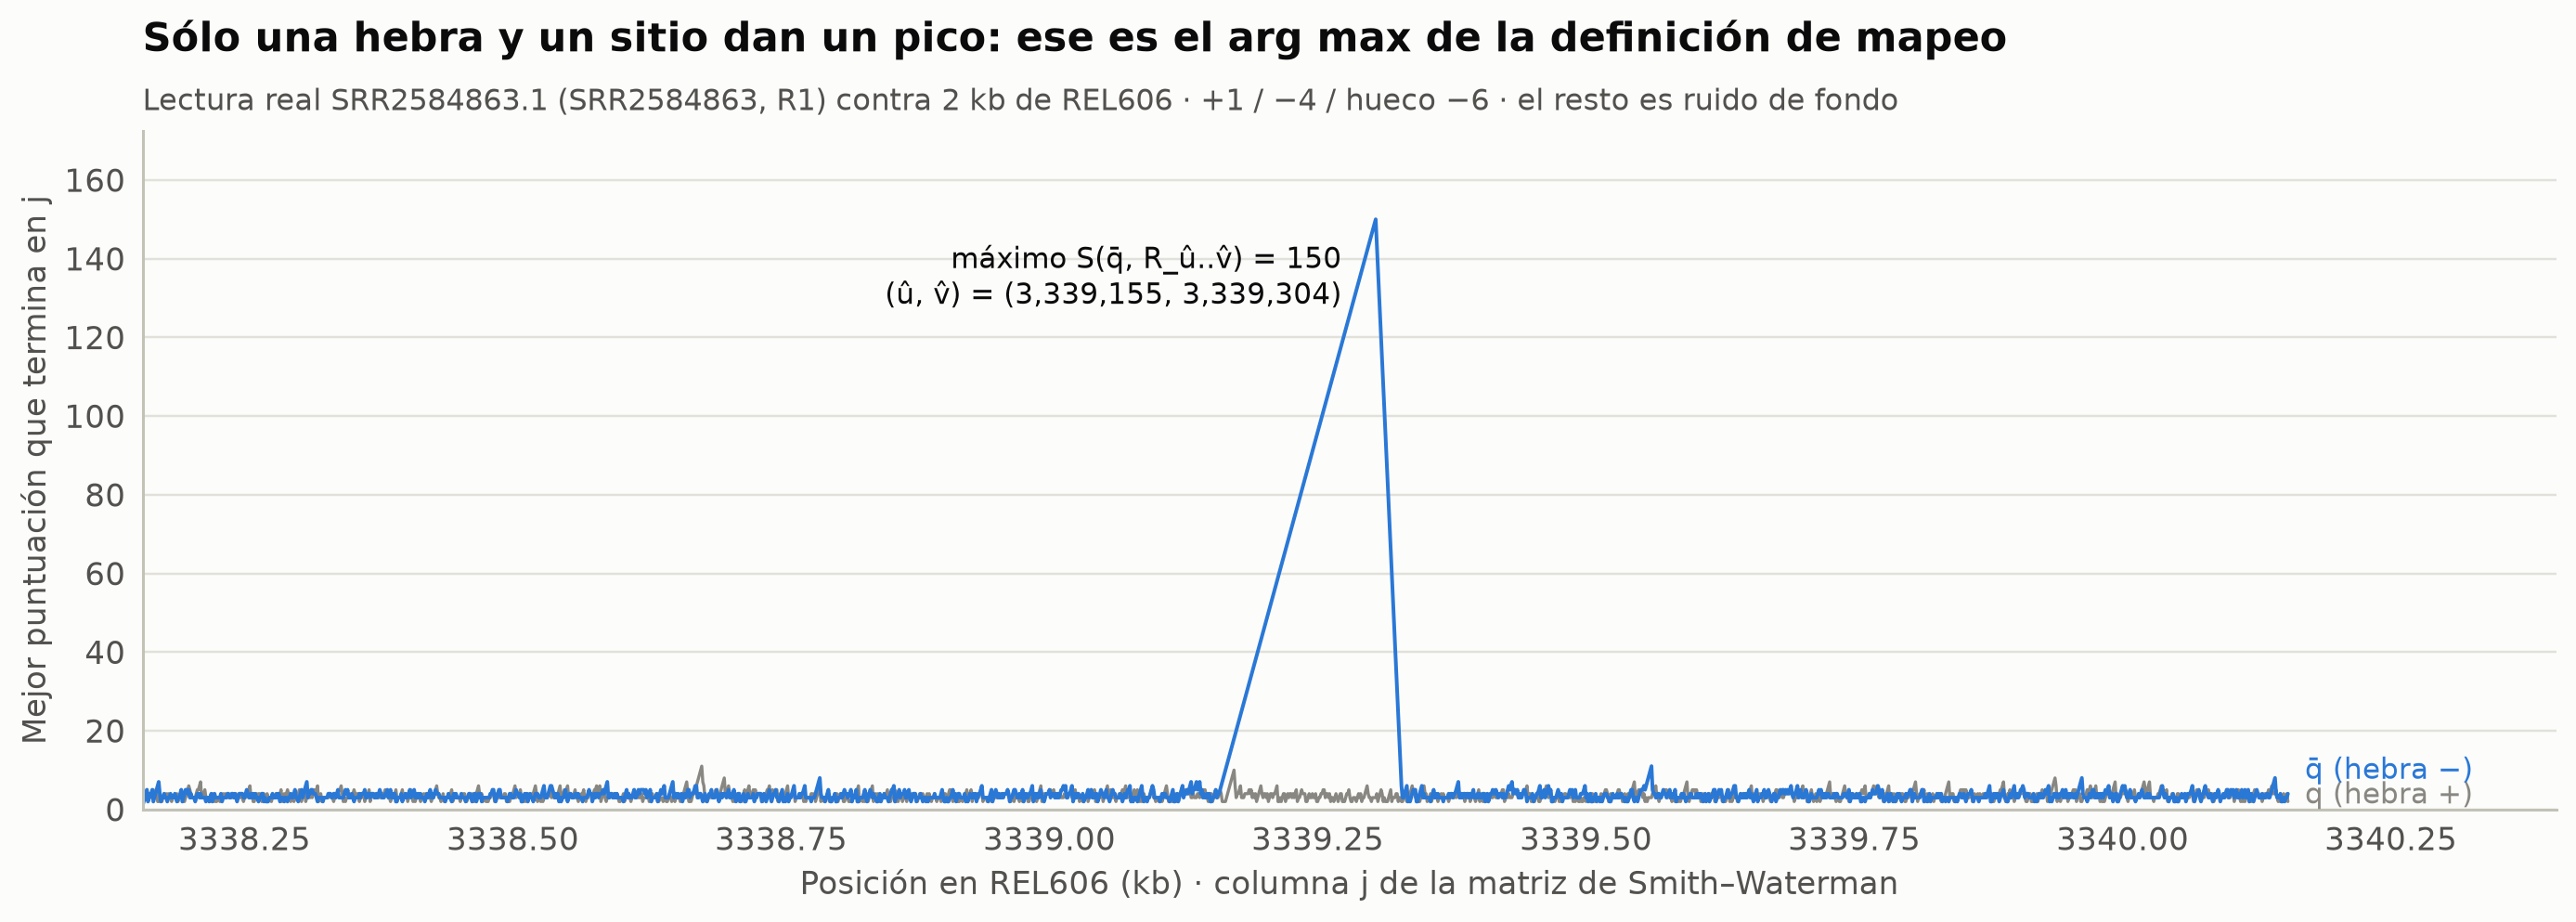

In [9]:
fig, ax = plt.subplots(figsize=(12.5, 4.4))
xg = (w0_ + np.arange(1, len(window) + 1)) / 1e3
ax.plot(xg, col_q, color=ec.MUTED, lw=1.1)
ax.plot(xg, col_b, color=ec.BLUE, lw=1.3)
ec.label_end(ax, xg[-1], col_q[-60:].mean(), "q (hebra +)", ec.MUTED)
ec.label_end(ax, xg[-1], col_b[-60:].mean() + 6, "q̄ (hebra −)", ec.BLUE)
peak = w0_ + v_hat
ax.annotate(f"máximo S(q̄, R_û..v̂) = {max(Sq, Sb)}\n(û, v̂) = ({w0_ + u_hat:,}, {peak:,})",
            xy=(peak / 1e3, max(Sq, Sb)), xytext=(-12, -8), textcoords="offset points", ha="right", va="top",
            fontsize=10, color=ec.INK, arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ax.set_xlim(xg[0], xg[-1] + 0.25)
ax.set_ylim(0, max(Sq, Sb) * 1.15)
ax.set_xlabel("Posición en REL606 (kb) · columna j de la matriz de Smith–Waterman")
ax.set_ylabel("Mejor puntuación que termina en j")
ec.title(ax, "Sólo una hebra y un sitio dan un pico: ese es el arg max de la definición de mapeo",
         f"Lectura real {names1[i_real]} (SRR2584863, R1) contra 2 kb de REL606 · +1 / −4 / hueco −6 · el resto es ruido de fondo")
plt.show()

> 🔎 **Qué observamos.** La curva de la lectura tal cual (gris) nunca supera el ruido de fondo: puntuaciones de 5–10
> puntos que cualquier par de secuencias aleatorias comparte por azar. La del reverso complementario (azul) sube como
> una rampa durante 150 columnas y cae de golpe: es el alineamiento completo, que termina en $\hat v$. La lectura venía
> de la hebra −, y sin probar $\bar q$ la habríamos perdido. Pero observe el costo: 600 000 celdas para mirar sólo
> **2 kb** del genoma tardan una fracción de segundo en Python; el genoma entero llevaría unos minutos **por lectura**,
> y las 60 000 lecturas, meses. Las secciones 3–5 explican cómo evitar ese cálculo en el 99.999 % del genoma.

## 3. La estrategia semilla → encadenamiento → extensión

Todos los mapeadores modernos siguen tres pasos. Piense en cómo reconoce usted una canción en la radio a partir de
unos pocos segundos: primero una frase característica le trae a la mente dos o tres canciones posibles (**semillas**);
luego comprueba que las frases siguientes llegan en el orden correcto (**encadenamiento**); y sólo al final escucha
con atención para confirmar que es esa versión y no otra (**extensión**).

1. **Semillas (*seeding*).** Se extraen de la lectura trozos cortos que coinciden **exactamente** con el genoma y se
   buscan en el índice. Cada coincidencia es un **ancla** $(x, y)$: la posición $x$ en el genoma y la posición $y$ en
   la lectura. Si la lectura viene del genoma sin errores, todas sus anclas verdaderas caen sobre la misma
   **diagonal** $x - y = \text{constante}$.
2. **Encadenamiento (*chaining*).** Muchas anclas son ruido: la palabra aparece por azar en otro sitio, o en otra
   copia de una repetición. Se buscan conjuntos de anclas **colineales** (crecen juntas en $x$ y en $y$, cerca de la
   misma diagonal) y se puntúa cada cadena. Las mejores cadenas son las **posiciones candidatas**.
3. **Extensión (*extension*).** En cada candidata se alinea la lectura completa con programación dinámica, pero sólo
   dentro de una **banda** de ancho $\pm b$ alrededor de la diagonal de la cadena. El resultado es la puntuación, la
   posición exacta y la CIGAR que vimos en la Lección 2.1.

La figura resume el proceso con un ejemplo esquemático.

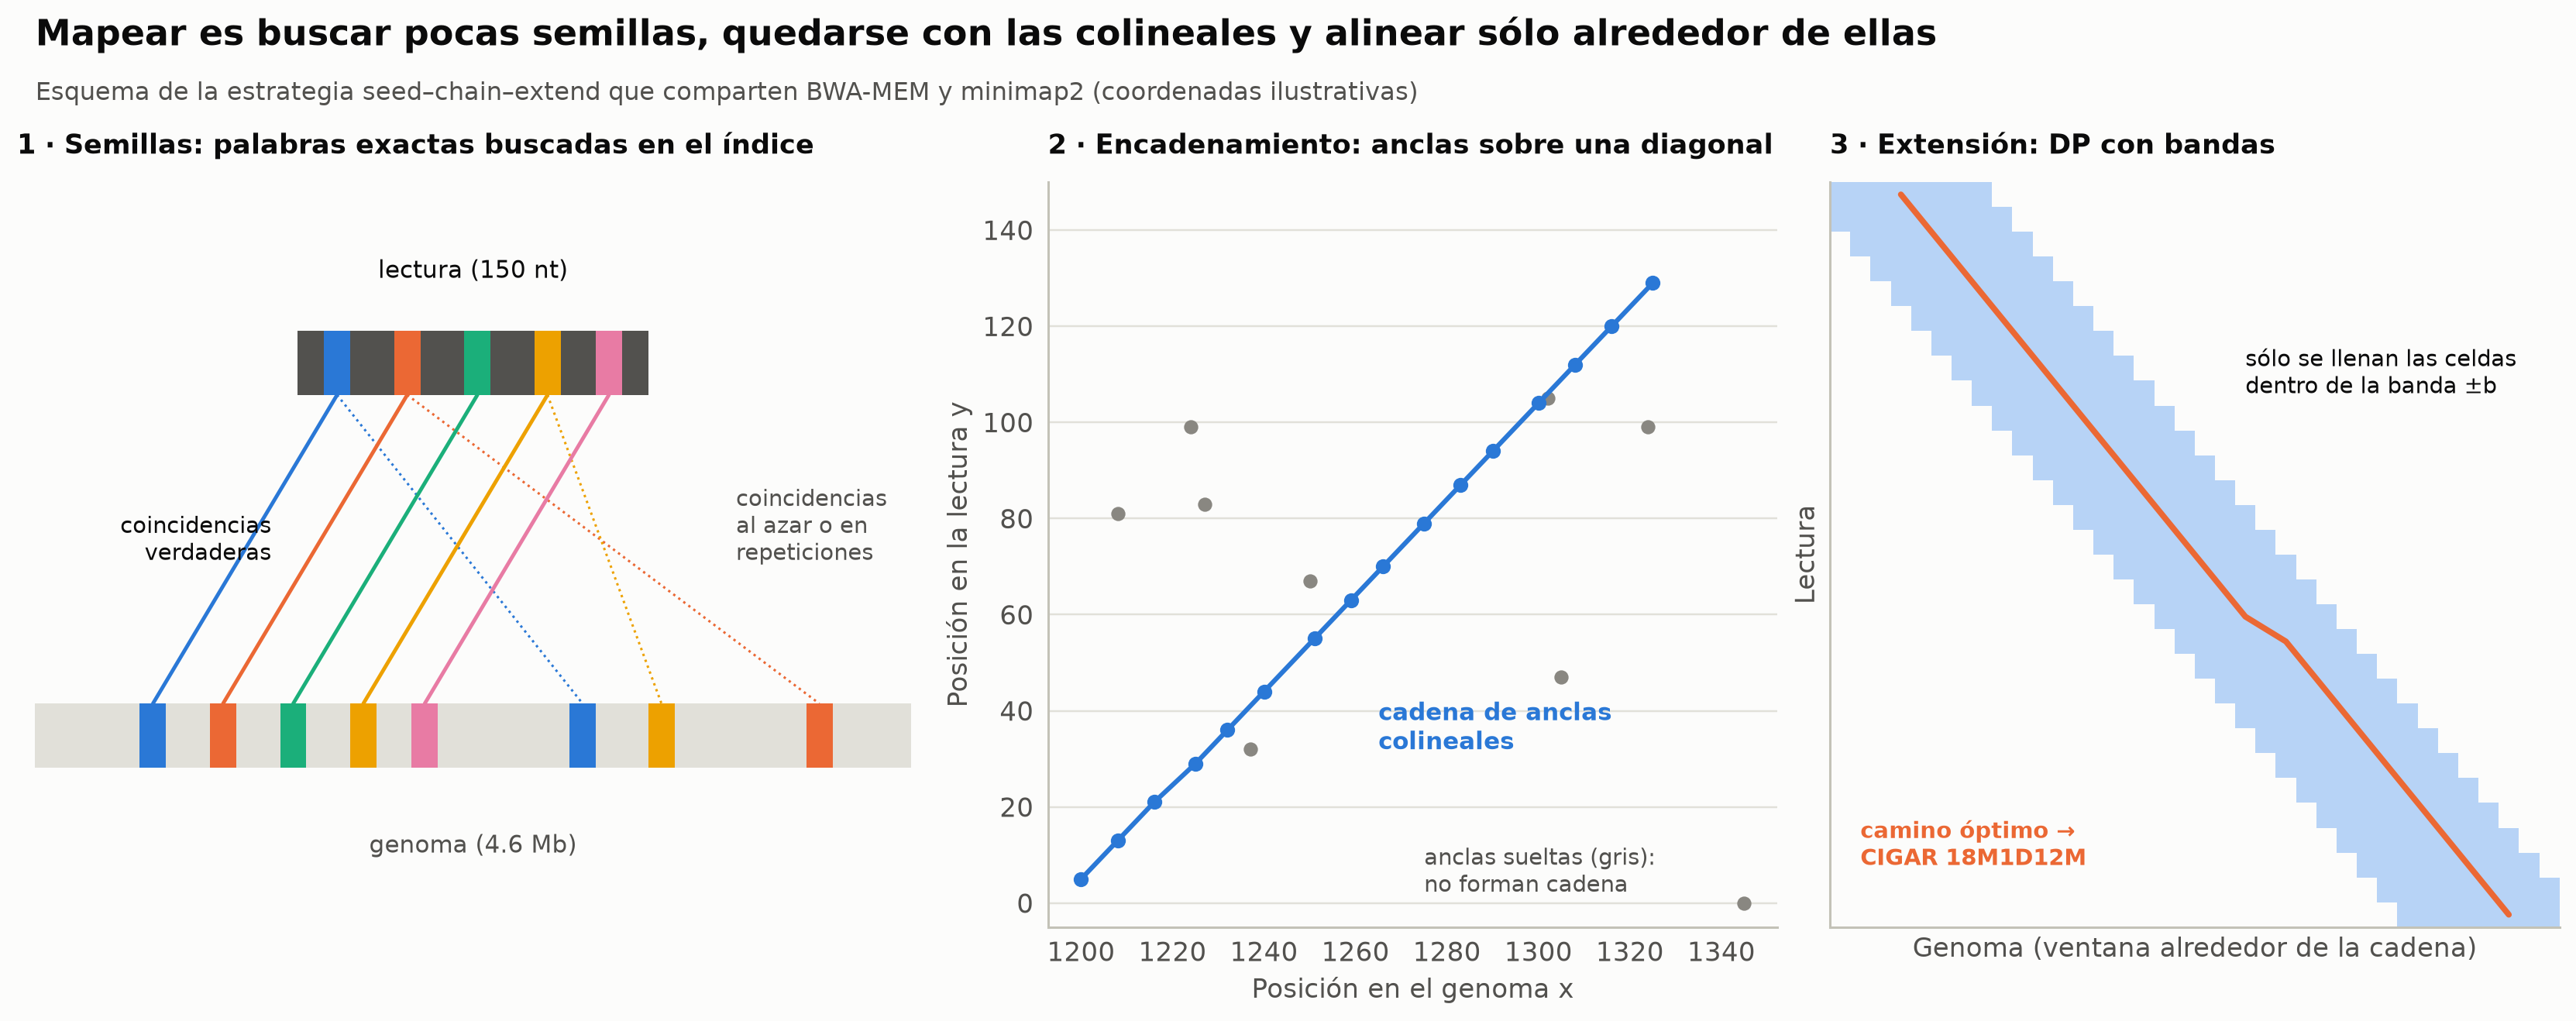

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), gridspec_kw=dict(width_ratios=[1.25, 1, 1]))
# Panel A: semillas de la lectura y sus apariciones en el genoma
ax = axes[0]
ax.add_patch(Rectangle((30, 8), 40, 1.2, color=ec.INK_2))
ax.text(50, 10.2, "lectura (150 nt)", ha="center", fontsize=10)
ax.add_patch(Rectangle((0, 1), 100, 1.2, color=ec.GRID))
ax.text(50, -0.6, "genoma (4.6 Mb)", ha="center", fontsize=10, color=ec.INK_2)
seed_x = [33, 41, 49, 57, 64]
hits = {33: [12, 61], 41: [20, 88], 49: [28], 57: [36, 70], 64: [43]}
for k, sx in enumerate(seed_x):
    col = ec.CATEGORICAL[k]
    ax.add_patch(Rectangle((sx, 8), 3, 1.2, color=col))
    for hx in hits[sx]:
        true_hit = hx == [12, 20, 28, 36, 43][k]
        ax.add_patch(Rectangle((hx, 1), 3, 1.2, color=col))
        ax.plot([sx + 1.5, hx + 1.5], [8, 2.2], color=col, lw=1.6 if true_hit else 1, ls="-" if true_hit else ":")
ax.text(27, 4.9, "coincidencias\nverdaderas", fontsize=9.5, color=ec.INK, ha="right")
ax.text(80, 4.9, "coincidencias\nal azar o en\nrepeticiones", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(-2, 102); ax.set_ylim(-2, 12); ax.axis("off")
ax.set_title("1 · Semillas: palabras exactas buscadas en el índice", fontsize=11.5, loc="left")
# Panel B: anclas en el plano (genoma, lectura) y la cadena
ax = axes[1]
true_a = np.array([[1200, 5], [1208, 13], [1216, 21], [1225, 29], [1232, 36], [1240, 44], [1251, 55], [1259, 63],
                   [1266, 70], [1275, 79], [1283, 87], [1290, 94], [1300, 104], [1308, 112], [1316, 120], [1325, 129]])
noise = np.column_stack([rng.integers(1180, 1360, 9), rng.integers(0, 140, 9)])
ax.scatter(noise[:, 0], noise[:, 1], s=36, color=ec.MUTED, zorder=3, label="anclas sueltas")
ax.scatter(true_a[:, 0], true_a[:, 1], s=40, color=ec.BLUE, zorder=4)
ax.plot(true_a[:, 0], true_a[:, 1], color=ec.BLUE, lw=2, zorder=3)
ax.text(1265, 32, "cadena de anclas\ncolineales", color=ec.BLUE, fontsize=10, fontweight="bold")
ax.text(1275, 12, "anclas sueltas (gris):\nno forman cadena", color=ec.INK_2, fontsize=9.5, va="top")
ax.set_xlabel("Posición en el genoma x"); ax.set_ylabel("Posición en la lectura y")
ax.set_ylim(-5, 150)
ax.set_title("2 · Encadenamiento: anclas sobre una diagonal", fontsize=11.5, loc="left")
# Panel C: la banda de la programación dinámica
ax = axes[2]
m, n, b = 30, 36, 4
M = np.full((m, n), np.nan)
for i in range(m):
    for j in range(n):
        if abs((j - 3) - i) <= b:
            M[i, j] = 1
ax.imshow(np.where(np.isnan(M), 0, 1), cmap=plt.matplotlib.colors.ListedColormap([ec.SURFACE, ec.SEQ_BLUE[1]]),
          aspect="auto", origin="upper")
path_i = np.arange(m); path_j = np.clip(path_i + 3 + (path_i > 17).astype(int), 0, n - 1)
ax.plot(path_j, path_i, color=ec.ORANGE, lw=2.5)
ax.text(20, 8, "sólo se llenan las celdas\ndentro de la banda ±b", fontsize=9.5, color=ec.INK)
ax.text(1, 27, "camino óptimo →\nCIGAR 18M1D12M", fontsize=9.5, color=ec.ORANGE, fontweight="bold")
ax.set_xlabel("Genoma (ventana alrededor de la cadena)"); ax.set_ylabel("Lectura")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("3 · Extensión: DP con bandas", fontsize=11.5, loc="left")
ec.fig_title(fig, "Mapear es buscar pocas semillas, quedarse con las colineales y alinear sólo alrededor de ellas",
             "Esquema de la estrategia seed–chain–extend que comparten BWA-MEM y minimap2 (coordenadas ilustrativas)")
plt.show()

> 🔎 **Qué observamos.** En el panel 1, la semilla naranja y la morada aparecen también en otros lugares del genoma:
> las semillas cortas se repiten. En el panel 2 se ve por qué eso no es grave: las anclas verdaderas forman una línea
> casi recta (una diagonal), mientras que las falsas quedan sueltas. En el panel 3, la DP sólo llena una franja
> estrecha: para una lectura de 150 nt con banda $\pm 10$, unas 3 000 celdas en lugar de 700 millones.

### Dos formas de encontrar semillas: SMEM (BWA-MEM) y minimizers (minimap2)

**BWA-MEM** usa como semillas las **coincidencias exactas supermaximales** (SMEM, *super-maximal exact matches*). Un
**MEM** (coincidencia exacta maximal) es un tramo de la lectura que aparece exactamente en el genoma y que **no se puede
alargar** ni a la izquierda ni a la derecha sin dejar de aparecer. Un **SMEM** es, para cada posición de la lectura, la
coincidencia exacta más larga que la cubre y que **no está contenida** en otra coincidencia de la misma lectura. Si la lectura tiene un error en la posición 80, los SMEM típicos serán "posiciones 1–79" y "posiciones
81–150": los tramos exactos más largos a cada lado del error. Para encontrarlos rápido, BWA indexa el genoma con el
**índice FM** que construimos en la Lección 7.1, basado en la **transformada de Burrows–Wheeler** (de ahí el nombre *BWA*,
*Burrows–Wheeler Aligner*; Li y Durbin, 2009) que permite preguntar "¿cuántas veces y dónde aparece esta cadena?" en un
tiempo proporcional a la longitud de la cadena, **sin importar** el tamaño del genoma: alargar una coincidencia un
carácter cuesta una sola actualización del intervalo. Por defecto, BWA-MEM sólo usa semillas de al menos 19 nt (opción
`-k 19`). Y si una SMEM es muy larga (más de 28 bases por defecto, opción `-r`), BWA-MEM **vuelve a sembrar** con
coincidencias más cortas que aparecen más veces, para no perder el origen verdadero cuando la SMEM cae en una
repetición.

Veamos los SMEM con un ejemplo diminuto, buscando por fuerza bruta en un "genoma" de juguete.

In [11]:
def smems(read, text, min_len=4):
    """SMEM por fuerza bruta: para cada inicio, la coincidencia exacta más larga; luego se quitan las contenidas."""
    mems = []
    for i in range(len(read)):
        j = i
        while j < len(read) and read[i:j + 1] in text:
            j += 1
        if j - i >= min_len and (i == 0 or read[i - 1:j] not in text):   # maximal hacia la izquierda
            mems.append((i, j))
    return [(i, j) for i, j in mems if not any(a <= i and j <= b and (a, b) != (i, j) for a, b in mems)]

toy_genome = "TTGACCATGCAGGTACCGATTACAGGCATCCGTAAGGTACCTTGA"
toy_read = "ATGCAGGTACCGATAACAGGCAT"            # copia del genoma con un error (T→A en la posición 15)
for i, j in smems(toy_read, toy_genome):
    where = [m.start() + 1 for m in re.finditer(f"(?={toy_read[i:j]})", toy_genome)]
    print(f"SMEM lectura {i + 1:>2}–{j:<2} {toy_read[i:j]:<16} aparece en el genoma en {where}")

SMEM lectura  1–14 ATGCAGGTACCGAT   aparece en el genoma en [7]
SMEM lectura 16–23 ACAGGCAT         aparece en el genoma en [22]


> 🔎 **Qué observamos.** El error parte la lectura en dos SMEM, uno a cada lado: las posiciones 1–14 (14 nt) y
> 16–23 (8 nt); la base 15, la del error, no pertenece a ninguno. Los dos apuntan a la misma diagonal (posición 7 del
> genoma para la base 1 de la lectura, y $22 - 16 + 1 = 7$ para el segundo), que es justo lo que el encadenamiento
> buscará. Un SMEM corto como el segundo es más propenso a aparecer también por azar en otros sitios. Con semillas de ≥ 19 nt en un genoma de 4.6 Mb, la probabilidad de que una
> semilla aparezca por azar en otro sitio es minúscula ($4.6\times10^6 / 4^{19} \approx 2\times10^{-5}$), salvo que
> caiga en una repetición.

**minimap2** usa otra idea: en lugar de todas las coincidencias exactas maximales, guarda en una **tabla hash** sólo una
muestra de los $k$-meros del genoma, los **minimizers**. Buscar un $k$-mero en una tabla hash es tan rápido como buscar
una palabra en un diccionario, y como sólo se guarda una fracción de los $k$-meros, el índice es pequeño. Además, la
muestra se elige de forma que dos secuencias que comparten un tramo suficientemente largo **siempre** comparten algún
minimizer. La siguiente sección explica cómo.

| | **BWA-MEM** | **minimap2** |
|---|---|---|
| Índice | índice FM (BWT + arreglo de sufijos muestreado) | tabla hash de minimizers |
| Semillas | SMEM de longitud ≥ 19 (`-k 19`) | minimizers: $k = 21$, $w = 11$ con `-x sr`; $k = 15$, $w = 10$ con `-x map-ont` |
| Encadenamiento | agrupa semillas colineales | programación dinámica sobre las anclas con coste de hueco |
| Extensión | Smith–Waterman con bandas (`-w 100`), huecos afines: coincidencia +1, diferencia −4, abrir −6, extender −1, penalización por recorte −5 | DP con bandas (biblioteca ksw2), huecos afines de dos tramos |
| Pensado para | lecturas cortas (70 nt – algunos kb) | lecturas largas con errores, y también cortas |
| Referencia | Li (2013) | Li (2018) |

### ¿Cuándo dejar de extender? El criterio *X-drop*

La extensión parte de una semilla y avanza base a base hacia los extremos de la lectura. Mientras las bases coinciden,
la puntuación sube; un error aislado (un SNP del clon o un error de secuenciación) la baja un poco, y luego vuelve a
subir. Pero si la lectura se sale del genoma, por ejemplo porque un inserto corto hizo que el secuenciador leyera el
**adaptador Nextera** (Lección 6.2), la puntuación ya no se recupera: cae y cae. ¿Cómo distinguir un bache pasajero de
un final? La regla de BLAST (Lección 3.4) es sencilla: **recuerde el mejor valor alcanzado y abandone en cuanto la
puntuación actual caiga más de $X$ puntos por debajo de él**. Lo que quede más allá del máximo se recorta (`S`).

**Ejemplo a mano ($X = 10$, +1 / −4).** Tras la semilla, 20 coincidencias ($S = 20$); una diferencia ($S = 16$: caída
de 4, se sigue); 10 coincidencias ($S = 26$, nuevo máximo). Empieza el adaptador: diferencia ($22$), diferencia ($18$),
coincidencia ($19$), diferencia ($15$). Ahora $26 - 15 = 11 > X$: se abandona. El alineamiento informado termina en el
máximo (base 31) y las 4 bases siguientes quedan recortadas.

$$
S_j \;=\; \sum_{t=1}^{j} s(q_t, r_t),\qquad S^{*}_j \;=\; \max_{t \le j} S_t,\qquad
\text{parar en el primer } j \text{ tal que } S^{*}_j - S_j > X
$$

| Símbolo | Significado |
|---|---|
| $s(q_t, r_t)$ | puntuación de la base $t$ de la extensión (+1 coincide, −4 no coincide) |
| $S_j$ | puntuación acumulada tras extender $j$ bases |
| $S^{*}_j$ | mejor puntuación alcanzada hasta $j$: el alineamiento se informa hasta allí |
| $X$ | caída tolerada; BWA-MEM usa una variante (*Z-drop*, opción `-d`, 100 por defecto) que además vigila el cambio de diagonal |

Veámoslo con una lectura construida como las de un inserto corto: 110 nt de REL606 (con un SNP en la base 40) seguidos
de la secuencia del adaptador Nextera `CTGTCTCTTATACACATCT…`.

In [12]:
NEXTERA = "CTGTCTCTTATACACATCTCCGAGCCCACGAGAC"          # adaptador de lectura Nextera (R1)
p_x = 1_000_000
insert_ = list(genome[p_x:p_x + 110])
insert_[39] = "A" if insert_[39] != "A" else "C"           # un SNP en la base 40 del inserto
xread = "".join(insert_) + NEXTERA
xref = genome[p_x:p_x + len(xread)]                       # la referencia continúa con el genoma, no con el adaptador

def xdrop_extend(q, r, X, match=1, mismatch=4):
    """Extensión sin huecos con criterio X-drop: devuelve S_j, S*_j, la base donde para y dónde está el máximo."""
    S, Sstar, stop = [], [], len(q)
    cur = best = 0
    for j, (a, b) in enumerate(zip(q, r), start=1):
        cur += match if a == b else -mismatch
        best = max(best, cur)
        S.append(cur); Sstar.append(best)
        if best - cur > X:
            stop = j
            break
    Sstar = np.array(Sstar)
    return np.array(S), Sstar, stop, int(np.argmax(Sstar == Sstar[-1])) + 1

for X_ in (10, 100):
    S_, Ss_, stop_, end_ = xdrop_extend(xread, xref, X_)
    print(f"X = {X_:>3}: se abandona en la base {stop_} de {len(xread)} · alineamiento informado 1–{end_} "
          f"(S* = {Ss_.max()}) · recorte suave: {len(xread) - end_} nt")

X =  10: se abandona en la base 113 de 144 · alineamiento informado 1–110 (S* = 105) · recorte suave: 34 nt
X = 100: se abandona en la base 144 de 144 · alineamiento informado 1–110 (S* = 105) · recorte suave: 34 nt


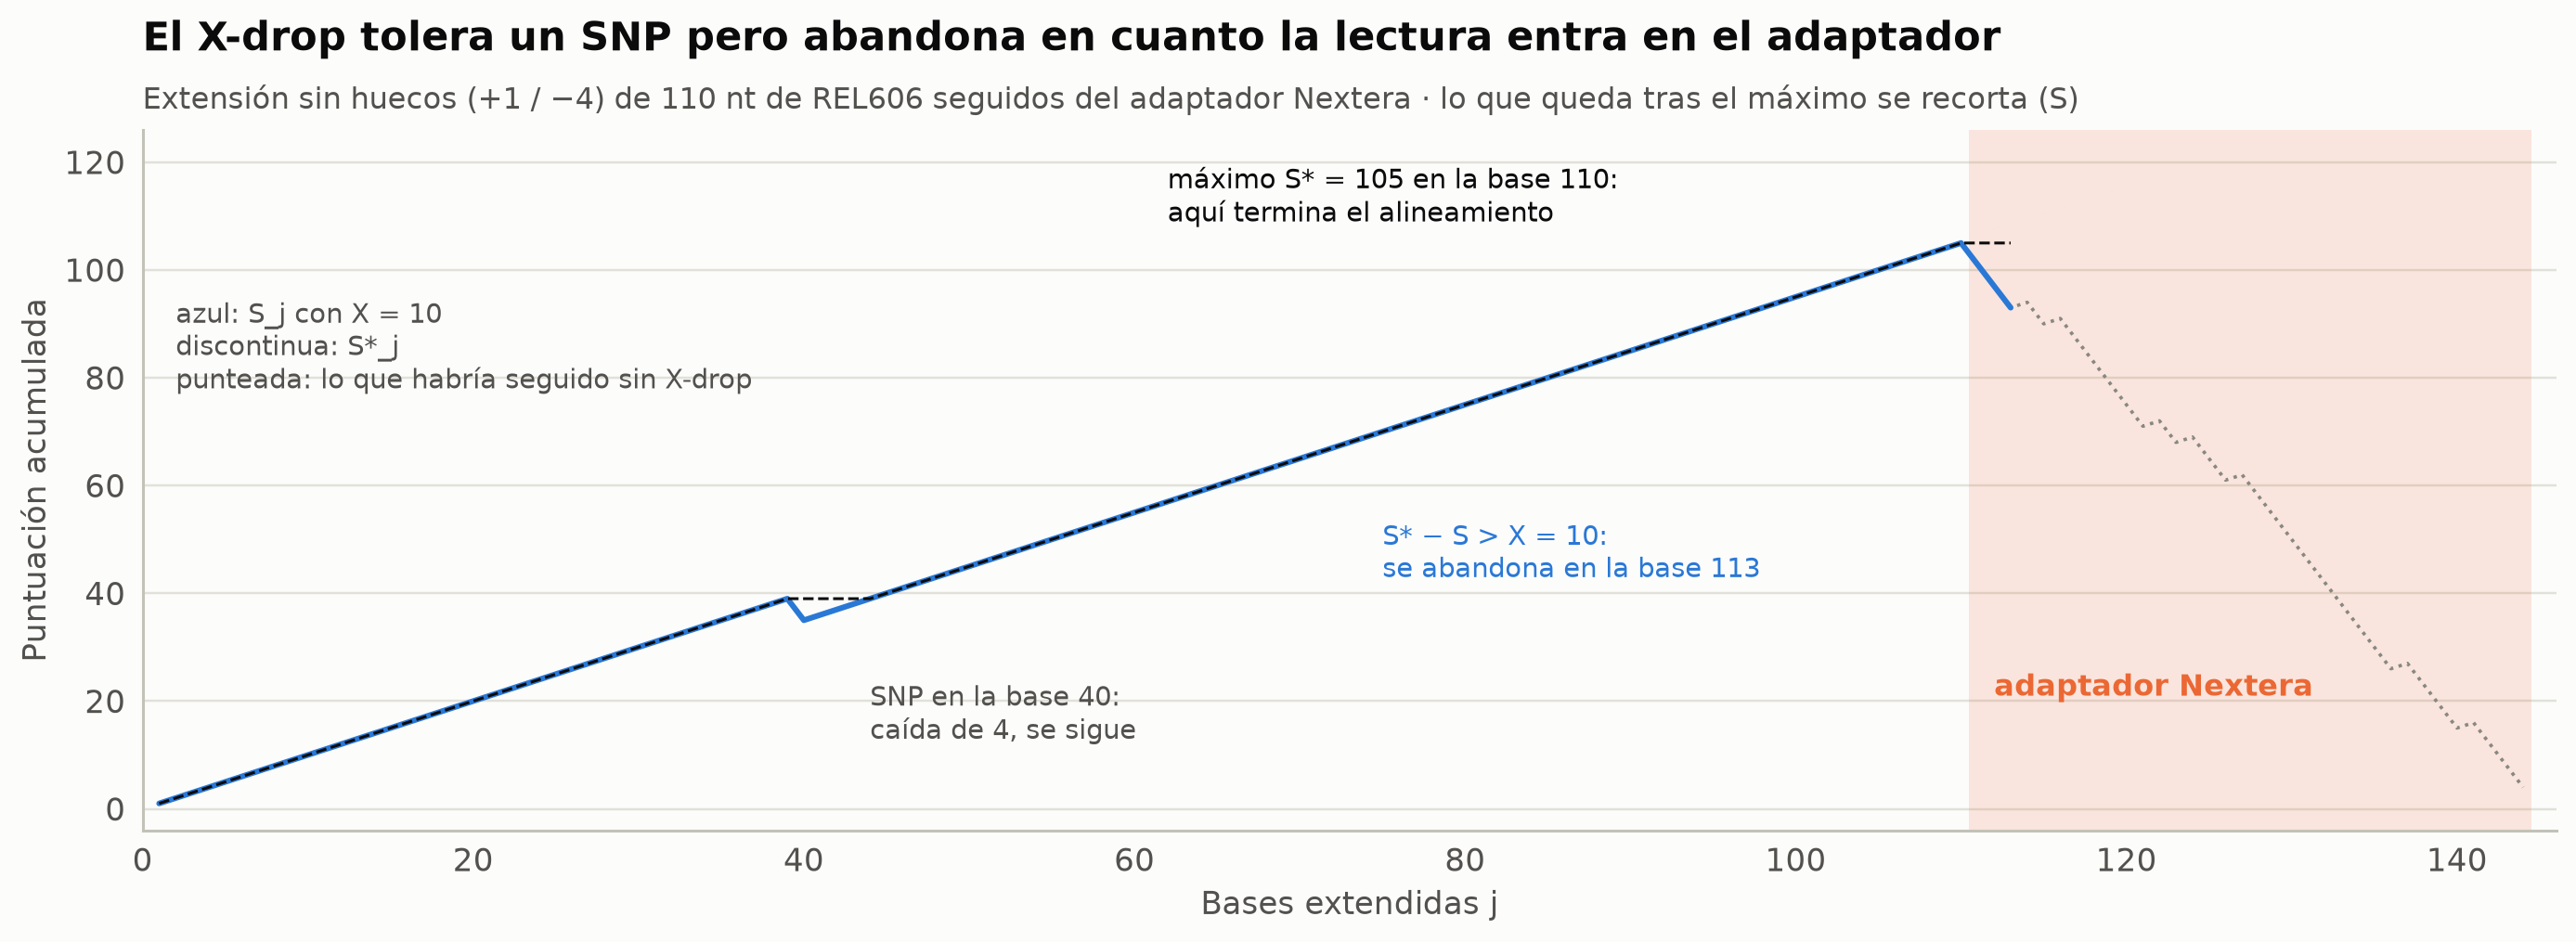

In [13]:
S10, Ss10, stop10, end10 = xdrop_extend(xread, xref, 10)
S_all, Ss_all, _, _ = xdrop_extend(xread, xref, 10_000)       # sin abandonar, para ver la curva completa
fig, ax = plt.subplots(figsize=(12.5, 4.5))
jj = np.arange(1, len(S_all) + 1)
ax.axvspan(110.5, len(xread) + 0.5, color=ec.ORANGE, alpha=0.15, lw=0)
ax.text(112, S_all.max() * 0.2, "adaptador Nextera", color=ec.ORANGE, fontsize=10.5, fontweight="bold")
ax.plot(jj, S_all, color=ec.MUTED, lw=1.2, ls=":")
ax.plot(jj[:len(S10)], S10, color=ec.BLUE, lw=2)
ax.plot(jj[:len(Ss10)], Ss10, color=ec.INK, lw=1, ls="--")
ax.annotate("SNP en la base 40:\ncaída de 4, se sigue", xy=(40, S_all[39]), xytext=(44, S_all[39] - 22),
            fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ax.annotate(f"máximo S* = {Ss10.max()} en la base {end10}:\naquí termina el alineamiento",
            xy=(end10, Ss10.max()), xytext=(end10 - 48, Ss10.max() + 4), fontsize=9.5, color=ec.INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=ec.INK))
ax.annotate(f"S* − S > X = 10:\nse abandona en la base {stop10}", xy=(stop10, S10[-1]), xytext=(stop10 - 38, S10[-1] - 50),
            fontsize=9.5, color=ec.BLUE, arrowprops=dict(arrowstyle="->", color=ec.BLUE))
ax.text(2, S_all.max() * 0.9, "azul: S_j con X = 10\ndiscontinua: S*_j\npunteada: lo que habría seguido sin X-drop",
        fontsize=9.5, color=ec.INK_2, va="top")
ax.set_xlim(0, len(xread) + 2); ax.set_ylim(S_all.min() - 5, S_all.max() * 1.2)
ax.set_xlabel("Bases extendidas j"); ax.set_ylabel("Puntuación acumulada")
ec.title(ax, "El X-drop tolera un SNP pero abandona en cuanto la lectura entra en el adaptador",
         "Extensión sin huecos (+1 / −4) de 110 nt de REL606 seguidos del adaptador Nextera · lo que queda tras el máximo se recorta (S)")
plt.show()

> 🔎 **Qué observamos.** El SNP de la base 40 apenas deja una muesca de 4 puntos: la extensión continúa porque la caída
> no supera $X$. En cuanto empieza el adaptador, tres de cada cuatro bases no coinciden y la curva se desploma; con
> $X = 10$ el algoritmo abandona pocas bases después, sin gastar tiempo en el resto. El alineamiento informado termina en
> el máximo ($S^{*}$), justo antes del adaptador, y la CIGAR sería `110M34S`. Con el $X$ grande de BWA-MEM la extensión
> sigue más lejos, pero el resultado es el mismo: se informa hasta el máximo. Así un mapeador local "limpia" solo el
> *read-through* de adaptador que en la Lección 6.2 quitábamos con un recortador.

### La familia BWA y Bowtie 2

Los mapeadores actuales no nacieron de golpe. La familia BWA pasó por **tres algoritmos**:

| Algoritmo | Idea | Pensado para |
|---|---|---|
| **BWA-*backtrack*** (Li y Durbin, 2009) | búsqueda en el índice FM con **retroceso**, admitiendo unas pocas diferencias | lecturas de 36–100 nt con 2–3 diferencias (los primeros Illumina) |
| **BWA-SW** (Li y Durbin, 2010) | recorre el índice con programación dinámica | las primeras lecturas largas |
| **BWA-MEM** (Li, 2013) | semillas SMEM + encadenamiento + extensión en bandas con *X-drop* | el estándar actual para Illumina (70 nt – algunos kb) |

Con lecturas de 100–250 bases, buscar con errores dentro del índice se vuelve inviable **e innecesario**: una lectura
larga contiene casi con seguridad varios tramos exactos lo bastante largos para ser únicos. BWA-MEM, además, decide
automáticamente entre un alineamiento **local** y uno **de extremo a extremo**: si llegar hasta el final de la lectura
cuesta menos que la penalización por recortar (opción `-L`, 5 puntos), prefiere no recortar. Lo veremos en acción en la
sección 9.

**Bowtie 2** (Langmead y Salzberg, 2012) siguió un camino paralelo: el índice FM encuentra semillas **sin huecos** y
la extensión se hace con programación dinámica **vectorizada** con instrucciones SIMD del procesador (muchas celdas por
instrucción). Sigue siendo muy usado en ChIP-seq y ATAC-seq.

## 4. Minimizers a mano y su densidad $2/(w+1)$

### La idea en palabras simples

Queremos guardar **pocos** $k$-meros del genoma, pero elegidos de forma que cualquier lectura que venga de ahí los
vuelva a elegir. Elegirlos "uno de cada diez", por posición, no sirve: la lectura empieza en una posición arbitraria y
su "uno de cada diez" no coincide con el del genoma. La solución de Roberts *et al.* (2004) es elegir por **contenido**:

> Deslice una **ventana** de $w$ $k$-meros consecutivos a lo largo de la secuencia. En cada ventana, quédese con el
> $k$-mero **más pequeño** según un orden fijo. Ese es el **minimizer** de la ventana.

Como la elección depende sólo de las letras dentro de la ventana, si el genoma y la lectura comparten esa ventana
(los mismos $w + k - 1$ nucleótidos), **ambos eligen el mismo $k$-mero**. Esa es la garantía que necesitamos (la
propiedad de **cobertura**; es la misma que buscaba el algoritmo de *winnowing* para detectar plagio en documentos,
Schleimer *et al.*, 2003). En símbolos, con posiciones 0-based como en Python:

$$
\mu_j \;=\; \arg\min_{j\le i<j+w}\; h\big(s[i..i+k-1]\big)
$$

| Símbolo | Significado |
|---|---|
| $s$ | la secuencia (genoma o lectura) |
| $k$ | longitud de cada $k$-mero |
| $w$ | número de $k$-meros consecutivos por ventana; la ventana abarca $w + k - 1$ bases |
| $h$ | orden total sobre los $k$-meros: el alfabético es el más simple, un *hash* pseudoaleatorio el más eficaz |
| $\mu_j$ | posición del $k$-mero elegido en la ventana que empieza en $j$; el conjunto de minimizers es $\{\mu_j\}$ |

### Ejemplo resuelto a mano: $k = 3$, $w = 4$, orden alfabético

Secuencia de 19 nt: `GTCATGCACGTTCAGGTAC`. Sus $19 - 3 + 1 = 17$ $k$-meros, numerados:

| # | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| $k$-mero | GTC | TCA | CAT | **ATG** | TGC | GCA | CAC | **ACG** | **CGT** | GTT | TTC | TCA | **CAG** | **AGG** | GGT | GTA | TAC |

Con $w = 4$ hay $17 - 4 + 1 = 14$ ventanas. Recorremos las primeras a mano, comparando alfabéticamente (A < C < G < T):

| Ventana | $k$-meros que contiene | El menor | Posición |
|---|---|---|---|
| 1–4 | GTC, TCA, CAT, ATG | ATG | 4 |
| 2–5 | TCA, CAT, ATG, TGC | ATG | 4 (el mismo: no se añade nada) |
| 3–6 | CAT, ATG, TGC, GCA | ATG | 4 |
| 4–7 | ATG, TGC, GCA, CAC | ATG | 4 |
| 5–8 | TGC, GCA, CAC, ACG | ACG | 8 (ATG salió de la ventana) |
| 6–9, 7–10, 8–11 | … | ACG | 8 |
| 9–12 | CGT, GTT, TTC, TCA | CGT | 9 (ACG salió) |
| 10–13 | GTT, TTC, TCA, CAG | CAG | 13 (entra CAG, menor que todos) |
| 11–14 … 14–17 | … | AGG | 14 |

Resultado: los minimizers son los $k$-meros **4, 8, 9, 13 y 14**: se guardan 5 de 17 $k$-meros (29 %). Observe los dos
momentos en que aparece un minimizer nuevo: cuando **el mínimo anterior sale** por la izquierda de la ventana
(posiciones 8 y 9) o cuando **entra por la derecha** un $k$-mero menor que todos (posiciones 13 y 14).

In [14]:
def minimizers_naive(seq, k, w, order=lambda kmer: kmer):
    """Minimizers por definición (lento pero transparente): posiciones 0-based de los k-meros elegidos."""
    kmers = [seq[i:i + k] for i in range(len(seq) - k + 1)]
    chosen = []
    for s in range(len(kmers) - w + 1):
        window = kmers[s:s + w]
        j = min(range(w), key=lambda t: order(window[t]))       # el menor; en empate, el de más a la izquierda
        if not chosen or chosen[-1] != s + j:
            chosen.append(s + j)
    return chosen

hand_seq = "GTCATGCACGTTCAGGTAC"
pos = minimizers_naive(hand_seq, k=3, w=4)
print("Minimizers (posiciones 1-based):", [p + 1 for p in pos], "→", [hand_seq[p:p + 3] for p in pos])
print(f"Densidad: {len(pos)} de {len(hand_seq) - 2} k-meros = {len(pos) / (len(hand_seq) - 2):.2f}")

# el mismo cálculo con el ejemplo de la figura de minimizadores del libro (w = 4, k = 3, orden alfabético)
book_seq = "GATTACAGGTCCATGACATTGCAA"
pos_b = minimizers_naive(book_seq, k=3, w=4)
n_kb = len(book_seq) - 3 + 1
print(f"\nEjemplo del libro {book_seq}: posiciones 0-based {pos_b} (1-based {[p + 1 for p in pos_b]})")
print("   k-meros elegidos:", [book_seq[p:p + 3] for p in pos_b])
print(f"   {len(set(pos_b))} de {n_kb} k-meros → δ = {len(set(pos_b)) / n_kb:.3f} frente a 2/(w+1) = {2 / 5:.3f}")

Minimizers (posiciones 1-based): [4, 8, 9, 13, 14] → ['ATG', 'ACG', 'CGT', 'CAG', 'AGG']
Densidad: 5 de 17 k-meros = 0.29

Ejemplo del libro GATTACAGGTCCATGACATTGCAA: posiciones 0-based [1, 4, 6, 10, 11, 12, 15, 17, 21] (1-based [2, 5, 7, 11, 12, 13, 16, 18, 22])
   k-meros elegidos: ['ATT', 'ACA', 'AGG', 'CCA', 'CAT', 'ATG', 'ACA', 'ATT', 'CAA']
   9 de 22 k-meros → δ = 0.409 frente a 2/(w+1) = 0.400


![Una ventana de w = 5 k-meros (k = 4) recorre 40 nt reales de REL606; en cada paso se marca el k-mero menor, y la lista de minimizers sólo crece cuando el mínimo sale de la ventana o entra uno menor](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.2_ventana_minimizer.gif)

*Una ventana de w = 5 k-meros (k = 4) recorre 40 nt reales de REL606; en cada paso se marca el k-mero menor, y la lista de minimizers sólo crece cuando el mínimo sale de la ventana o entra uno menor*

In [15]:
anim_seq = genome[226_609 - 1:226_609 - 1 + 40]          # los primeros 40 nt del 16S del operón rrn-1
ka, wa = 4, 5
kmers_a = [anim_seq[i:i + ka] for i in range(len(anim_seq) - ka + 1)]
n_win = len(kmers_a) - wa + 1

fig, ax = plt.subplots(figsize=(13, 3.9))

def update(f):
    ax.clear()
    s = min(f, n_win - 1)
    window = kmers_a[s:s + wa]
    j = s + min(range(wa), key=lambda t: window[t])
    chosen = minimizers_naive(anim_seq[:s + wa + ka - 1], ka, wa)
    for i, b in enumerate(anim_seq):
        ax.text(i + 0.5, 3.2, b, ha="center", va="center", fontsize=13, fontweight="bold",
                color=ec.NUC_COLORS[b], family="monospace")
    ax.add_patch(Rectangle((s, 2.55), wa + ka - 1, 1.3, fill=False, ec=ec.INK_2, lw=1.8, ls="--"))
    ax.text(s, 4.15, f"ventana {s + 1}: {wa} k-meros = {wa + ka - 1} nt", fontsize=10, color=ec.INK_2)
    for t in range(s, s + wa):                                  # los k-meros de la ventana, escalonados
        y = 2.1 - 0.33 * (t - s)
        col = ec.ORANGE if t == j else ec.MUTED
        ax.plot([t + 0.1, t + ka - 0.1], [y, y], color=col, lw=4 if t == j else 2, solid_capstyle="butt")
        ax.text(t + ka + 0.2, y, kmers_a[t], fontsize=9, va="center", family="monospace",
                color=ec.ORANGE if t == j else ec.INK_2, fontweight="bold" if t == j else "normal")
    for n_c, c in enumerate(chosen):                         # cada minimizer elegido, escalonado para distinguirlos
        ax.plot([c + 0.1, c + ka - 0.1], [-0.2 - 0.18 * (n_c % 3)] * 2, color=ec.BLUE, lw=3.5, solid_capstyle="butt")
    ax.text(0, -0.8, f"minimizers elegidos hasta ahora: {len(chosen)} de {s + wa} k-meros vistos "
                      f"(teoría: 2/(w+1) = {2 / (wa + 1):.2f})", fontsize=10.5, color=ec.BLUE, va="top")
    ax.set_xlim(-0.5, len(anim_seq) + 0.5); ax.set_ylim(-1.5, 4.5); ax.axis("off")
    ax.set_title(f"El menor k-mero de la ventana (alfabético) es {kmers_a[j]}, en la posición {j + 1}",
                 fontsize=12.5, loc="left")
    return []

ec.animate(fig, update, frames=n_win + 3, interval=450, name="7.2_ventana_minimizer")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### ¿Cuántos minimizers se guardan? La densidad $2/(w+1)$

La **densidad** $\delta$ es la fracción de $k$-meros que resultan elegidos. Un razonamiento sencillo da su valor esperado
cuando el orden de los $k$-meros es "aleatorio" (todos distintos y sin relación entre vecinos).

Compare dos ventanas consecutivas, la $j$ y la $j+1$. Juntas cubren $w + 1$ $k$-meros: el que **sale** (el primero de
la ventana $j$), los $w - 1$ del medio que comparten, y el que **entra** (el último de la ventana $j+1$). Sólo aparece un
minimizer **nuevo** en la ventana $j+1$ si el mínimo de esos $w+1$ $k$-meros es el que sale (el viejo mínimo se fue y
hay que elegir otro) o el que entra (el recién llegado es el menor). Si el mínimo está entre los $w-1$ del medio, las dos
ventanas eligen el mismo. Con un orden aleatorio, cada uno de los $w + 1$ $k$-meros tiene la misma probabilidad de ser
el menor, así que:

$$
\delta \;\approx\; P(\text{minimizer nuevo en la ventana } j+1) \;=\; \frac{2}{w+1}
$$

| Símbolo | Significado |
|---|---|
| $k$ | longitud de cada $k$-mero |
| $w$ | número de $k$-meros consecutivos en cada ventana |
| $h$ | orden total sobre los $k$-meros (alfabético, o un *hash* pseudoaleatorio) |
| $\delta$ | densidad: número de minimizers dividido por el número de $k$-meros (fracción de posiciones que se guardan en el índice) |
| $w + k - 1$ | nucleótidos que abarca una ventana: tramo exacto compartido que **garantiza** un minimizer común |

Con $w = 10$ se guarda sólo un $k$-mero de cada 5.5. Con los parámetros de `minimap2 -x sr` ($k = 21$, $w = 11$),
$\delta = 2/12 \approx 0.167$: el índice guarda uno de cada
seis $k$-meros, y dos secuencias que comparten 31 nt idénticos comparten al menos un minimizer.

Hay un detalle práctico. El orden **alfabético** es mala idea con ADN real: favorece a los $k$-meros ricos en A
(`AAAA…` es el menor posible), que abundan en regiones poco complejas y se eligen una y otra vez. minimap2 ordena los
$k$-meros por el valor de una **función hash** invertible (un "revolvedor" de bits que asigna a cada $k$-mero un número
pseudoaleatorio), y además usa $k$-meros **canónicos**: para cada $k$-mero toma el menor hash entre él y su complemento
inverso, para que la lectura se encuentre igual venga de una hebra o de la otra.

> 🤔 **Antes de ejecutar, prediga.** ¿La densidad del orden alfabético sobre el genoma real será mayor o menor que
> $2/(w+1)$? ¿Y la del orden por hash?

Programemos una versión vectorizada con NumPy (cada $k$-mero se codifica en 2 bits por base, así un $k$-mero de 21 nt
es un entero de 42 bits) y midamos la densidad en una secuencia aleatoria y en el genoma de REL606, con ambos órdenes.

In [16]:
LUT = np.full(256, 0, np.uint8)
for i_, b_ in enumerate("ACGT"):
    LUT[ord(b_)] = i_

def encode(seq):
    """ADN → enteros 0..3 (A, C, G, T)."""
    return LUT[np.frombuffer(seq.encode(), np.uint8)]

def kmer_codes(seq, k):
    """Códigos de 2 bits de todos los k-meros, en la hebra directa y en su complemento inverso."""
    x = encode(seq).astype(np.uint64)
    n = len(x) - k + 1
    fwd, rev = np.zeros(n, np.uint64), np.zeros(n, np.uint64)
    xc = np.uint64(3) - x
    for j in range(k):
        fwd = (fwd << np.uint64(2)) | x[j:j + n]
        rev = rev | (xc[j:j + n] << np.uint64(2 * j))
    return fwd, rev

def hash64(key, k):
    """Hash invertible de enteros (Thomas Wang), el mismo tipo de función que usa minimap2."""
    m = np.uint64((1 << (2 * k)) - 1)
    key = (~key + (key << np.uint64(21))) & m
    key = key ^ (key >> np.uint64(24))
    key = ((key + (key << np.uint64(3))) + (key << np.uint64(8))) & m
    key = key ^ (key >> np.uint64(14))
    key = ((key + (key << np.uint64(2))) + (key << np.uint64(4))) & m
    key = key ^ (key >> np.uint64(28))
    key = (key + (key << np.uint64(31))) & m
    return key

def minimizers(seq, k, w, order="hash"):
    """Minimizers canónicos: devuelve (posiciones 0-based, valor, hebra 0/1 del k-mero elegido)."""
    fwd, rev = kmer_codes(seq, k)
    if order == "hash":
        hf, hr = hash64(fwd, k), hash64(rev, k)
    else:                                   # orden alfabético: el propio código de 2 bits
        hf, hr = fwd, rev
    val = np.minimum(hf, hr)
    strand = (hr < hf).astype(np.int8)
    if len(val) < w:
        return np.array([], np.int64), val[:0], strand[:0]
    pos = np.unique(sliding_window_view(val, w).argmin(axis=1) + np.arange(len(val) - w + 1))
    return pos, val[pos], strand[pos]

# comprobación: la versión vectorizada coincide con la definición (una hebra, orden alfabético)
fw_only = minimizers_naive(hand_seq, 3, 4)
v = kmer_codes(hand_seq, 3)[0]
vec = np.unique(sliding_window_view(v, 4).argmin(1) + np.arange(len(v) - 3))
print("Definición:", [p + 1 for p in fw_only], "· NumPy:", list(vec + 1))

Definición: [4, 8, 9, 13, 14] · NumPy: [np.int64(4), np.int64(8), np.int64(9), np.int64(13), np.int64(14)]


In [17]:
K_SR = 21
random_seq = "".join(rng.choice(list("ACGT"), 500_000))
w_values = [2, 4, 8, 11, 16, 30]
rows = []
t0 = time.time()
for w in w_values:
    for src, s in [("aleatoria", random_seq), ("REL606", genome)]:
        for order in ("hash", "alfabético"):
            n_min = len(minimizers(s, K_SR, w, "hash" if order == "hash" else "lex")[0])
            rows.append(dict(w=w, secuencia=src, orden=order, densidad=n_min / (len(s) - K_SR + 1)))
dens = pd.DataFrame(rows)
print(f"Calculado en {time.time() - t0:.1f} s")
print(dens.pivot_table(index="w", columns=["secuencia", "orden"], values="densidad").round(4)
      .assign(teoria=lambda d: (2 / (d.index + 1)).round(4)).to_string())

# el experimento del libro: 200 000 pb aleatorias, k = 15, w = 10 (los parámetros de map-ont)
rs200 = random_seq[:200_000]
for order in ("hash", "lex"):
    n_min = len(minimizers(rs200, 15, 10, order)[0])
    print(f"200 kb aleatorias, k = 15, w = 10, orden {order:4s}: δ = {n_min / (len(rs200) - 15 + 1):.3f} "
          f"(teoría 2/11 = {2 / 11:.3f})")

Calculado en 13.8 s
secuencia     REL606          aleatoria          teoria
orden     alfabético    hash alfabético    hash        
w                                                      
2             0.7040  0.6667     0.6934  0.6670  0.6667
4             0.4387  0.4000     0.4250  0.4000  0.4000
8             0.2517  0.2221     0.2413  0.2216  0.2222
11            0.1909  0.1667     0.1831  0.1666  0.1667
16            0.1374  0.1177     0.1318  0.1174  0.1176
30            0.0756  0.0646     0.0726  0.0645  0.0645
200 kb aleatorias, k = 15, w = 10, orden hash: δ = 0.189 (teoría 2/11 = 0.182)
200 kb aleatorias, k = 15, w = 10, orden lex : δ = 0.200 (teoría 2/11 = 0.182)


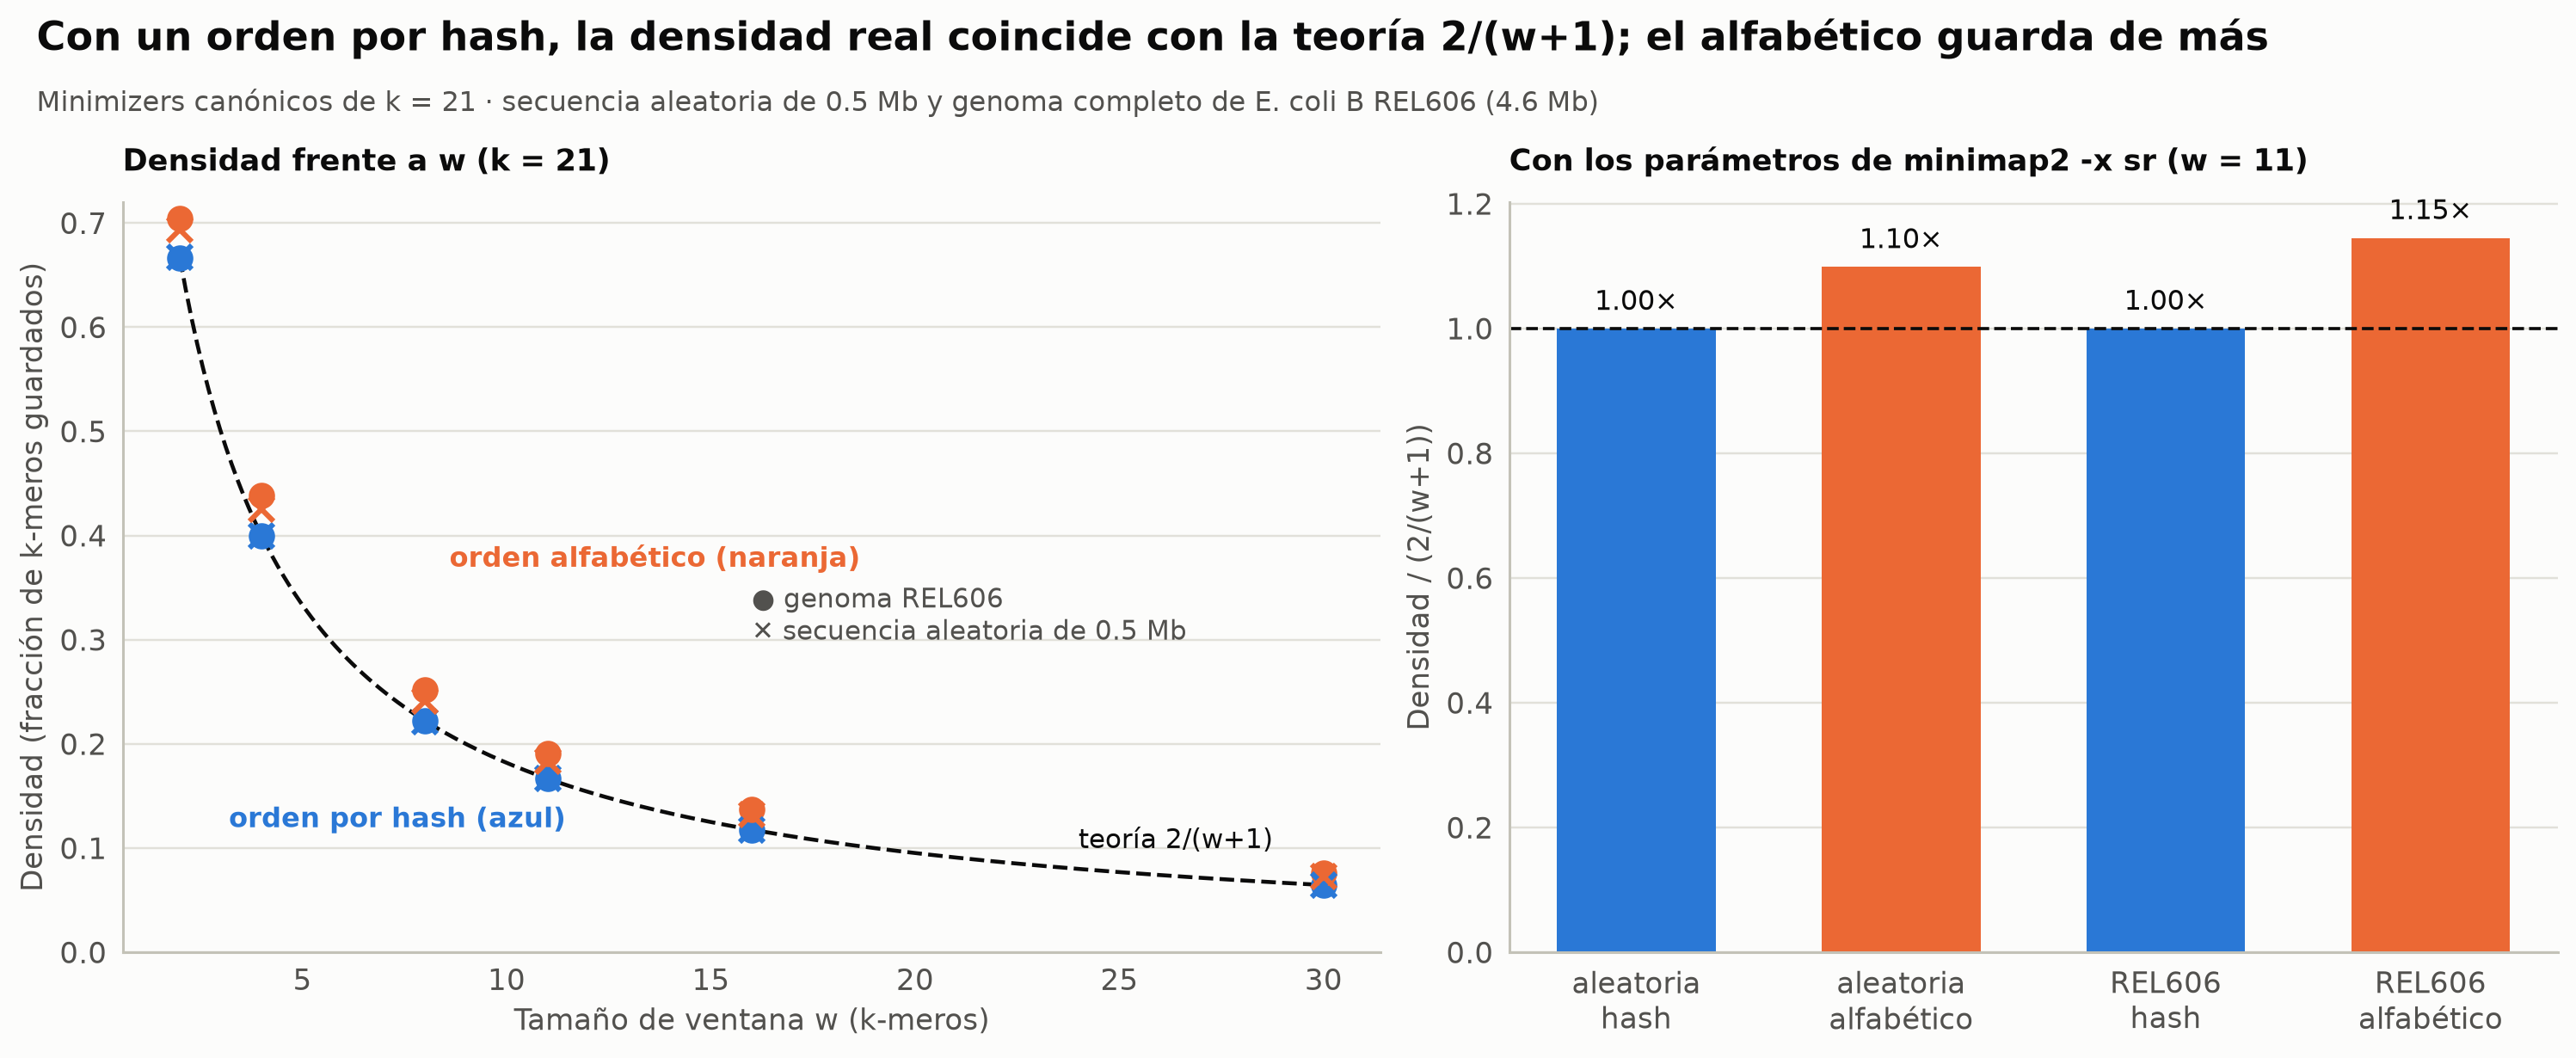

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), gridspec_kw=dict(width_ratios=[1.2, 1]))
ax = axes[0]
wt = np.linspace(2, 30, 200)
ax.plot(wt, 2 / (wt + 1), color=ec.INK, lw=1.5, ls="--")
ax.text(24, 2 / 25 + 0.02, "teoría 2/(w+1)", fontsize=10, color=ec.INK)
styles = {("REL606", "hash"): (ec.BLUE, "o"), ("REL606", "alfabético"): (ec.ORANGE, "o"),
          ("aleatoria", "hash"): (ec.BLUE, "x"), ("aleatoria", "alfabético"): (ec.ORANGE, "x")}
for (src, order), (col, mk) in styles.items():
    d = dens[(dens.secuencia == src) & (dens.orden == order)]
    ax.plot(d.w, d.densidad, marker=mk, ls="none", color=col, ms=8 if mk == "o" else 9, mew=2)
ax.text(8.6, 0.37, "orden alfabético (naranja)", color=ec.ORANGE, fontsize=10.5, fontweight="bold")
ax.text(3.2, 0.12, "orden por hash (azul)", color=ec.BLUE, fontsize=10.5, fontweight="bold")
ax.text(16, 0.30, "● genoma REL606\n✕ secuencia aleatoria de 0.5 Mb", fontsize=10, color=ec.INK_2)
ax.set_xlabel("Tamaño de ventana w (k-meros)"); ax.set_ylabel("Densidad (fracción de k-meros guardados)")
ax.set_ylim(0, 0.72)
ax.set_title("Densidad frente a w (k = 21)", fontsize=11.5, loc="left")
ax = axes[1]
d11 = dens[dens.w == 11].copy()
d11["ratio"] = d11.densidad / (2 / 12)
labels_ = [f"{r.secuencia}\n{r.orden}" for r in d11.itertuples()]
bars = ax.bar(range(len(d11)), d11.ratio, color=[ec.BLUE if o == "hash" else ec.ORANGE for o in d11.orden], width=0.6)
ax.axhline(1, color=ec.INK, ls="--", lw=1.2)
for i_, r_ in enumerate(d11.ratio):
    ax.text(i_, r_ + 0.03, f"{r_:.2f}×", ha="center", fontsize=10.5)
ax.set_xticks(range(len(d11)), labels_)
ax.set_ylabel("Densidad / (2/(w+1))")
ax.set_title("Con los parámetros de minimap2 -x sr (w = 11)", fontsize=11.5, loc="left")
ec.fig_title(fig, "Con un orden por hash, la densidad real coincide con la teoría 2/(w+1); el alfabético guarda de más",
             "Minimizers canónicos de k = 21 · secuencia aleatoria de 0.5 Mb y genoma completo de E. coli B REL606 (4.6 Mb)")
plt.show()

> 🔎 **Qué observamos.** Con el orden por hash, la densidad medida en el genoma real coincide con $2/(w+1)$ hasta el
> tercer decimal para todos los $w$: el genoma de *E. coli*, visto a través de una función hash, se comporta como una
> secuencia aleatoria. Con el orden alfabético la densidad es claramente **mayor**, en la secuencia aleatoria y todavía
> más en el genoma: los $k$-meros consecutivos se solapan en $k-1$ letras, así que cuando uno empieza por varias A, su
> vecino también es "pequeño"; el mínimo cambia más a menudo y se guardan más posiciones sin ganar nada a cambio. Por
> eso minimap2 usa un hash. El experimento del libro (200 kb aleatorias, $k = 15$, $w = 10$) da lo mismo: $\delta \approx 0.19$
> con hash frente a la teoría $2/11 = 0.182$, y $\approx 0.20$ con orden alfabético (el libro obtiene 0.188 y 0.199 con
> otra secuencia aleatoria; nosotros además usamos $k$-meros canónicos). Y el ejemplo de la figura del libro reproduce
> sus 9 minimizers de 22 $k$-meros ($\delta = 0.41$ frente a $2/(w+1) = 0.40$).

> ✅ **Compruebe su comprensión.** (1) Si duplica $w$ de 11 a 22, ¿cuánto se reduce aproximadamente el índice? ¿Qué se
> pierde? (2) ¿Por qué hacen falta $w + k - 1$ nucleótidos idénticos, y no sólo $k$, para garantizar un minimizer
> compartido?
>
> *Respuestas:* (1) De $2/12$ a $2/23$: casi a la mitad. Se pierde sensibilidad: hace falta un tramo exacto de
> $22 + 21 - 1 = 42$ nt, y una lectura con muchos errores puede no tenerlo. (2) Porque la garantía viene de compartir una
> **ventana completa**, que abarca $w$ $k$-meros, es decir, $w + k - 1$ nucleótidos.

## 5. Un mapeador de juguete en NumPy

Con las piezas anteriores podemos construir un mapeador completo en unas 80 líneas. No competirá con minimap2 en
velocidad (está escrito en Python), pero hará **exactamente** los mismos tres pasos, y así cada número del BAM de la
sección 7 tendrá sentido.

### Paso 0: el índice

Calculamos los minimizers canónicos de todo el genoma con los parámetros de `minimap2 -x sr` ($k = 21$, $w = 11$) y los
**ordenamos por valor de hash**. Buscar un minimizer de la lectura se reduce entonces a una búsqueda binaria
(`np.searchsorted`) en ese arreglo ordenado: el mismo servicio que presta una tabla hash.

In [19]:
K, W = 21, 11
t0 = time.time()
g_pos, g_val, g_strand = minimizers(genome, K, W)
order_ = np.argsort(g_val, kind="stable")
g_pos, g_val, g_strand = g_pos[order_], g_val[order_], g_strand[order_]
t_index = time.time() - t0
uniq_val, occ = np.unique(g_val, return_counts=True)
print(f"Índice construido en {t_index:.1f} s: {len(g_pos):,} minimizers "
      f"(densidad {len(g_pos) / (G - K + 1):.4f}; teoría {2 / (W + 1):.4f})")
print(f"Valores distintos: {len(uniq_val):,} · aparecen una sola vez: {np.mean(occ == 1):.2%} · "
      f"máximo de apariciones: {occ.max()}")

Índice construido en 0.9 s: 771,702 minimizers (densidad 0.1667; teoría 0.1667)
Valores distintos: 754,708 · aparecen una sola vez: 99.21% · máximo de apariciones: 61


Casi todos los minimizers aparecen **una sola vez** en el genoma: una semilla basta para saber de dónde viene una
lectura. ¿Dónde están los que se repiten? Marquemos en el genoma los minimizers que aparecen 5 o más veces y veamos si
caen en los operones *rrn* o en los elementos IS.

Minimizers con ≥ 5 apariciones: 13234 {np.str_('operón rrn'): 5232, np.str_('elemento IS'): 6063, np.str_('otro (sobre todo REP)'): 1939}


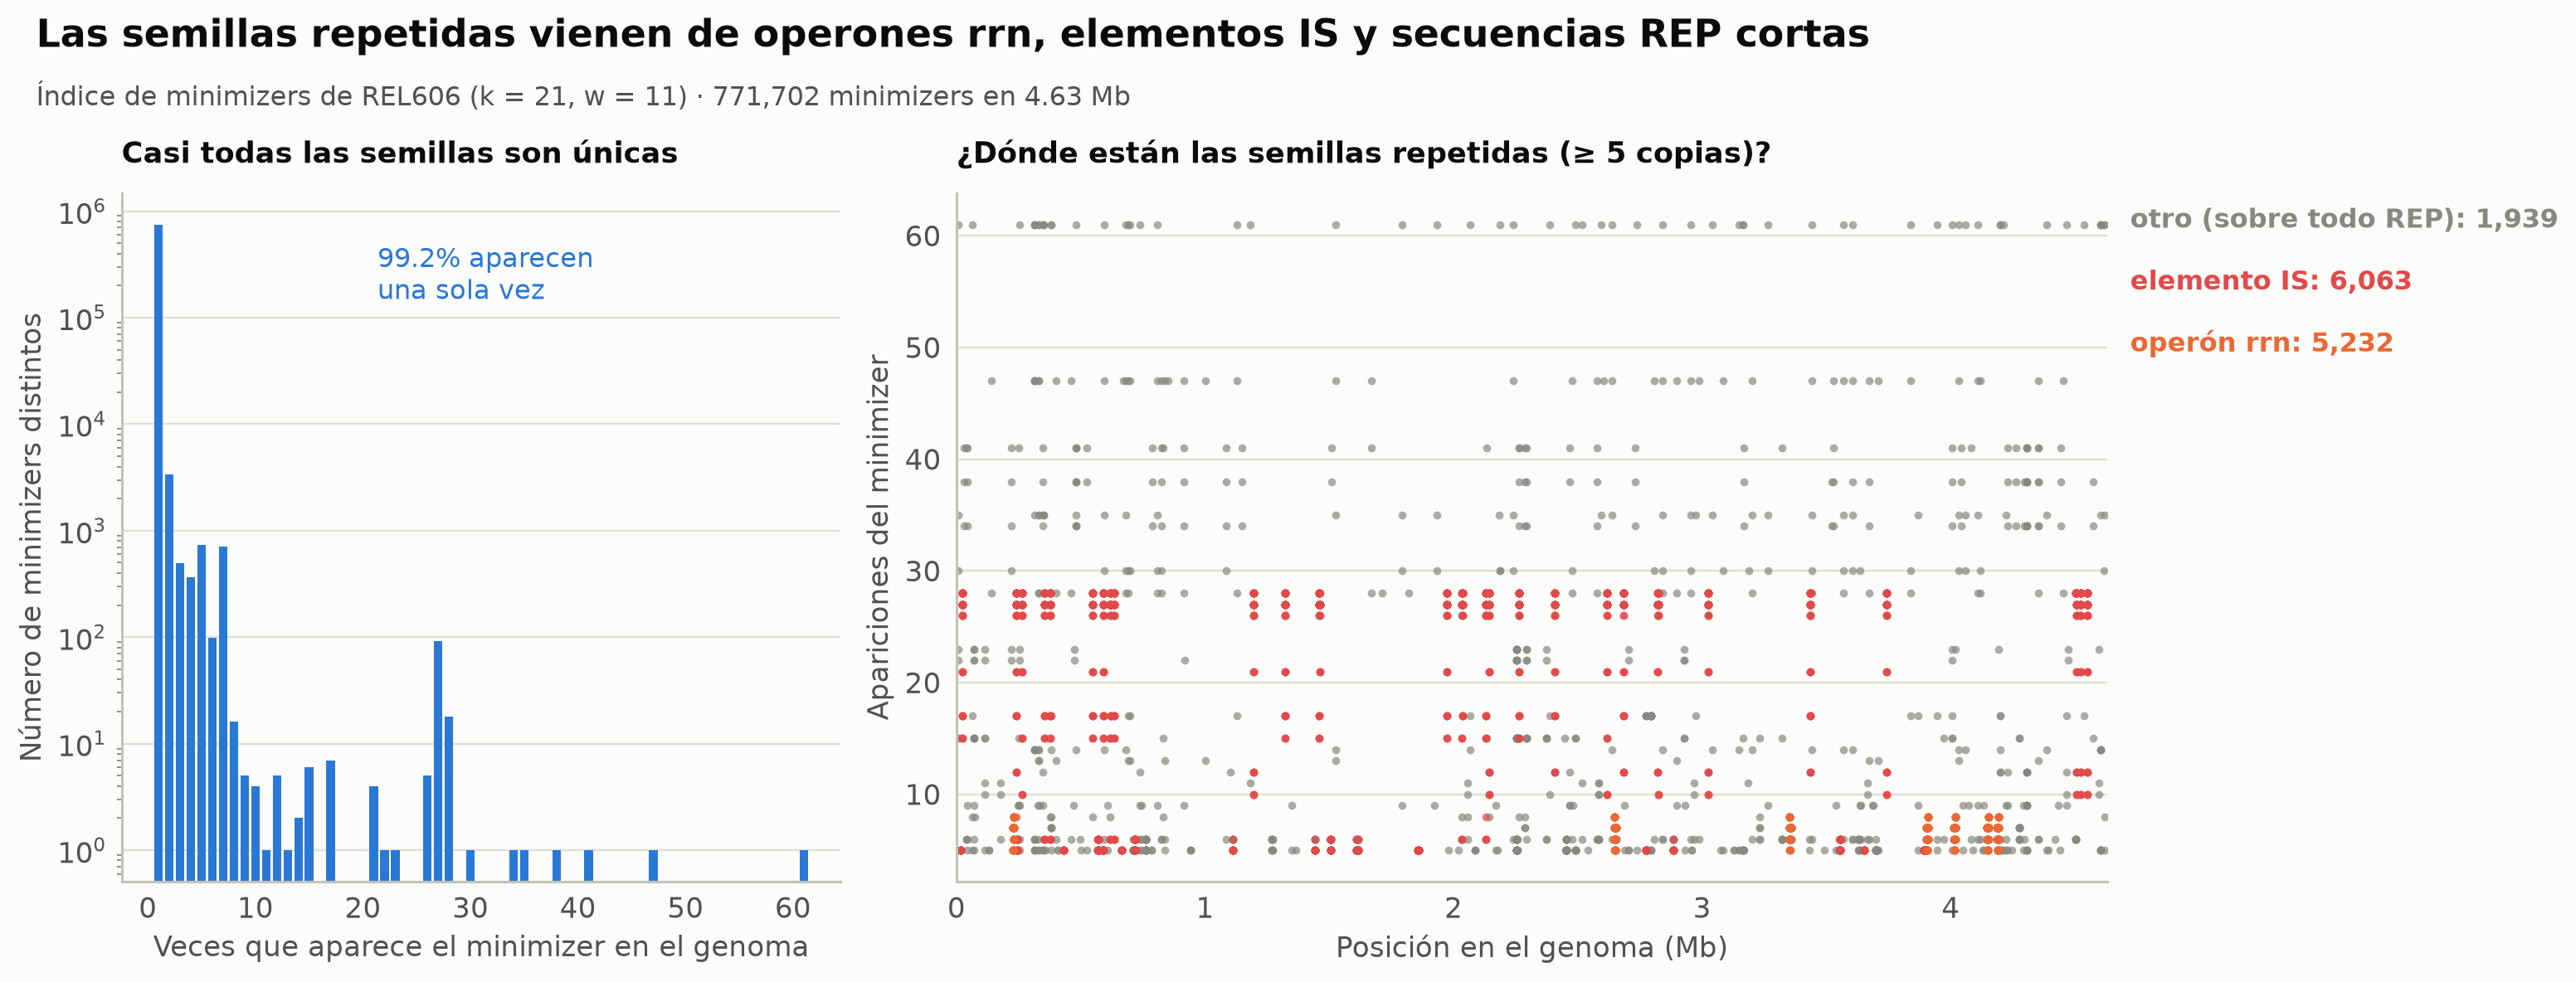

In [20]:
def in_intervals(positions, starts, ends):
    """¿Cae cada posición (1-based) dentro de alguno de los intervalos [start, end]?"""
    o = np.argsort(starts)
    s_, e_ = np.asarray(starts)[o], np.asarray(ends)[o]
    idx = np.searchsorted(s_, positions, side="right") - 1
    return (idx >= 0) & (positions <= e_[np.clip(idx, 0, None)])

occ_of = np.repeat(occ, occ)                           # apariciones de cada minimizer del índice (mismo orden)
rep_pos = g_pos[occ_of >= 5] + 1
where = np.where(in_intervals(rep_pos, operons.start, operons.end), "operón rrn",
                 np.where(in_intervals(rep_pos, is_elems.start, is_elems.end), "elemento IS", "otro (sobre todo REP)"))
print("Minimizers con ≥ 5 apariciones:", len(rep_pos), dict(Counter(where)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1, 1.6]))
ax = axes[0]
cnt = Counter(occ)
xs_ = np.array(sorted(cnt)); ys_ = np.array([cnt[x] for x in xs_])
ax.bar(xs_, ys_, color=ec.BLUE, width=0.8)
ax.set_yscale("log"); ax.set_xlabel("Veces que aparece el minimizer en el genoma"); ax.set_ylabel("Número de minimizers distintos")
ax.text(xs_.max() * 0.35, ys_.max() / 5, f"{np.mean(occ == 1):.1%} aparecen\nuna sola vez", fontsize=10.5, color=ec.BLUE)
ax.set_title("Casi todas las semillas son únicas", fontsize=11.5, loc="left")
ax = axes[1]
colors_ = {"otro (sobre todo REP)": ec.MUTED, "elemento IS": ec.RED, "operón rrn": ec.ORANGE}
occ_rep = occ_of[occ_of >= 5]
for lab, col in colors_.items():
    m_ = where == lab
    ax.scatter(rep_pos[m_] / 1e6, occ_rep[m_], s=10, color=col, alpha=0.7)
    ax.text(1.02, 0.95 - 0.09 * list(colors_).index(lab), f"{lab}: {m_.sum():,}", transform=ax.transAxes,
            color=col, fontsize=10.5, fontweight="bold")
ax.set_xlabel("Posición en el genoma (Mb)"); ax.set_ylabel("Apariciones del minimizer")
ax.set_xlim(0, G / 1e6)
ax.set_title("¿Dónde están las semillas repetidas (≥ 5 copias)?", fontsize=11.5, loc="left")
ec.fig_title(fig, "Las semillas repetidas vienen de operones rrn, elementos IS y secuencias REP cortas",
             f"Índice de minimizers de REL606 (k = {K}, w = {W}) · {len(g_pos):,} minimizers en {G / 1e6:.2f} Mb")
plt.show()

> 🔎 **Qué observamos.** La inmensa mayoría de las semillas aparecen una sola vez. Las que se repiten forman "filas"
> en el panel derecho: el mismo $k$-mero presente en muchas copias. Hay tres fuentes. Los **operones *rrn*** (naranja)
> aportan semillas con ≈ 7 apariciones; los **elementos IS** (rojo), con 15 a 28 (IS1 tiene 28 copias en REL606). Las
> filas grises más altas (35–61 apariciones) no están en genes: son **secuencias REP** (*repetitive extragenic
> palindromic*), palíndromos de ≈ 35 nt como `GCCGGATAAGGCGTTCACGCCGCATCCGGC` que aparecen cientos de veces entre los
> genes de *E. coli*. Las REP son tan cortas que una lectura de 150 nt que contiene una tiene de sobra secuencia única
> a los lados; los operones y los IS, en cambio, son más largos que una lectura, y ahí se producirán las lecturas
> **multimapeadas** de la sección 6.

### Paso 1: semillas y anclas

Para una lectura, calculamos sus minimizers y buscamos cada uno en el índice. Cada aparición produce un **ancla**
$(x_i, y_i, w_i)$: una coincidencia exacta de $w_i$ bases que **termina** en la posición $x_i$ de la referencia y en la
$y_i$ de la lectura. Con minimizers, todas las anclas miden lo mismo: $w_i = k$. Cada ancla lleva además su **hebra
relativa** (+ o −): si el minimizer se eligió en la misma hebra en la lectura y en el genoma, la lectura viene de la
hebra directa; si no, del reverso complementario $\bar q$, y entonces medimos la posición sobre la lectura invertida.

*Una nota de implementación.* Nuestro código guarda el **inicio** de cada ancla, no su final. Como todas miden $k$, el
final es el inicio más $k - 1$, y las **diferencias** $x_i - x_j$, $y_i - y_j$ (que son lo único que usa el
encadenamiento) son idénticas con una u otra convención.

### Paso 2: encadenamiento por programación dinámica

Las anclas verdaderas se alinean a lo largo de una diagonal; las espurias, procedentes de repeticiones, quedan
dispersas. Ordenamos las anclas de cada hebra por $x$ y calculamos, para cada ancla $i$, la puntuación $f(i)$ de la
mejor cadena que termina en ella, con la recurrencia de minimap2 (Li, 2018):

$$
f(i) \;=\; \max\Big\{\max_{j<i}\big\{f(j) + \alpha(j,i) - \beta(j,i)\big\},\; w_i\Big\}
$$

$$
\alpha(j,i) = \min\big\{\min\{y_i-y_j,\; x_i-x_j\},\; w_i\big\},\qquad
\beta(j,i) = \gamma\big((y_i-y_j)-(x_i-x_j)\big),\qquad
\gamma(\ell) = \begin{cases} 0.01\,\bar w\,|\ell| + 0.5\log_2|\ell| & \ell\neq 0\\ 0 & \ell = 0\end{cases}
$$

| Símbolo | Significado |
|---|---|
| $(x_i, y_i, w_i)$ | ancla $i$: termina en la posición $x_i$ de la referencia y $y_i$ de la lectura, y cubre $w_i$ bases idénticas (aquí $w_i = k = 21$) |
| $f(i)$ | puntuación máxima de una cadena de anclas que termina en $i$ |
| $\alpha(j,i)$ | bases coincidentes que el ancla $i$ añade tras la $j$ (no cuenta dos veces el solapamiento) |
| $\ell = (y_i-y_j)-(x_i-x_j)$ | desfase entre las distancias en lectura y referencia: un *indel* de longitud $\lvert\ell\rvert$ ($\ell < 0$: faltan bases en la lectura, una deleción) |
| $\beta(j,i) = \gamma(\ell)$ | penalización por ese desfase: lineal en $\lvert\ell\rvert$ más un término logarítmico |
| $\bar w$ | longitud media de las semillas (aquí $\bar w = 21$) |

La recurrencia es de tipo Smith–Waterman (Lección 3.2) pero sobre **anclas** en lugar de bases: el término $w_i$
permite **empezar** una cadena nueva, igual que el 0 permitía empezar un alineamiento local. $\beta$ vale infinito si
el ancla $j$ no precede a la $i$ en las dos coordenadas o si están demasiado lejos; en nuestro juguete, "demasiado
lejos" es más de 100 nt en la referencia o $\lvert\ell\rvert > 20$ (lecturas de 150 nt). Y, como en minimap2, sólo se
evalúan los **50 predecesores** más cercanos: el costo pasa de cuadrático a lineal en el número de anclas sin perder
casi nunca la cadena óptima.

**Ejemplo a mano.** Tres anclas con $w_i = \bar w = 21$, escritas por su final: $A_1 = (1020, 25)$,
$A_2 = (1050, 55)$, $A_3 = (1082, 86)$.

| Paso | $x_i - x_j$ | $y_i - y_j$ | $\alpha$ | $\ell$ | $\beta = \gamma(\ell)$ | $f$ |
|---|---|---|---|---|---|---|
| $A_1$ empieza cadena | — | — | — | — | — | $w_1 = 21$ |
| $A_1 \to A_2$ | 30 | 30 | $\min\{30, 21\} = 21$ | 0 | 0 | $21 + 21 = 42$ |
| $A_2 \to A_3$ | 32 | 31 | $\min\{31, 21\} = 21$ | $-1$ | $0.01\cdot21\cdot1 + 0.5\log_2 1 = 0.21$ | $42 + 21 - 0.21 = 62.79$ |

La cadena completa sugiere una deleción de 1 nt en la lectura entre $A_2$ y $A_3$ ($\ell = -1$).

### Paso 3: extensión con Smith–Waterman en bandas

La cadena da la diagonal $d = x - y$. Alineamos la lectura contra el genoma entre $d - b$ y $d + L + b$, con
Smith–Waterman **local** (así los extremos que no coinciden, como un adaptador, quedan fuera: recorte suave `S`),
llenando sólo las celdas con $\lvert (j - i) - d\rvert \le b$:

$$
H(i,j) = \max\big\{\,0,\;\; H(i-1,j-1) + s(q_i, r_j),\;\; H(i-1,j) - \gamma,\;\; H(i,j-1) - \gamma\,\big\},
\qquad s(a,b) = \begin{cases} +1 & a = b \\ -4 & a \neq b \end{cases}
$$

| Símbolo | Significado |
|---|---|
| $q_i$, $r_j$ | base $i$ de la lectura y base $j$ de la ventana del genoma |
| $H(i,j)$ | mejor puntuación local de un alineamiento que termina en $(i, j)$ |
| $\gamma = 6$ | penalización por cada base de hueco (lineal, para simplificar; BWA usa huecos afines $6 + 1\cdot\ell$) |
| $b = 10$ | semiancho de la banda |

Las puntuaciones $+1/-4$ son las de BWA-MEM, así que nuestra puntuación será comparable con su etiqueta `AS`.

In [21]:
MAX_OCC = 100                    # se ignoran semillas con más apariciones (como -f/--mid-occ de minimap2)

def find_anchors(read, k=None, w=None):
    """Anclas (hebra relativa, x en el genoma, y en la lectura orientada). Usa el K y W del índice actual."""
    k, w = k or K, w or W
    q_pos, q_val, q_strand = minimizers(read, k, w)
    lo = np.searchsorted(g_val, q_val, "left")
    hi = np.searchsorted(g_val, q_val, "right")
    out = []
    for a, b, y, s in zip(lo, hi, q_pos, q_strand):
        if b - a > MAX_OCC:
            continue
        for t in range(a, b):
            h = int(s != g_strand[t])
            out.append((h, int(g_pos[t]), int(y) if h == 0 else len(read) - int(y) - k))
    return np.array(out, np.int64).reshape(-1, 3)

def gamma_gap(ell, w_bar):
    """γ(ℓ) de minimap2: costo de un desfase (indel) de |ℓ| bases entre dos anclas."""
    return 0.0 if ell == 0 else 0.01 * w_bar * abs(ell) + 0.5 * np.log2(abs(ell))

def chain_anchors(anchors, k=K, max_dist=100, max_gap=20, n_pred=50):
    """Encadenamiento por DP (recurrencia f(i) de minimap2, todas las anclas con w_i = w̄ = k);
    devuelve cadenas (puntuación, hebra, anclas) de mejor a peor."""
    chains = []
    for strand in (0, 1):
        A = anchors[anchors[:, 0] == strand]
        if len(A) == 0:
            continue
        A = A[np.lexsort((A[:, 2], A[:, 1]))]
        n = len(A)
        f, prev = np.full(n, float(k)), np.full(n, -1)       # f(i) ≥ w_i: empezar una cadena nueva
        for i in range(n):
            for j in range(i - 1, max(-1, i - n_pred - 1), -1):  # los 50 predecesores más cercanos
                dx, dy = A[i, 1] - A[j, 1], A[i, 2] - A[j, 2]
                if dx > max_dist:
                    break
                ell = dy - dx                                   # ℓ = (y_i − y_j) − (x_i − x_j)
                if dx <= 0 or dy <= 0 or abs(ell) > max_gap:    # β = ∞: no precede o está demasiado lejos
                    continue
                sc = f[j] + min(min(dy, dx), k) - gamma_gap(ell, k)
                if sc > f[i]:
                    f[i], prev[i] = sc, j
        used = np.zeros(n, bool)
        for i in np.argsort(-f):                         # extraer cadenas desde los mejores finales
            if used[i]:
                continue
            path, j = [], i
            while j >= 0 and not used[j]:
                path.append(j); used[j] = True; j = prev[j]
            chains.append((float(f[i]), strand, A[path[::-1]]))
    return sorted(chains, key=lambda c: -c[0])

MATCH, MISMATCH, GAP = 1, 4, 6

def banded_sw(q, r, d0, band):
    """Smith–Waterman local restringido a la banda |(j - i) - d0| <= band. Devuelve H, rastro y el máximo."""
    m, n = len(q), len(r)
    H = np.zeros((m + 1, n + 1), np.int32)
    T = np.zeros((m + 1, n + 1), np.int8)               # 0 fin, 1 diagonal, 2 arriba (inserción), 3 izquierda (deleción)
    best = (0, 0, 0)
    for i in range(1, m + 1):
        qi = q[i - 1]
        for j in range(max(1, i + d0 - band), min(n, i + d0 + band) + 1):
            dg = H[i - 1, j - 1] + (MATCH if qi == r[j - 1] else -MISMATCH)
            up = H[i - 1, j] - GAP if abs(j - (i - 1) - d0) <= band else -999
            lf = H[i, j - 1] - GAP if abs(j - 1 - i - d0) <= band else -999
            v = max(0, dg, up, lf)
            H[i, j] = v
            T[i, j] = 0 if v == 0 else (1 if v == dg else (2 if v == up else 3))
            if v > best[0]:
                best = (int(v), i, j)
    return H, T, best

def traceback(T, i, j):
    ops = []
    while i > 0 and j > 0 and T[i, j] != 0:
        t = T[i, j]
        if t == 1:
            ops.append("M"); i -= 1; j -= 1
        elif t == 2:
            ops.append("I"); i -= 1
        else:
            ops.append("D"); j -= 1
    return i, j, ops[::-1]

def to_cigar(ops, clip5, clip3):
    parts = [f"{clip5}S"] if clip5 else []
    for op in ops:
        if parts and parts[-1][-1] == op and not parts[-1].endswith("S"):
            parts[-1] = f"{int(parts[-1][:-1]) + 1}{op}"
        else:
            parts.append(f"1{op}")
    return "".join(parts) + (f"{clip3}S" if clip3 else "")

def extend_chain(read, chain, band=10):
    score, h, A = chain
    q = read if h == 0 else revcomp(read)
    d = int(np.median(A[:, 1] - A[:, 2]))
    r0, r1 = max(0, d - band), min(G, d + len(q) + band)
    H, T, (s, ie, je) = banded_sw(q, genome[r0:r1], d - r0, band)
    i0, j0, ops = traceback(T, ie, je)
    return dict(score=s, pos=r0 + j0 + 1, strand="-" if h else "+", cigar=to_cigar(ops, i0, len(q) - ie),
                H=H, path=(i0, j0, ops), r0=r0, d=d)

f(A3) = 62.79 · anclas en la cadena: 3 · γ(−1) = 0.21


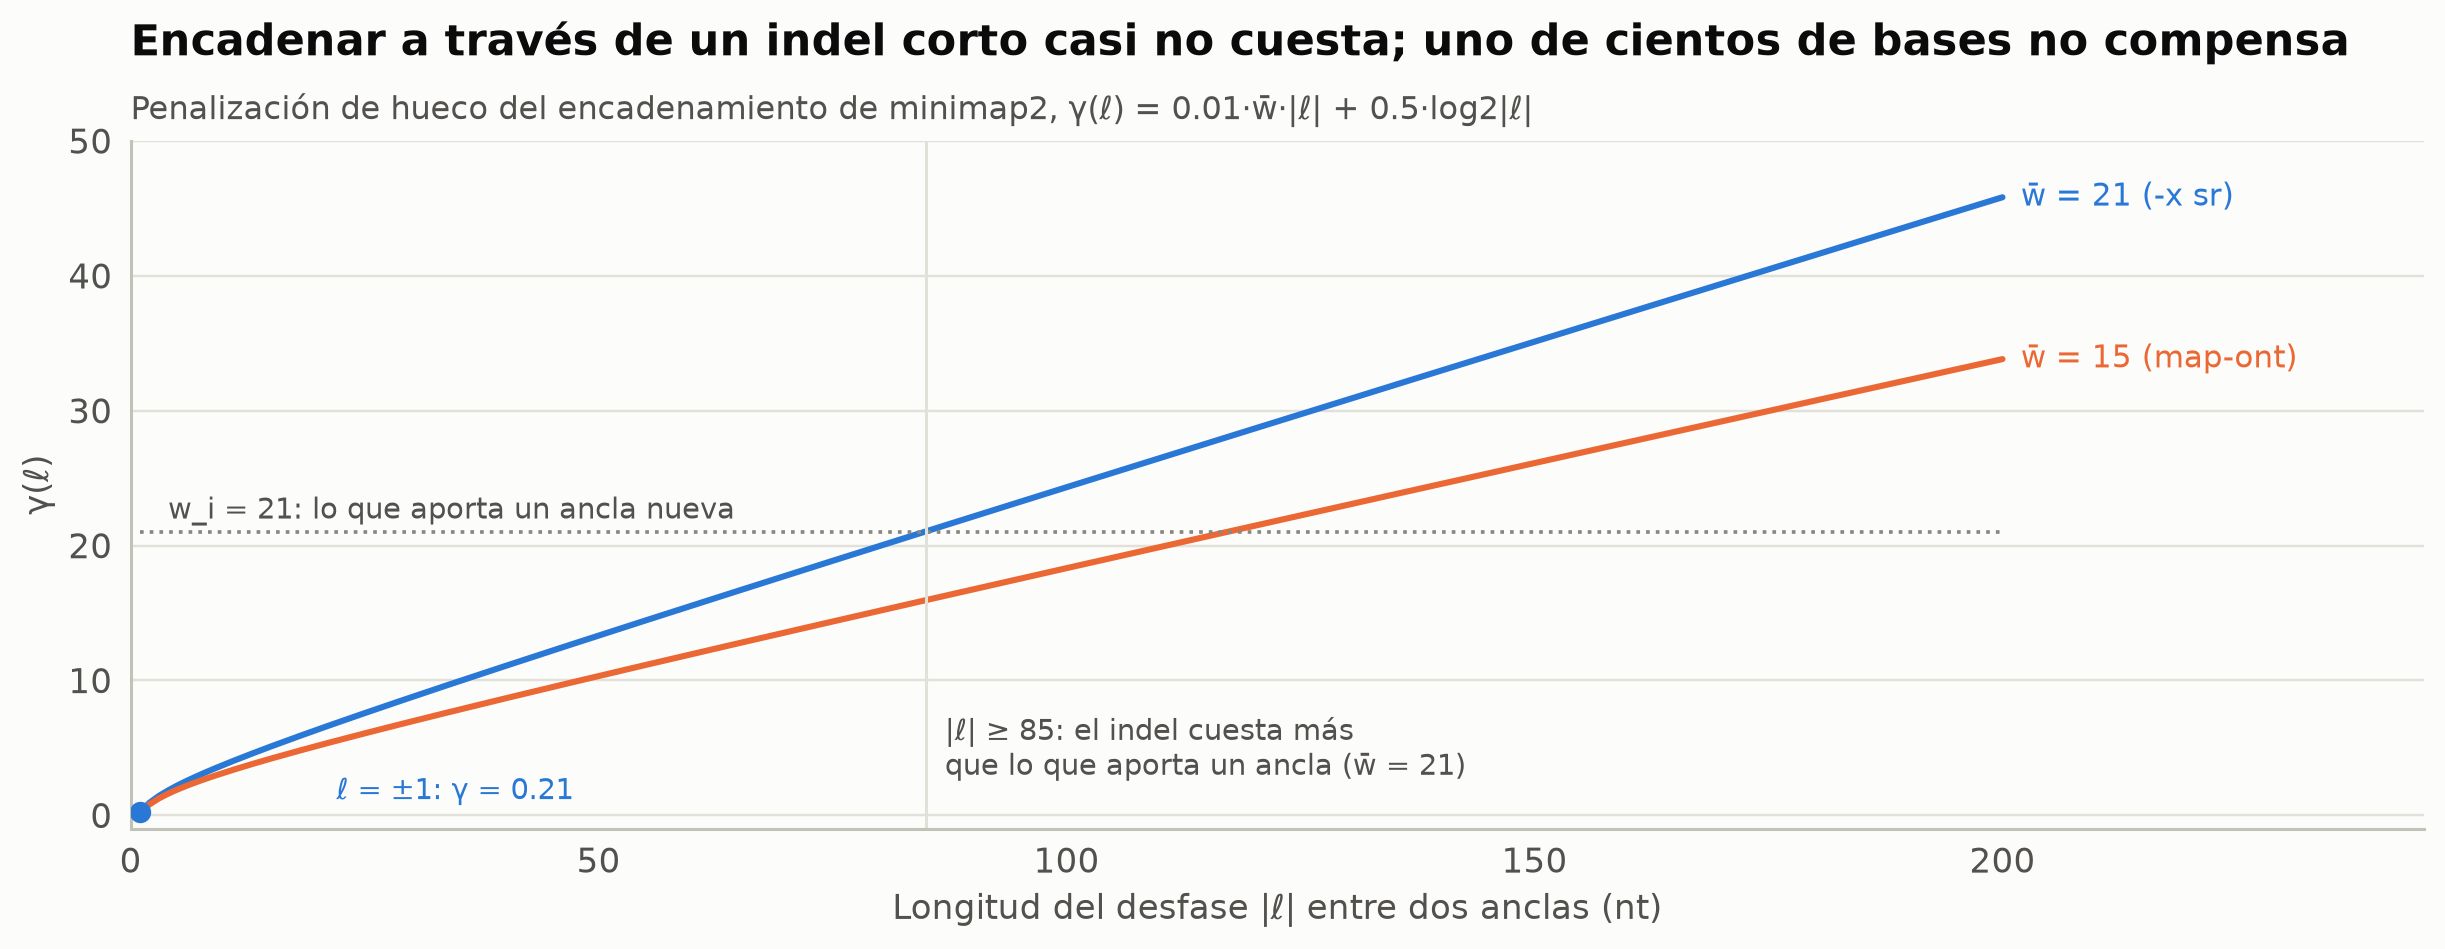

In [22]:
# el ejemplo a mano, con el código (anclas guardadas por su inicio = final − (k − 1))
hand_anchors = np.array([(0, 1020 - 20, 25 - 20), (0, 1050 - 20, 55 - 20), (0, 1082 - 20, 86 - 20)])
f_hand, strand_hand, chain_hand = chain_anchors(hand_anchors, k=21)[0]
print(f"f(A3) = {f_hand:.2f} · anclas en la cadena: {len(chain_hand)} · γ(−1) = {gamma_gap(-1, 21):.2f}")

ells = np.arange(1, 201)
fig, ax = plt.subplots(figsize=(11, 4.2))
for w_bar, col in [(21, ec.BLUE), (15, ec.ORANGE)]:
    g_ = np.array([gamma_gap(l_, w_bar) for l_ in ells])
    ax.plot(ells, g_, color=col, lw=2)
    ec.label_end(ax, ells[-1], g_[-1], f"w̄ = {w_bar}" + (" (-x sr)" if w_bar == 21 else " (map-ont)"), col)
ax.plot(ells, 21 * np.ones_like(ells), color=ec.MUTED, ls=":", lw=1.2)
ax.text(4, 22, "w_i = 21: lo que aporta un ancla nueva", color=ec.INK_2, fontsize=9.5)
ax.scatter([1], [gamma_gap(1, 21)], color=ec.BLUE, zorder=4)
ax.annotate("ℓ = ±1: γ = 0.21", xy=(1, gamma_gap(1, 21)), xytext=(22, 1.2), fontsize=9.5, color=ec.BLUE,
            arrowprops=dict(arrowstyle="->", color=ec.BLUE))
cross = ells[np.argmax([gamma_gap(l_, 21) > 21 for l_ in ells])]
ax.axvline(cross, color=ec.GRID, lw=1)
ax.text(cross + 2, 3, f"|ℓ| ≥ {cross}: el indel cuesta más\nque lo que aporta un ancla (w̄ = 21)", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 245); ax.set_ylim(-1, 50)
ax.set_xlabel("Longitud del desfase |ℓ| entre dos anclas (nt)"); ax.set_ylabel("γ(ℓ)")
ec.title(ax, "Encadenar a través de un indel corto casi no cuesta; uno de cientos de bases no compensa",
         "Penalización de hueco del encadenamiento de minimap2, γ(ℓ) = 0.01·w̄·|ℓ| + 0.5·log2|ℓ|")
plt.show()

> 🔎 **Qué observamos.** El código reproduce el ejemplo a mano ($f = 62.79$). La penalización $\gamma$ crece casi en
> línea recta: un *indel* de 1–10 nt cuesta menos de 4 puntos, muy por debajo de los 21 que aporta cada ancla, así que
> la cadena los atraviesa sin dudar. Hacen falta desfases de unas 85 bases (con $\bar w = 21$) para que $\gamma(\ell)$
> supere lo que aporta un ancla: a partir de ahí sale más a cuenta empezar una cadena nueva (el término $w_i$ de la recurrencia).
> Por eso las anclas de otra copia de una repetición, a miles de bases de distancia, no se mezclan con la cadena
> verdadera.

### Paso 4: elegir la mejor posición y su calidad

Extendemos las mejores cadenas (hasta 8), eliminamos las que caen en la misma posición y nos quedamos con la de mayor
puntuación. Si hay otras candidatas con puntuación parecida, la lectura es **ambigua**. La sección 6 explica cómo
convertir esa ambigüedad en la **calidad de mapeo**; por ahora, la función la calcula con la fórmula que allí
deduciremos.

In [23]:
LAMBDA = np.log(100) / (MATCH + MISMATCH)    # una diferencia (−5 puntos) hace la posición 100 veces menos probable

def mapq_from_scores(scores):
    """MAPQ = −10·log10 P(posición incorrecta), con P(i) ∝ exp(λ·S_i) (sección 6)."""
    S = np.asarray(scores, float)
    p = np.exp(LAMBDA * (S - S.max()))
    p_wrong = 1 - p.max() / p.sum()
    return int(min(60, round(-10 * np.log10(max(p_wrong, 1e-6)))))

def toy_map(read, top=8):
    """Mapea una lectura: semillas → cadenas → extensión en bandas → mejor posición + MAPQ."""
    A = find_anchors(read)
    if len(A) == 0:
        return None
    alns = sorted((extend_chain(read, c) for c in chain_anchors(A)[:top]), key=lambda a: -a["score"])
    uniq = []
    for a in alns:
        if all(abs(a["pos"] - b["pos"]) > 50 for b in uniq):
            uniq.append(a)
    best = uniq[0]
    best.update(mapq=mapq_from_scores([a["score"] for a in uniq]), n_cand=len(uniq),
                sub=uniq[1]["score"] if len(uniq) > 1 else 0, n_anchors=len(A))
    return best

res0 = toy_map(seqs1[0])
print(f"{names1[0]}: posición {res0['pos']:,} hebra {res0['strand']} CIGAR {res0['cigar']} "
      f"puntuación {res0['score']} MAPQ {res0['mapq']} ({res0['n_anchors']} anclas, {res0['n_cand']} candidata/s)")

SRR2584863.1: posición 3,339,155 hebra - CIGAR 150M puntuación 150 MAPQ 60 (22 anclas, 1 candidata/s)


### 🎬 Una lectura mapeándose, paso a paso

Elegimos automáticamente una lectura real de R1 con algunas anclas falsas (semillas que también aparecen en otro sitio
del genoma) y la seguimos por los tres pasos.

In [24]:
# Elegir una lectura que mapea de forma única, entera, y que tiene anclas en más de un lugar del genoma
demo = None
for i_ in range(400):
    A_ = find_anchors(seqs1[i_])
    if len(A_) < 8:
        continue
    r_ = toy_map(seqs1[i_])
    spread = np.ptp(A_[:, 1]) if len(A_) else 0
    if r_ and r_["mapq"] == 60 and r_["cigar"].endswith("M") and "S" not in r_["cigar"] and spread > 100_000:
        demo = i_
        break
demo = 0 if demo is None else demo
demo_read, demo_res = seqs1[demo], toy_map(seqs1[demo])
demo_A = find_anchors(demo_read)
print(f"Lectura {names1[demo]} · {len(demo_A)} anclas · mejor: {demo_res['pos']:,} {demo_res['strand']} "
      f"{demo_res['cigar']} AS={demo_res['score']} MAPQ={demo_res['mapq']}")
print("Anclas (hebra, x, y):", demo_A[np.argsort(demo_A[:, 1])].tolist())

Lectura SRR2584863.35 · 122 anclas · mejor: 23,990 - 150M AS=135 MAPQ=60
Anclas (hebra, x, y): [[1, 24010, 21], [1, 24020, 31], [1, 24026, 37], [1, 24031, 42], [1, 24039, 50], [1, 24040, 51], [1, 24048, 59], [1, 24056, 67], [1, 24061, 72], [1, 24071, 82], [1, 24073, 84], [1, 24076, 87], [1, 24079, 90], [1, 24080, 91], [1, 24084, 95], [1, 24095, 106], [1, 24099, 110], [1, 24102, 113], [1, 24109, 120], [1, 241976, 21], [1, 241986, 31], [1, 241992, 37], [1, 241997, 42], [1, 263511, 21], [1, 263521, 31], [1, 263527, 37], [1, 263532, 42], [0, 353269, 87], [0, 353274, 92], [0, 353280, 98], [0, 353290, 108], [0, 376754, 87], [0, 376759, 92], [0, 376765, 98], [0, 376775, 108], [0, 546937, 87], [0, 546942, 92], [0, 546948, 98], [0, 546958, 108], [0, 589560, 87], [0, 589565, 92], [0, 589571, 98], [0, 589581, 108], [0, 619122, 87], [0, 619127, 92], [0, 619133, 98], [0, 619143, 108], [0, 633983, 87], [0, 633988, 92], [0, 633994, 98], [0, 634004, 108], [1, 1194334, 21], [1, 1194344, 31], [1, 119435

![Una lectura real de 150 nt se mapea en REL606: sus minimizers se buscan en el índice (anclas en todo el genoma), las anclas colineales forman la cadena y la programación dinámica en bandas produce el alineamiento final](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-07-mapeo/7.2_lectura_mapea.gif)

*Una lectura real de 150 nt se mapea en REL606: sus minimizers se buscan en el índice (anclas en todo el genoma), las anclas colineales forman la cadena y la programación dinámica en bandas produce el alineamiento final*

In [25]:
h_best = 1 if demo_res["strand"] == "-" else 0
chain_best = chain_anchors(demo_A)[0][2]
H_demo = demo_res["H"].astype(float)
i0_, j0_, ops_ = demo_res["path"]
path_xy = [(i0_, j0_)]
for op in ops_:
    i_, j_ = path_xy[-1]
    path_xy.append((i_ + (op in "MI"), j_ + (op in "MD")))
path_xy = np.array(path_xy)
q_min = minimizers(demo_read, K, W)[0]
n_seed_f, n_chain_f, n_dp_f, n_end_f = 10, 6, 25, 5
frames_total = n_seed_f + n_chain_f + n_dp_f + n_end_f
Lq = len(demo_read)
rows_per_f = int(np.ceil(Lq / n_dp_f))
H_masked = np.where(H_demo > 0, H_demo, np.nan)

fig = plt.figure(figsize=(13, 7.2))
gs_ = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.5], hspace=0.45, wspace=0.25)
ax_top, ax_ch, ax_dp = fig.add_subplot(gs_[0, :]), fig.add_subplot(gs_[1, 0]), fig.add_subplot(gs_[1, 1])

def update(f):
    for a in (ax_top, ax_ch, ax_dp):
        a.clear()
    # --- arriba: anclas en todo el genoma
    n_show = len(q_min) if f >= n_seed_f else int(np.ceil(len(q_min) * (f + 1) / n_seed_f))
    ys_shown = set(q_min[:n_show].tolist())
    for h, x, y in demo_A:
        y_orig = y if h == 0 else Lq - y - K
        if y_orig in ys_shown:
            on_chain = h == h_best and any((chain_best[:, 1] == x) & (chain_best[:, 2] == y))
            ax_top.scatter(x / 1e6, y, s=40 if on_chain else 30, color=ec.BLUE if on_chain and f >= n_seed_f else ec.ORANGE,
                           zorder=3)
    ax_top.set_xlim(0, G / 1e6); ax_top.set_ylim(-5, Lq + 5)
    ax_top.set_xlabel("Posición en el genoma (Mb)"); ax_top.set_ylabel("Posición\nen la lectura")
    ax_top.set_title(f"1 · Semillas: {n_show} de {len(q_min)} minimizers de la lectura buscados en el índice "
                     f"→ {sum(1 for h, x, y in demo_A if (y if h == 0 else Lq - y - K) in ys_shown)} anclas",
                     fontsize=11.5, loc="left")
    # --- abajo a la izquierda: zoom a la cadena
    if f >= n_seed_f:
        k_show = len(chain_best) if f >= n_seed_f + n_chain_f else int(np.ceil(len(chain_best) * (f - n_seed_f + 1) / n_chain_f))
        cb = chain_best[:k_show]
        ax_ch.scatter(chain_best[:, 1] - demo_res["d"], chain_best[:, 2], s=30, color=ec.MUTED)
        ax_ch.plot(cb[:, 1] - demo_res["d"], cb[:, 2], "-o", color=ec.BLUE, ms=6)
        ax_ch.plot([0, Lq], [0, Lq], color=ec.INK_2, ls=":", lw=1)
        ax_ch.set_xlim(-10, Lq + 10); ax_ch.set_ylim(-10, Lq + 10)
        ax_ch.set_title(f"2 · Cadena: {k_show} anclas colineales (hebra {demo_res['strand']})", fontsize=11.5, loc="left")
    else:
        ax_ch.text(0.5, 0.5, "encadenamiento…", ha="center", va="center", color=ec.MUTED, transform=ax_ch.transAxes)
        ax_ch.set_title("2 · Cadena", fontsize=11.5, loc="left")
    ax_ch.set_xlabel(f"x − {demo_res['d']:,} (genoma, relativo)"); ax_ch.set_ylabel("y (lectura orientada)")
    # --- abajo a la derecha: DP con bandas
    ax_dp.set_title("3 · Extensión: Smith–Waterman en bandas", fontsize=11.5, loc="left")
    if f >= n_seed_f + n_chain_f:
        fd = f - n_seed_f - n_chain_f
        rows = min(Lq, (fd + 1) * rows_per_f)
        M = H_masked.copy(); M[rows + 1:, :] = np.nan
        ax_dp.imshow(M, cmap=ec.CMAP_SEQ, aspect="auto", origin="upper", vmin=0, vmax=np.nanmax(H_demo))
        if fd >= n_dp_f:
            ax_dp.plot(path_xy[:, 1], path_xy[:, 0], color=ec.ORANGE, lw=2.5)
            ax_dp.text(2, Lq * 0.92, f"CIGAR {demo_res['cigar']}\nAS = {demo_res['score']} · MAPQ {demo_res['mapq']}\n"
                                      f"posición {demo_res['pos']:,}", fontsize=10.5, color=ec.INK,
                       bbox=dict(facecolor=ec.SURFACE, edgecolor=ec.GRID))
        else:
            ax_dp.text(2, Lq * 0.92, f"fila {rows} de {Lq}", fontsize=10.5, color=ec.INK_2)
    ax_dp.set_xlabel("Ventana del genoma (columna j)"); ax_dp.set_ylabel("Lectura (fila i)")
    ax_dp.grid(False)
    return []

ec.animate(fig, update, frames=frames_total, interval=220, name="7.2_lectura_mapea")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los minimizers de la lectura producen anclas en varios lugares del genoma (puntos naranjas
> dispersos en el panel 1), pero sólo en uno forman una **columna vertical**: muchas semillas de distintas posiciones
> de la lectura que caen en el mismo sitio. Esa columna es la cadena (panel 2), cuyas anclas siguen la diagonal. La
> DP (panel 3) sólo llena una franja estrecha de la matriz y el camino óptimo recorre la diagonal de punta a punta: la
> lectura alinea completa, `150M`.

### Mapeamos 1 000 lecturas con nuestro mapeador

Ahora mapeamos las primeras 1 000 lecturas de R1 y guardamos los resultados; en la sección 9 los compararemos, lectura
por lectura, con BWA-MEM.

In [26]:
N_TOY = 1000
t0 = time.time()
toy = []
for name, s in zip(names1[:N_TOY], seqs1[:N_TOY]):
    r_ = toy_map(s)
    toy.append(dict(qname=name, toy_pos=r_["pos"] if r_ else np.nan, toy_strand=r_["strand"] if r_ else "",
                    toy_cigar=r_["cigar"] if r_ else "", toy_score=r_["score"] if r_ else np.nan,
                    toy_mapq=r_["mapq"] if r_ else np.nan, toy_ncand=r_["n_cand"] if r_ else 0))
toy = pd.DataFrame(toy)
t_toy = time.time() - t0
print(f"{N_TOY} lecturas en {t_toy:.1f} s ({N_TOY / t_toy:,.0f} lecturas/s) · sin anclas: {toy.toy_pos.isna().sum()}")
print("MAPQ del mapeador de juguete:", toy.toy_mapq.value_counts(bins=[-1, 0, 3, 19, 59, 60]).sort_index().to_dict())
toy.head()

1000 lecturas en 2.6 s (383 lecturas/s) · sin anclas: 0
MAPQ del mapeador de juguete: {Interval(-1.001, 0.0, closed='right'): 0, Interval(0.0, 3.0, closed='right'): 24, Interval(3.0, 19.0, closed='right'): 1, Interval(19.0, 59.0, closed='right'): 8, Interval(59.0, 60.0, closed='right'): 967}


,qname,toy_pos,toy_strand,toy_cigar,toy_score,toy_mapq,toy_ncand
0,SRR2584863.1,3339155,-,150M,150,60,1
1,SRR2584863.2,4336553,-,150M,150,60,1
2,SRR2584863.3,2067177,+,150M,150,60,1
3,SRR2584863.4,3281262,-,150M,150,60,1
4,SRR2584863.5,1231976,+,150M,150,60,1


## 6. La calidad de mapeo (MAPQ) y las lecturas multimapeadas

### Intuición

Un mapeador siempre elige **una** posición, pero no siempre está seguro. Si la lectura alinea perfectamente en un
lugar y en ningún otro, la confianza es altísima. Si alinea igual de bien en dos lugares (dos copias de una
repetición), sólo puede elegir al azar: acertará la mitad de las veces. La **calidad de mapeo** (MAPQ, quinta columna
del SAM) resume esa confianza con la misma escala Phred que las calidades de base de la Lección 2.1. La introdujeron
Li, Ruan y Durbin (2008) en el mapeador MAQ.

**Ejemplo a mano (el del libro).** Una lectura coincide con la posición $u_1$ salvo por una base de calidad $Q = 35$, y
con $u_2$ salvo por dos bases de calidades 25 y 30. Si la lectura viene de $u$, cada discordancia exige un error de
secuenciación, con probabilidad $\varepsilon = 10^{-Q/10}$; aproximamos $p(q\mid u)$ por el producto de esas
probabilidades:

$$
p(q\mid u_1) = 10^{-3.5} = 3.16\times10^{-4},\qquad p(q\mid u_2) = 10^{-2.5}\cdot10^{-3} = 3.16\times10^{-6}.
$$

La probabilidad de haber elegido mal es $3.16\times10^{-6}/(3.16\times10^{-4} + 3.16\times10^{-6}) = 0.0099$, y la
MAPQ es $-10\log_{10}0.0099 = 20.0$. Una sola base discordante de diferencia, pero de buena calidad, basta para preferir
$u_1$ con un 99 % de confianza. Si $u_1$ y $u_2$ fueran **idénticas**, la probabilidad de error sería $0.5$ y la MAPQ
$-10\log_{10}0.5 = 3.01$; con tres copias idénticas, $1.76$. En general, suponiendo un origen *a priori* uniforme:

$$
\Pr(\hat u\mid q) \;=\; \frac{p(q\mid \hat u)}{\sum_{k=1}^{K} p(q\mid u_k)},\qquad
\operatorname{MAPQ} \;=\; -10\log_{10}\big(1-\Pr(\hat u\mid q)\big)
$$

| Símbolo | Significado |
|---|---|
| $u_1,\dots,u_K$ | posiciones candidatas de la lectura $q$ (cada una con su hebra) |
| $p(q\mid u)$ | verosimilitud de la lectura dada la posición; con sólo sustituciones, aproximadamente el producto de las probabilidades de error $\varepsilon_i = 10^{-Q_i/10}$ de las bases discordantes |
| $\hat u$ | la mejor candidata, la que se informa en `POS` |
| $\Pr(\hat u\mid q)$ | probabilidad *a posteriori* de que $\hat u$ sea el origen verdadero |
| $\operatorname{MAPQ}$ | calidad de mapeo en escala Phred: 20 significa 1 % de probabilidad de posición errónea; 30, 0.1 % |

| MAPQ | $1-\Pr(\hat u\mid q)$ | Lectura típica |
|---|---|---|
| 60 | $\le 10^{-6}$ | única, sin alternativa razonable (BWA-MEM y minimap2 truncan en 60) |
| 30 | $10^{-3}$ | alternativa con varias diferencias más |
| 20 | $10^{-2}$ | alternativa con una diferencia más (el ejemplo a mano) |
| 3 | $0.5$ | dos posiciones idénticas: $-10\log_{10}0.5 = 3.01$ |
| 0 | convención | la mejor y la segunda puntuación **empatan** (`AS` = `XS`): el mapeador escribe 0 aunque la fórmula daría 3.01 (dos copias) o 1.76 (tres) |

### De las puntuaciones a la probabilidad: la misma idea con `AS`

Los mapeadores no guardan las calidades de cada discordancia de cada candidata; tienen a mano las **puntuaciones** de
alineamiento. Supongamos que la lectura tiene dos posiciones candidatas con puntuaciones $S_1$ y $S_2$. Cada diferencia
resta 5 puntos respecto de una coincidencia (+1 → −4). Si cada discordancia equivale a una base de calidad $Q = 20$
(1 % de error), observar una diferencia más en un sitio que en otro hace a ese sitio unas **100 veces** menos probable,
exactamente como en el ejemplo anterior. Un modelo que cumple eso es la definición de arriba con
$p(q\mid u_i) \propto e^{\lambda S_i}$:

$$
P(i \mid \text{lectura}) \;=\; \frac{e^{\lambda S_i}}{\sum_j e^{\lambda S_j}},\qquad \lambda = \frac{\ln 100}{5} \approx 0.92
$$

| Símbolo | Significado |
|---|---|
| $S_i$ | puntuación del alineamiento en la candidata $i$ (la etiqueta `AS` en el SAM) |
| $\lambda$ | cuánto más probable es una posición por cada punto de puntuación |
| $P(i \mid \text{lectura})$ | probabilidad de que la lectura venga de la candidata $i$ |

* **Una diferencia de distancia:** $S_1 = 150$, $S_2 = 145$. $P(1) = 1/(1 + e^{-0.92 \cdot 5}) = 1/(1 + 0.01) = 0.990$.
  $P(\text{incorrecta}) = 0.0099$ → MAPQ $= -10\log_{10}0.0099 \approx 20$.
* **Dos copias idénticas:** $S_1 = S_2$ → $P(1) = 0.5$ → MAPQ $= -10\log_{10}0.5 \approx 3$.
* **Siete copias idénticas (un operón *rrn*):** $P(\text{incorrecta}) = 6/7$ → MAPQ $\approx 0.7$, que se redondea a 1.
  BWA-MEM informa **0** en cuanto la segunda mejor puntuación iguala a la primera (etiqueta `XS` = `AS`).

BWA-MEM y minimap2 usan fórmulas aproximadas propias (que también consideran la longitud de las semillas y cuántas
candidatas se descartaron), pero la lógica es esta: **cuanto menor sea la distancia entre la mejor y la segunda mejor
puntuación, menor la MAPQ**.

Ejemplo del libro, con verosimilitudes a partir de las calidades:
  u1 (una discordancia Q35) frente a u2 (Q25 y Q30): MAPQ = 20.0
  dos copias idénticas: 3.01 · tres: 1.76
Modelo con puntuaciones AS (λ = ln 100 / 5), redondeado y truncado en 60:
  Puntuaciones [150, 145]                       → MAPQ 20
  Puntuaciones [150, 140]                       → MAPQ 40
  Puntuaciones [150, 150]                       → MAPQ 3
  Puntuaciones [150, 150, 150, 150, 150, 150, 150] → MAPQ 1
  Puntuaciones [150]                            → MAPQ 60


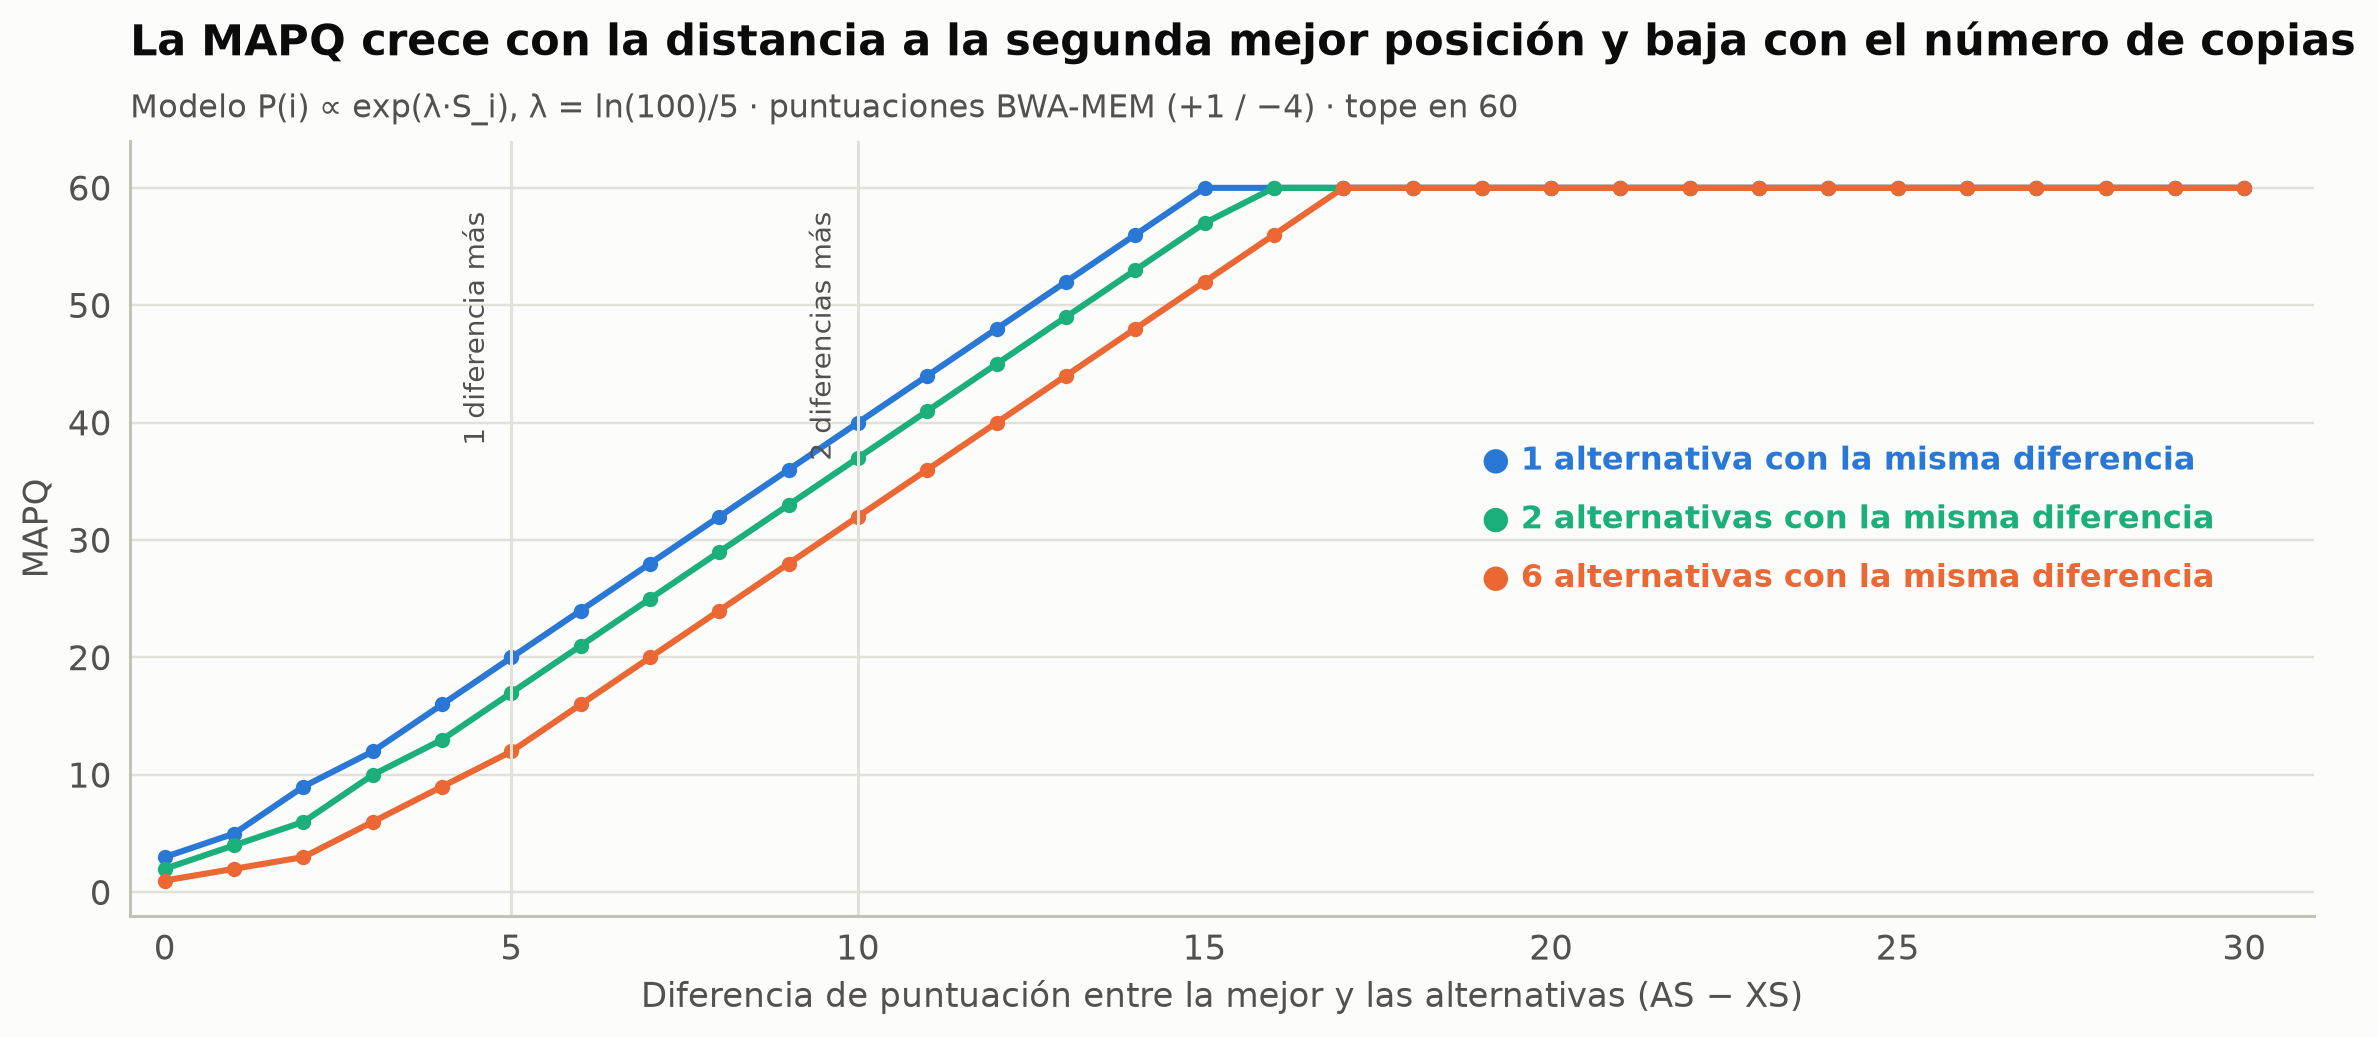

In [27]:
def mapq_posterior(likelihoods):
    """MAPQ = −10·log10(1 − P(û|q)) con P(û|q) = p(q|û) / Σ p(q|u_k) (origen a priori uniforme)."""
    p = np.asarray(likelihoods, float)
    return -10 * np.log10(1 - p.max() / p.sum())

eps = lambda Q: 10 ** (-Q / 10)
print("Ejemplo del libro, con verosimilitudes a partir de las calidades:")
print(f"  u1 (una discordancia Q35) frente a u2 (Q25 y Q30): MAPQ = {mapq_posterior([eps(35), eps(25) * eps(30)]):.1f}")
print(f"  dos copias idénticas: {mapq_posterior([eps(35)] * 2):.2f} · tres: {mapq_posterior([eps(35)] * 3):.2f}")
print("Modelo con puntuaciones AS (λ = ln 100 / 5), redondeado y truncado en 60:")
for scores in ([150, 145], [150, 140], [150, 150], [150] * 7, [150]):
    print(f"  Puntuaciones {str(scores):32s} → MAPQ {mapq_from_scores(scores)}")

fig, ax = plt.subplots(figsize=(10.5, 4.6))
delta = np.arange(0, 31)
for n_copies, col in [(2, ec.BLUE), (3, ec.AQUA), (7, ec.ORANGE)]:
    mq = [mapq_from_scores([150] + [150 - d] * (n_copies - 1)) for d in delta]
    ax.plot(delta, mq, "-o", color=col, ms=4)
    ax.text(19, 36 - 5 * [2, 3, 7].index(n_copies),
            f"● {n_copies - 1} alternativa{'s' if n_copies > 2 else ''} con la misma diferencia", color=col,
            fontsize=10.5, fontweight="bold")
for d_ in (5, 10):
    ax.axvline(d_, color=ec.GRID, lw=1)
    ax.text(d_ - 0.3, 58, f"{d_ // 5} diferencia{'s' if d_ > 5 else ''} más", fontsize=9, color=ec.INK_2, rotation=90, ha="right", va="top")
ax.set_xlabel("Diferencia de puntuación entre la mejor y las alternativas (AS − XS)")
ax.set_ylabel("MAPQ")
ax.set_xlim(-0.5, 31); ax.set_ylim(-2, 64)
ec.title(ax, "La MAPQ crece con la distancia a la segunda mejor posición y baja con el número de copias",
         "Modelo P(i) ∝ exp(λ·S_i), λ = ln(100)/5 · puntuaciones BWA-MEM (+1 / −4) · tope en 60")
plt.show()

> 🔎 **Qué observamos.** El código reproduce las cifras del ejemplo a mano (20.0, 3.01 y 1.76). Con una sola
> alternativa idéntica (AS − XS = 0) la MAPQ del modelo es 3; con seis alternativas, casi 0 (y BWA-MEM y minimap2
> escriben directamente 0 por convención en cuanto hay empate).
> Cada diferencia adicional (5 puntos) suma unos 20 puntos de MAPQ, así que con tres diferencias de distancia ya se
> alcanza el tope de 60. Observe que la MAPQ **no** mide lo bien que alinea la lectura: una lectura perfecta (`150M`,
> sin diferencias) en un operón *rrn* tiene MAPQ 0, y una lectura con tres errores en una región única tiene MAPQ 60.
> Alineamiento bueno y posición segura son cosas distintas.

> 🤔 **Antes de ejecutar, prediga.** En nuestras 1 000 lecturas mapeadas con el mapeador de juguete, ¿qué fracción de
> las que caen dentro de un operón *rrn* tendrá MAPQ baja (< 10)?

In [28]:
toy["in_rrn"] = in_intervals(toy.toy_pos.fillna(0).astype(int).values, operons.start, operons.end)
toy["in_IS"] = in_intervals(toy.toy_pos.fillna(0).astype(int).values, is_elems.start, is_elems.end)
toy["region"] = np.where(toy.in_rrn, "operón rrn", np.where(toy.in_IS, "elemento IS", "resto del genoma"))
summary_toy = toy.groupby("region").agg(lecturas=("qname", "size"),
                                        mapq_baja=("toy_mapq", lambda m: np.mean(m < 10)),
                                        candidatas_medias=("toy_ncand", "mean"))
summary_toy

,lecturas,mapq_baja,candidatas_medias
region,,,
elemento IS,11,0.454545,5.272727
operón rrn,11,1.000000,7.000000
resto del genoma,978,0.008180,1.135992


> 🔎 **Qué observamos.** En el resto del genoma casi ninguna lectura tiene MAPQ baja. Dentro de los operones *rrn*, todas
> la tienen, y el mapeador encuentra en promedio siete candidatas por lectura: una por operón. En los elementos IS,
> cerca de la mitad: hay familias con una sola copia en el genoma (sólo las de IS1 e IS3 están muy repetidas). Son pocas
> lecturas, porque las repeticiones ocupan apenas ≈ 2 % del genoma, pero son lecturas **multimapeadas**: el mapeador
> las coloca en una de las copias (al azar entre las empatadas) y avisa con la MAPQ. Por
> eso casi todos los análisis posteriores (llamado de variantes, cobertura) filtran por MAPQ: `samtools view -q 20`.

### La fórmula empírica de minimap2

En la práctica, los programas no enumeran todas las candidatas: estiman el denominador de $\Pr(\hat u\mid q)$ a partir
de las dos mejores y de cuántas subóptimas encontraron. BWA comprobó por simulación que sus valores son razonables: de
1 569 108 lecturas simuladas con MAPQ 60, sólo 11 estaban mal colocadas (Li y Durbin, 2009). minimap2, en cambio, usa
una fórmula **empírica** que mira sólo el encadenamiento de la sección 5, y la intuición es directa: la confianza sube
si la cadena primaria es **mucho mejor** que la segunda, si tiene **suficientes anclas** y si es **larga**.

**Ejemplo a mano (el del libro).** Cadena primaria con $f_1 = 200$ y $a = 40$ anclas ($\ln 200 = 5.30$):

* sin secundaria ($f_2 = 0$): $40\cdot1\cdot1\cdot5.30 = 211.9$ → se trunca en **60**;
* secundaria con $f_2 = 150$: $40\,(1 - 0.75)\cdot1\cdot5.30 = 53.0$ → **53**;
* secundaria casi empatada, $f_2 = 195$: $40\,(1 - 0.975)\cdot5.30 = 5.3$ → **5**.

$$
\operatorname{MAPQ} \;=\; 40\left(1-\frac{f_2}{f_1}\right)\min\left\{1,\frac{a}{10}\right\}\ln f_1,
\qquad \text{truncada en 60}
$$

| Símbolo | Significado |
|---|---|
| $f_1$ | puntuación de encadenamiento $f(i)$ de la cadena **primaria** (sección 5, Paso 2) |
| $f_2$ | puntuación de la mejor cadena **secundaria** (la mejor alternativa en otro lugar) |
| $a$ | número de anclas de la cadena primaria (aquí $a$ **no** es la puntuación de coincidencia que aparecerá en $S_{ij}$) |
| $\min\{1, a/10\}$ | castiga las cadenas con menos de 10 anclas: poca evidencia |
| $\ln f_1$ | las cadenas largas son más fiables que las cortas |

Las versiones actuales de minimap2, cuando calculan el alineamiento de bases (`-a`, `-c`), refinan esta cifra con las
puntuaciones de la programación dinámica; la fórmula del artículo (Li, 2018) es la idea de base.

In [29]:
def mapq_minimap2(f1, f2, a):
    """MAPQ empírica de minimap2 (Li, 2018), sin truncar y truncada en 60."""
    raw = 40 * (1 - f2 / f1) * min(1, a / 10) * np.log(f1)
    return raw, int(round(min(60, max(0, raw))))

for f2 in (0, 150, 195):
    raw, mq = mapq_minimap2(200, f2, 40)
    print(f"f1 = 200, f2 = {f2:>3}, a = 40 → {raw:6.1f} → MAPQ {mq}")

# ¿y nuestras cadenas? f1 y f2 de la lectura de la animación y de una lectura de un operón rrn
def chain_mapq(read):
    ch = chain_anchors(find_anchors(read))
    f1, a = ch[0][0], len(ch[0][2])
    f2 = next((c[0] for c in ch[1:] if abs(np.median(c[2][:, 1]) - np.median(ch[0][2][:, 1])) > 50), 0.0)
    return f1, f2, a, mapq_minimap2(f1, f2, a)[1]
rrn_read = genome[operons.start[0] + 1000:operons.start[0] + 1150]
for lab, rd in [("lectura de la animación", demo_read), ("150 nt del 16S de rrn-1", rrn_read)]:
    f1, f2, a, mq = chain_mapq(rd)
    print(f"{lab:26s}: f1 = {f1:6.1f}, f2 = {f2:6.1f}, a = {a:2d} anclas → MAPQ {mq}")

f1 = 200, f2 =   0, a = 40 →  211.9 → MAPQ 60
f1 = 200, f2 = 150, a = 40 →   53.0 → MAPQ 53
f1 = 200, f2 = 195, a = 40 →    5.3 → MAPQ 5
lectura de la animación   : f1 =  120.0, f2 =   42.0, a = 19 anclas → MAPQ 60
150 nt del 16S de rrn-1   : f1 =  143.0, f2 =  143.0, a = 22 anclas → MAPQ 0


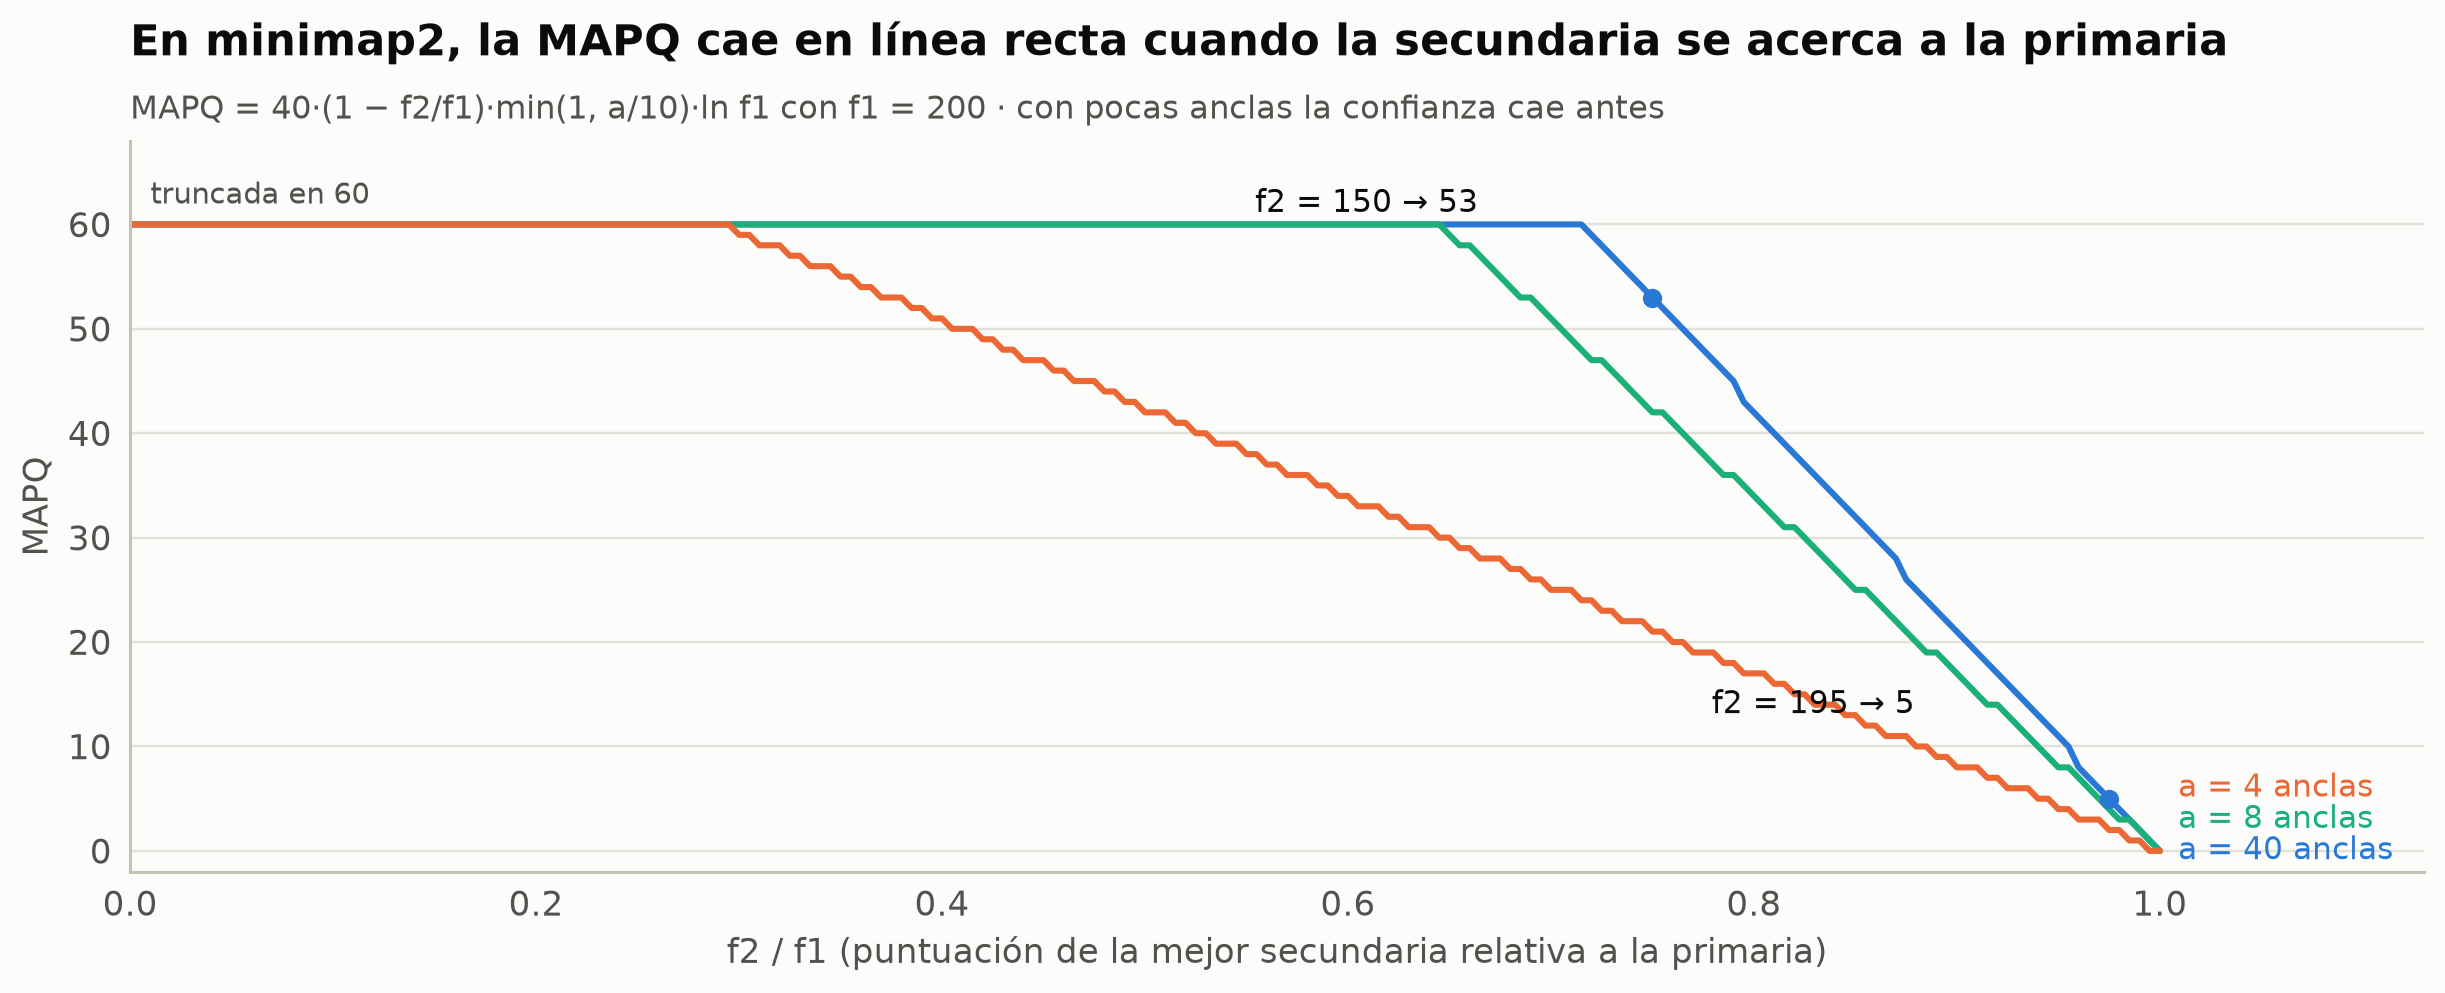

In [30]:
ratio = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(11, 4.4))
for a_, col in [(40, ec.BLUE), (8, ec.AQUA), (4, ec.ORANGE)]:
    mq_ = [mapq_minimap2(200, r_ * 200, a_)[1] for r_ in ratio]
    ax.plot(ratio, mq_, color=col, lw=2)
    ec.label_end(ax, 1.0, mq_[-1] + [0, 3, 6][[40, 8, 4].index(a_)], f"a = {a_} anclas", col)
for f2_, lab_ in [(150, "f2 = 150 → 53"), (195, "f2 = 195 → 5")]:
    r_, mq_ = f2_ / 200, mapq_minimap2(200, f2_, 40)[1]
    ax.scatter([r_], [mq_], color=ec.BLUE, zorder=4, s=40)
    ax.annotate(lab_, xy=(r_, mq_), xytext=(-130, 28), textcoords="offset points", fontsize=10, color=ec.INK,
                arrowprops=dict(arrowstyle="->", color=ec.INK_2))
ax.text(0.01, 62, "truncada en 60", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 1.13); ax.set_ylim(-2, 68)
ax.set_xlabel("f2 / f1 (puntuación de la mejor secundaria relativa a la primaria)"); ax.set_ylabel("MAPQ")
ec.title(ax, "En minimap2, la MAPQ cae en línea recta cuando la secundaria se acerca a la primaria",
         "MAPQ = 40·(1 − f2/f1)·min(1, a/10)·ln f1 con f1 = 200 · con pocas anclas la confianza cae antes")
plt.show()

> 🔎 **Qué observamos.** Con 40 anclas y $f_1 = 200$, la fórmula da más de 60 hasta que la secundaria alcanza
> $f_2/f_1 \approx 0.72$; a partir de ahí cae en línea recta hasta 0 en el empate, pasando por los 53 y 5 del ejemplo.
> Una cadena con sólo 4 anclas (una lectura corta con muchos errores) cae mucho antes: deja el tope en cuanto
> $f_2/f_1$ supera ≈ 0.29, porque el factor $\min\{1, a/10\} = 0.4$ desconfía de la poca evidencia. Aplicada a nuestras cadenas, la lectura de la animación, única en el
> genoma, no tiene secundaria y llega al tope; la del 16S tiene una secundaria idéntica en otro operón
> ($f_2 = f_1$) y recibe 0. Es la misma conclusión que con la definición bayesiana, por otro camino.

> ⚠️ **Lo que la MAPQ no es.** (1) **No** es una calidad del alineamiento: una lectura sin una sola discordancia puede
> tener MAPQ 0 porque encaja igual de bien en dos copias. (2) **No** es comparable entre programas: BWA, Bowtie 2 y
> minimap2 la calculan y truncan de maneras distintas, y un filtro "MAPQ ≥ 20" significa cosas diferentes en cada
> caso. (3) **Depende de la referencia**: si falta la copia verdadera de una repetición, las lecturas se mapean con
> confianza al lugar equivocado (sección 8.3).

## 7. 🧪 El flujo real en Colab: BWA-MEM, samtools y minimap2

Pasemos a las herramientas profesionales. El SAM que sale del mapeador está en el **orden de las lecturas del
FASTQ**. Para analizarlo hacen falta varios pasos, y **el orden importa**:

1. `samtools fixmate -m` rellena, con los dos extremos de cada par a la vista, la información sobre la pareja (etiqueta
   `MC`, la CIGAR de la compañera; `ms`, la suma de sus calidades) que necesitará el marcado de duplicados. Requiere los
   pares **contiguos**, como los entrega BWA-MEM: por eso va **antes** de ordenar.
2. `samtools sort` ordena por coordenada.
3. `samtools markdup` marca con el bit `0x400` los **duplicados**: pares cuyos extremos 5′ coinciden en posición y
   orientación, que probablemente son copias por PCR de un mismo fragmento original o duplicados ópticos del
   secuenciador (recuerde la complejidad de la biblioteca de la Lección 6.2). Va **después** de ordenar.
   `samblaster` (Faust y Hall, 2014) hace lo mismo en flujo, sin ordenar.
4. `samtools index` crea el índice `.bai` para el acceso aleatorio.

```bash
bwa index -p REL606 REL606.fa                          # indexar la referencia (una sola vez)
bwa mem -t 2 -R '@RG\tID:SRR2584863\tSM:REL7179B\tPL:ILLUMINA' REL606 lecturas_1.fastq.gz lecturas_2.fastq.gz \
  | samtools fixmate -m - - \
  | samtools sort -@ 2 -o aln.ordenado.bam -
samtools markdup -@ 2 aln.ordenado.bam aln.bam          # duplicados → FLAG 0x400
samtools index aln.bam                                  # índice .bai (acceso aleatorio)
samtools flagstat aln.bam                               # resumen de las FLAG
samtools view -c -F 0x904 -q 20 aln.bam                 # primarias mapeadas con MAPQ ≥ 20
samtools stats aln.bam > aln.stats                      # estadísticas completas
samtools idxstats aln.bam                               # lecturas por cromosoma
samtools depth -a -r NC_012967.1:226000-232500 aln.bam  # profundidad base a base
samtools view -C -T REL606.fa -o aln.cram aln.bam       # CRAM: sólo las diferencias con la referencia
minimap2 -ax sr -t 2 REL606.fa lecturas_1.fastq.gz lecturas_2.fastq.gz | samtools sort -o mm2.bam
```

| Opción | Significado |
|---|---|
| `-t 2`, `-@ 2` | usar 2 hilos (Colab gratuito tiene 2 núcleos) |
| `-R '@RG…'` | *read group*: identifica la corrida (`ID`), la muestra (`SM`) y la plataforma (`PL`); los llamadores de variantes lo exigen |
| `fixmate -m` | completa la información de la pareja y añade la etiqueta `ms` que usa `markdup` |
| `samtools sort` | ordena por cromosoma y posición: requisito para `markdup`, para indexar y para casi todos los análisis |
| `-F 0x904` | excluye no mapeadas (`0x4`), secundarias (`0x100`) y suplementarias (`0x800`): un registro primario por lectura mapeada |
| `-ax sr` | minimap2: salida SAM (`-a`) con el ajuste para lecturas cortas (`-x sr`: $k = 21$, $w = 11$) |

En la celda separamos el mapeo de la tubería para cronometrar cada paso por su cuenta; el resultado es el mismo.

La celda siguiente instala `bwa`, `minimap2` y `samtools` con `apt-get` **sólo en Colab**. Fuera de Colab usa los que
encuentre en el `PATH` (por ejemplo, instalados con `conda install -c bioconda bwa minimap2 samtools`). Si no hay
mapeadores, carga los resultados precalculados que acompañan al curso (BWA 0.7.19, minimap2 2.31, samtools 1.24), y los
comandos de samtools se ejecutan a través de **pysam**, que incluye samtools dentro de la biblioteca.

In [31]:
def which_tools():
    return {t: shutil.which(t) for t in ("bwa", "minimap2", "samtools")}

tools = which_tools()
if IN_COLAB and not all(tools.values()):
    !apt-get -qq update > /dev/null
    !apt-get -qq install -y bwa minimap2 samtools > /dev/null
    tools = which_tools()
HAS_MAPPERS = bool(tools["bwa"] and tools["minimap2"])
for t, p in tools.items():
    print(f"{t:9s}: {p or '— no disponible'}")
if not HAS_MAPPERS:
    print("\n⚠️ Sin bwa/minimap2: usaré los resultados precalculados del curso (misma orden, mismos datos).")

def sh(cmd, log=None):
    """Ejecuta una orden de la terminal, muestra la orden y el tiempo, y devuelve su salida estándar."""
    print("$", cmd)
    t0 = time.time()
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if log:
        open(log, "w").write(p.stderr)
    if p.returncode != 0:
        raise RuntimeError(p.stderr[-800:])
    return p.stdout, time.time() - t0

def samtools(*args):
    """samtools por la terminal si está instalado; si no, la misma orden a través de pysam."""
    if tools["samtools"]:
        return sh("samtools " + " ".join(args))[0]
    print("$ samtools", " ".join(args), "   (vía pysam)")
    if args[0] == "view" and "-o" in args:                  # pysam: dejar que samtools escriba el archivo de -o
        return getattr(pysam, args[0])(*args[1:], catch_stdout=False)
    return getattr(pysam, args[0])(*args[1:])

bwa      : bwa
minimap2 : minimap2
samtools : samtools


In [32]:
BAM = "SRR2584863_bwa.bam"
course_log = json.loads(course_bytes("SRR2584863_30k_REL606_mapping_log.json"))
timing = {}
if HAS_MAPPERS:
    rg = r"'@RG\tID:SRR2584863\tSM:REL7179B\tPL:ILLUMINA'"
    _, timing["bwa index"] = sh("bwa index -p REL606 REL606.fa")
    _, timing["bwa mem"] = sh(f"bwa mem -t 2 -R {rg} REL606 {FQ1} {FQ2} > SRR2584863_bwa.sam", log="bwa.log")
    raw_sam = "SRR2584863_bwa.sam"                      # pares contiguos, en el orden del FASTQ
    bwa_log = open("bwa.log").read().splitlines()
    pestat = [l for l in bwa_log if "mem_pestat" in l]
    print(f"\nbwa index: {timing['bwa index']:.1f} s · bwa mem: {timing['bwa mem']:.1f} s")
else:
    course_bam = course_file("SRR2584863_30k_REL606_bwa.bam")
    timing = {"bwa index": course_log["seconds"]["bwa index"], "bwa mem": course_log["seconds"]["bwa mem"]}
    pestat = course_log["bwa_mem_pestat"]
    print("BAM precalculado del curso:", course_bam, "·", course_log["note"])
    print("(En la copia del curso se quitaron las calidades de base, QUAL = '*', para ahorrar espacio.)")
    raw_sam = "SRR2584863_bwa_byname.bam"               # la copia está ordenada por coordenada: la agrupamos por nombre
    samtools("sort", "-n", "-o", raw_sam, course_bam)
t0 = time.time()
samtools("fixmate", "-m", raw_sam, "SRR2584863_fixmate.bam")
samtools("sort", "-o", "SRR2584863_sorted.bam", "SRR2584863_fixmate.bam")
samtools("markdup", "-f", "markdup_stats.txt", "SRR2584863_sorted.bam", BAM)
samtools("index", BAM)
timing["fixmate + sort + markdup + index"] = time.time() - t0
print(f"fixmate → sort → markdup → index: {timing['fixmate + sort + markdup + index']:.1f} s")
print("\nLo que BWA-MEM aprendió de los pares (registro 'mem_pestat'):")
print("\n".join(l.replace("[M::mem_pestat] ", "  ") for l in pestat[:11]))

$ bwa index -p REL606 REL606.fa


$ bwa mem -t 2 -R '@RG\tID:SRR2584863\tSM:REL7179B\tPL:ILLUMINA' REL606 ../data/SRR2584863_30k_1.fastq.gz ../data/SRR2584863_30k_2.fastq.gz > SRR2584863_bwa.sam



bwa index: 0.8 s · bwa mem: 1.2 s
$ samtools fixmate -m SRR2584863_bwa.sam SRR2584863_fixmate.bam


$ samtools sort -o SRR2584863_sorted.bam SRR2584863_fixmate.bam


$ samtools markdup -f markdup_stats.txt SRR2584863_sorted.bam SRR2584863_bwa.bam


$ samtools index SRR2584863_bwa.bam
fixmate → sort → markdup → index: 1.1 s

Lo que BWA-MEM aprendió de los pares (registro 'mem_pestat'):
  # candidate unique pairs for (FF, FR, RF, RR): (122, 27681, 8, 112)
  analyzing insert size distribution for orientation FF...
  (25, 50, 75) percentile: (428, 830, 2208)
  low and high boundaries for computing mean and std.dev: (1, 5768)
  mean and std.dev: (1181.13, 1195.73)
  low and high boundaries for proper pairs: (1, 7548)
  analyzing insert size distribution for orientation FR...
  (25, 50, 75) percentile: (268, 547, 746)
  low and high boundaries for computing mean and std.dev: (1, 1702)
  mean and std.dev: (524.65, 288.66)
  low and high boundaries for proper pairs: (1, 2180)


Antes de mapear, BWA-MEM **aprende** de los propios datos cómo son los pares: cuenta cuántos pares únicos tienen cada
orientación (FF, **FR**, RF, RR), y para la orientación dominante calcula los cuartiles del tamaño de inserto y los
límites de un par "propio" (*proper pair*). Luego usa esa distribución para dos cosas: marcar la FLAG `0x2` y
**rescatar** al compañero de una lectura bien mapeada buscándolo con Smith–Waterman cerca de donde debería estar.

Miremos el encabezado y las primeras líneas del BAM con pysam. Recuerde de la Lección 2.1 las 11 columnas obligatorias
(QNAME, FLAG, RNAME, POS, MAPQ, CIGAR, RNEXT, PNEXT, TLEN, SEQ, QUAL) y las etiquetas opcionales.

In [33]:
bam = pysam.AlignmentFile(BAM)
hdr = bam.header.to_dict()
print("@SQ:", hdr["SQ"])
print("@RG:", hdr.get("RG"))
print("@PG:", [(p["ID"], p.get("VN"), p.get("CL", "")[:60]) for p in hdr.get("PG", [])])
print()
for i_, r_ in enumerate(bam.fetch(until_eof=True)):
    if i_ >= 4:
        break
    tags = " ".join(f"{t}:{v}" for t, v in r_.get_tags() if t in ("NM", "MD", "AS", "XS", "SA"))
    print(f"{r_.query_name:18s} FLAG={r_.flag:<5d} POS={r_.reference_start + 1:<8d} MAPQ={r_.mapping_quality:<3d} "
          f"CIGAR={r_.cigarstring:<10s} TLEN={r_.template_length:<9d} {tags}")

@SQ: [{'SN': 'NC_012967.1', 'LN': 4629812}]
@RG: [{'ID': 'SRR2584863', 'SM': 'REL7179B', 'PL': 'ILLUMINA'}]
@PG: [('bwa', '0.7.19-r1273', 'bwa mem -t 2 -R @RG\\tID:SRR2584863\\tSM:REL7179B\\tPL:ILLUMINA'), ('samtools', '1.24', 'samtools fixmate -m SRR2584863_bwa.sam SRR2584863_fixmate.ba'), ('samtools.1', '1.24', 'samtools sort -o SRR2584863_sorted.bam SRR2584863_fixmate.ba'), ('samtools.2', '1.24', 'samtools markdup -f markdup_stats.txt SRR2584863_sorted.bam ')]

SRR2584863.17047   FLAG=2195  POS=1        MAPQ=60  CIGAR=80H70M     TLEN=4629007   NM:0 MD:70 AS:70 XS:0 SA:NC_012967.1,4629733,-,80M70S,60,0;
SRR2584863.2162    FLAG=2193  POS=123      MAPQ=60  CIGAR=70M80H     TLEN=4629106   NM:0 MD:70 AS:70 XS:0 SA:NC_012967.1,2283,+,89M61S,60,1;
SRR2584863.4402    FLAG=99    POS=177      MAPQ=60  CIGAR=60M90S     TLEN=60        NM:0 MD:60 AS:60 XS:0
SRR2584863.29217   FLAG=99    POS=177      MAPQ=60  CIGAR=150M       TLEN=745       NM:0 MD:150 AS:150 XS:0


Tres etiquetas nuevas, que BWA-MEM añade a cada lectura, nos van a ser muy útiles:

| Etiqueta | Significado | Uso en esta lección |
|---|---|---|
| `NM:i` | distancia de edición con la referencia (diferencias + bases insertadas + borradas) | tasa de error |
| `MD:Z` | cadena que describe **qué** base de la referencia hay en cada diferencia (`MD:Z:60A89` = 60 coincidencias, una diferencia donde la referencia tiene A, 89 coincidencias) | errores por ciclo |
| `AS:i` / `XS:i` | puntuación del mejor alineamiento y de la **segunda mejor** posición | explicar la MAPQ |
| `SA:Z` | alineamiento **suplementario**: otra parte de la lectura alinea en otro sitio (lectura quimérica) | cruce del origen |

Las primeras líneas del BAM ordenado ya traen una sorpresa: lecturas en la posición 1 con `TLEN` de más de 4.6
millones y una etiqueta `SA`. El cromosoma es **circular**, pero el FASTA lo representa como una línea que empieza en
una posición arbitraria. Un par cuyo fragmento **cruza el origen** tiene un extremo al final del FASTA y otro al
principio; y una lectura que cruza el origen se parte en dos alineamientos (el primario y un suplementario, con recorte
duro `H`). No es un error de los datos: es la topología del genoma.

### ¿Qué hicieron `fixmate` y `markdup`?

Un **duplicado** es la misma molécula original leída dos veces: la PCR de la biblioteca hizo varias copias del mismo
fragmento, o la cámara del secuenciador vio el mismo racimo dos veces (duplicado **óptico**). Contarlas dos veces
inflaría la evidencia: si el fragmento llevaba un error de PCR, parecería una variante apoyada por dos lecturas
independientes. ¿Cómo reconocerlos sin saber nada de la química? Dos pares independientes casi nunca empiezan **en
el mismo sitio en ambos extremos**, con la misma orientación. `markdup` agrupa los pares por (posición 5′ de R1,
posición 5′ de R2, hebras), se queda con el de mayor suma de calidades (la etiqueta `ms` que puso `fixmate`) y marca los
demás con `0x400`. No los borra: sólo los señala.

**Ejemplo a mano.** Con $N$ pares repartidos al azar sobre $G$ posiciones de inicio posibles y un inserto casi fijo,
¿cuántas coincidencias exactas esperamos **por azar**? Cada par nuevo "choca" con uno anterior con probabilidad de
orden $N/G$ (ambos extremos quedan determinados por el inicio). Para nuestros $N = 30\,000$ pares y $G = 4.6\times10^6$:
$N^2/(2G) = 9\times10^{8}/9.3\times10^{6} \approx 97$ pares, un 0.3 %, y en la práctica menos, porque los insertos de
Nextera varían mucho y el segundo extremo casi nunca coincide. Si `markdup` marca **muchos más**, son copias técnicas.

$$
\mathbb{E}[\text{pares duplicados por azar}] \;\approx\; \frac{N^{2}}{2\,G}
$$

| Símbolo | Significado |
|---|---|
| $N$ | número de pares mapeados |
| $G$ | número de posiciones de inicio posibles (longitud del genoma) |

In [34]:
md_stats = {}
for line in open("markdup_stats.txt"):
    if ":" in line and not line.startswith("COMMAND"):
        k_, v_ = line.split(":", 1)
        md_stats[k_.strip()] = v_.strip()
for k_ in ("READ", "PAIRED", "DUPLICATE PAIR", "DUPLICATE PAIR OPTICAL", "DUPLICATE SINGLE", "DUPLICATE TOTAL",
           "ESTIMATED_LIBRARY_SIZE"):
    print(f"{k_:24s} {md_stats.get(k_, '—')}")
n_pairs_ = len(seqs1)
print(f"\nEsperado por azar (tope, inserto fijo): N²/(2G) = {n_pairs_ ** 2 / (2 * G):.0f} pares")

def five_prime(r):
    """Extremo 5′ sin recortar de una lectura alineada: el criterio de samtools markdup."""
    ct = r.cigartuples
    if r.is_reverse:
        return r.reference_end + (ct[-1][1] if ct[-1][0] == 4 else 0), "−"
    return r.reference_start - (ct[0][1] if ct[0][0] == 4 else 0), "+"

ends_, recs_ = {}, {}
with pysam.AlignmentFile(BAM) as fh:
    for r in fh.fetch(until_eof=True):
        if r.is_unmapped or r.is_secondary or r.is_supplementary or r.mate_is_unmapped:
            continue
        ends_.setdefault(r.query_name, {})["R1" if r.is_read1 else "R2"] = five_prime(r)
        if r.is_read1:
            recs_[r.query_name] = r
groups_ = {}
for qn, e in ends_.items():
    if len(e) == 2:
        groups_.setdefault(tuple(sorted([e["R1"], e["R2"]])), []).append(qn)
dup_group = next((g for g in groups_.values() if len(g) > 1 and any(recs_[q].is_duplicate for q in g)), [])
print("\nUn grupo de duplicados (los dos extremos 5′ coinciden en posición y hebra):" if dup_group else "\nNo hay pares duplicados.")
for qn in dup_group:
    r = recs_[qn]
    print(f"  {r.query_name:18s} FLAG={r.flag:<5d} POS={r.reference_start + 1:,} CIGAR={r.cigarstring:<9s} "
          f"PNEXT={r.next_reference_start + 1:,} MC={r.get_tag('MC') if r.has_tag('MC') else '—':<9s} "
          f"ms={r.get_tag('ms') if r.has_tag('ms') else '—'} {'← marcado 0x400' if r.is_duplicate else '← se conserva'}")

READ                     60414
PAIRED                   59212
DUPLICATE PAIR           16
DUPLICATE PAIR OPTICAL   0
DUPLICATE SINGLE         18
DUPLICATE TOTAL          34
ESTIMATED_LIBRARY_SIZE   54772333

Esperado por azar (tope, inserto fijo): N²/(2G) = 97 pares



Un grupo de duplicados (los dos extremos 5′ coinciden en posición y hebra):
  SRR2584863.14007   FLAG=83    POS=1,535,363 CIGAR=150M      PNEXT=1,534,821 MC=150M      ms=3443 ← se conserva
  SRR2584863.14008   FLAG=1107  POS=1,535,367 CIGAR=4S146M    PNEXT=1,534,821 MC=150M      ms=2584 ← marcado 0x400


> 🔎 **Qué observamos.** `markdup` marca apenas unas decenas de registros (16 pares y 18 lecturas sueltas cuya
> compañera no mapeó, ≈ 0.06 %), por debajo incluso del tope de ≈ 100 pares que daría el azar: no hay rastro de exceso
> de PCR ni de duplicados ópticos. Tiene sentido: estas 30 000 parejas son una **submuestra** aleatoria de una corrida
> mucho más profunda, y al submuestrear casi todas las copias de cada molécula se quedan fuera (en la corrida completa
> la fracción sería mayor). En el ejemplo, dos pares tienen sus dos extremos 5′ en la misma base y la misma hebra: uno
> se conserva (el de mayor `ms`) y el otro lleva `0x400`. Fíjese en que `POS` puede diferir si una de las lecturas tiene
> recorte suave: `markdup` compara el extremo 5′ **sin recortar**. Observe las etiquetas `MC` y `ms` que añadió `fixmate`: sin ellas, `markdup` no podría decidir. Una
> advertencia práctica: en amplicones o en RNA-seq los "duplicados" son la norma biológica o técnica, no un artefacto, y
> marcarlos sin pensarlo borra la señal.

### El filtro `-F 0x904`: un registro primario por lectura mapeada

Un BAM no tiene "una línea por lectura": una lectura no mapeada también tiene su registro, una lectura quimérica tiene
un registro **primario** y otro **suplementario**, y algunos mapeadores escriben alineamientos **secundarios**. Para
contar lecturas mapeadas sin contar dos veces hay que quedarse con los registros primarios mapeados. La FLAG es una
suma de bits (Lección 2.1), así que basta con una operación **Y** bit a bit:

**Ejemplo a mano.** $\texttt{0x904} = 2048 + 256 + 4 = 2308$ (suplementario + secundario + no mapeado).

| FLAG | Descomposición | FLAG ∧ 2308 | ¿Pasa `-F 0x904`? | ¿Pasa `-F 0xD04`? |
|---|---|---|---|---|
| 99 | 1 + 2 + 32 + 64: par propio, R1, compañera en hebra − | 0 | sí | sí |
| 2147 | 2048 + 99: la misma lectura, trozo suplementario | 2048 | **no** | no |
| 1123 | 1024 + 99: duplicado | 0 | sí | **no** |
| 77 | 1 + 4 + 8 + 64: R1 no mapeada, compañera tampoco | 4 | **no** | no |

$$
\text{se conserva el registro} \iff \texttt{FLAG} \wedge \texttt{0x904} = 0
$$

| Símbolo | Significado |
|---|---|
| $\wedge$ | Y bit a bit (`&` en Python, `-F` en samtools: excluir si **algún** bit de la máscara está encendido) |
| `0x904` | máscara: `0x4` no mapeada + `0x100` secundaria + `0x800` suplementaria |
| `0xD04` | la misma máscara más `0x400` (duplicado) |

FLAG    99: FLAG & 0x904 =    0 → pasa · FLAG & 0xD04 =    0 → pasa
FLAG  2147: FLAG & 0x904 = 2048 → fuera · FLAG & 0xD04 = 2048 → fuera
FLAG  1123: FLAG & 0x904 =    0 → pasa · FLAG & 0xD04 = 1024 → fuera
FLAG    77: FLAG & 0x904 =    4 → fuera · FLAG & 0xD04 =    4 → fuera
$ samtools view -c SRR2584863_bwa.bam


$ samtools view -c -F 0x900 SRR2584863_bwa.bam
$ samtools view -c -F 0x904 SRR2584863_bwa.bam
$ samtools view -c -F 0xD04 SRR2584863_bwa.bam


$ samtools view -c -F 0xD04 -q 20 SRR2584863_bwa.bam


                        filtro  registros
           todos los registros      60414
          -F 0x900 (primarios)      60000
 -F 0x904 (primarios mapeados)      59602
 -F 0xD04 (… y sin duplicados)      59568
-F 0xD04 -q 20 (… y MAPQ ≥ 20)      58349


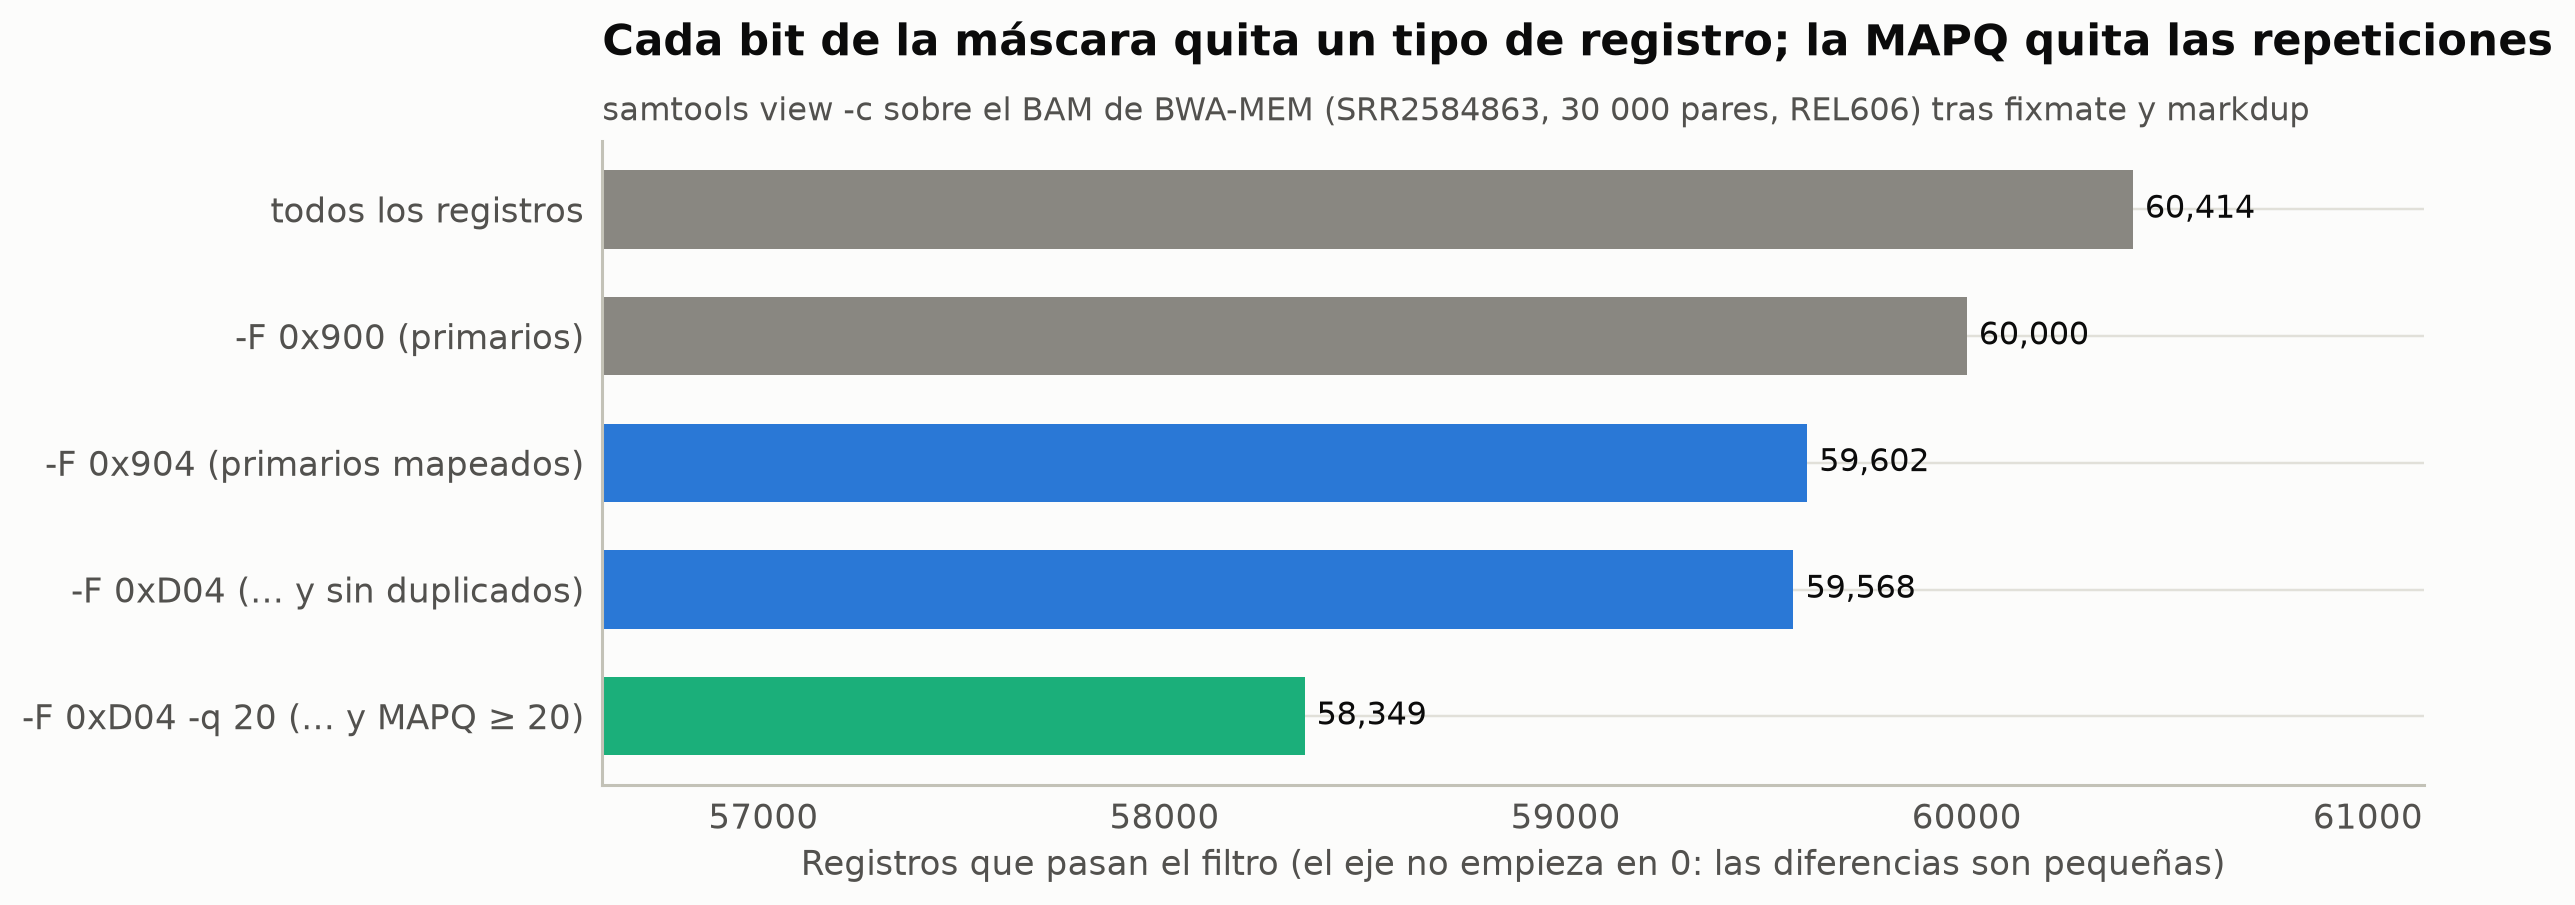

In [35]:
for f_ in (99, 2147, 1123, 77):
    print(f"FLAG {f_:>5}: FLAG & 0x904 = {f_ & 0x904:>4} → {'pasa' if f_ & 0x904 == 0 else 'fuera'} · "
          f"FLAG & 0xD04 = {f_ & 0xD04:>4} → {'pasa' if f_ & 0xD04 == 0 else 'fuera'}")
filters = [("todos los registros", []), ("-F 0x900 (primarios)", ["-F", "0x900"]),
           ("-F 0x904 (primarios mapeados)", ["-F", "0x904"]),
           ("-F 0xD04 (… y sin duplicados)", ["-F", "0xD04"]),
           ("-F 0xD04 -q 20 (… y MAPQ ≥ 20)", ["-F", "0xD04", "-q", "20"])]
funnel = pd.DataFrame([(lab, int(str(samtools("view", "-c", *args, BAM)).strip())) for lab, args in filters],
                      columns=["filtro", "registros"])
print(funnel.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
y_ = np.arange(len(funnel))[::-1]
ax.barh(y_, funnel.registros, color=[ec.MUTED, ec.MUTED, ec.BLUE, ec.BLUE, ec.AQUA], height=0.62)
for yi, (lab, n_) in zip(y_, funnel.itertuples(index=False)):
    ax.text(n_ + 30, yi, f"{n_:,}", va="center", fontsize=10.5)
ax.set_yticks(y_, funnel.filtro)
lo_ = funnel.registros.min() * 0.97
ax.set_xlim(lo_, funnel.registros.max() * 1.012)
ax.set_xlabel("Registros que pasan el filtro (el eje no empieza en 0: las diferencias son pequeñas)")
ec.title(ax, "Cada bit de la máscara quita un tipo de registro; la MAPQ quita las repeticiones",
         "samtools view -c sobre el BAM de BWA-MEM (SRR2584863, 30 000 pares, REL606) tras fixmate y markdup")
plt.show()

> 🔎 **Qué observamos.** Hay algo más registros que lecturas: los suplementarios de las lecturas que cruzan el origen.
> `-F 0x900` los quita y deja exactamente un registro por lectura del FASTQ (60 000). `-F 0x904` quita además las no
> mapeadas: es la cifra de lecturas mapeadas. Quitar los duplicados (`0x400`) apenas cambia nada en esta submuestra, y el
> filtro de MAPQ ≥ 20 elimina las lecturas multimapeadas de los operones *rrn* y de los elementos IS. Esta es la
> "tubería de filtros" que casi cualquier análisis posterior (cobertura, llamado de variantes) aplica, explícita o
> implícitamente.

### CRAM: guardar sólo las diferencias con la referencia

Si las lecturas son casi idénticas a la referencia, ¿para qué guardar las 150 bases de cada una? Basta con apuntar
"empieza en la posición 1 000 000, coincide en todo salvo una **A** en la base 60". Eso hace **CRAM**: guarda sólo las
diferencias respecto de la referencia (que por eso **debe** estar disponible para leerlo), y comprime aparte nombres,
FLAG, calidades y etiquetas. BAM, en cambio, guarda la secuencia completa comprimida en bloques BGZF.

**Ejemplo a mano.** Con una tasa de diferencias $\varepsilon \approx 0.006$ (la medida por `samtools stats` más abajo),
una lectura de $m = 150$ bases tiene en promedio $m\,\varepsilon = 0.9$ diferencias: CRAM guarda menos de una base por
lectura en lugar de 150. Las **calidades** no se benefician de la referencia, así que pasan a dominar el tamaño.

$$
\mathbb{E}[\text{bases que CRAM debe guardar por lectura}] \;=\; m\,\varepsilon \;\ll\; m
$$

| Símbolo | Significado |
|---|---|
| $m$ | longitud de la lectura (150) |
| $\varepsilon$ | fracción de bases alineadas distintas de la referencia (errores + mutaciones reales) |

$ samtools view -C -T REL606.fa -o SRR2584863_bwa.cram SRR2584863_bwa.bam


$ samtools view -c -T REL606.fa SRR2584863_bwa.cram
{'SAM (texto)': '26.21 MB', 'BAM': '7.90 MB', 'CRAM': '3.42 MB'} · registros en el CRAM: 60,414 (BAM: 60,414)


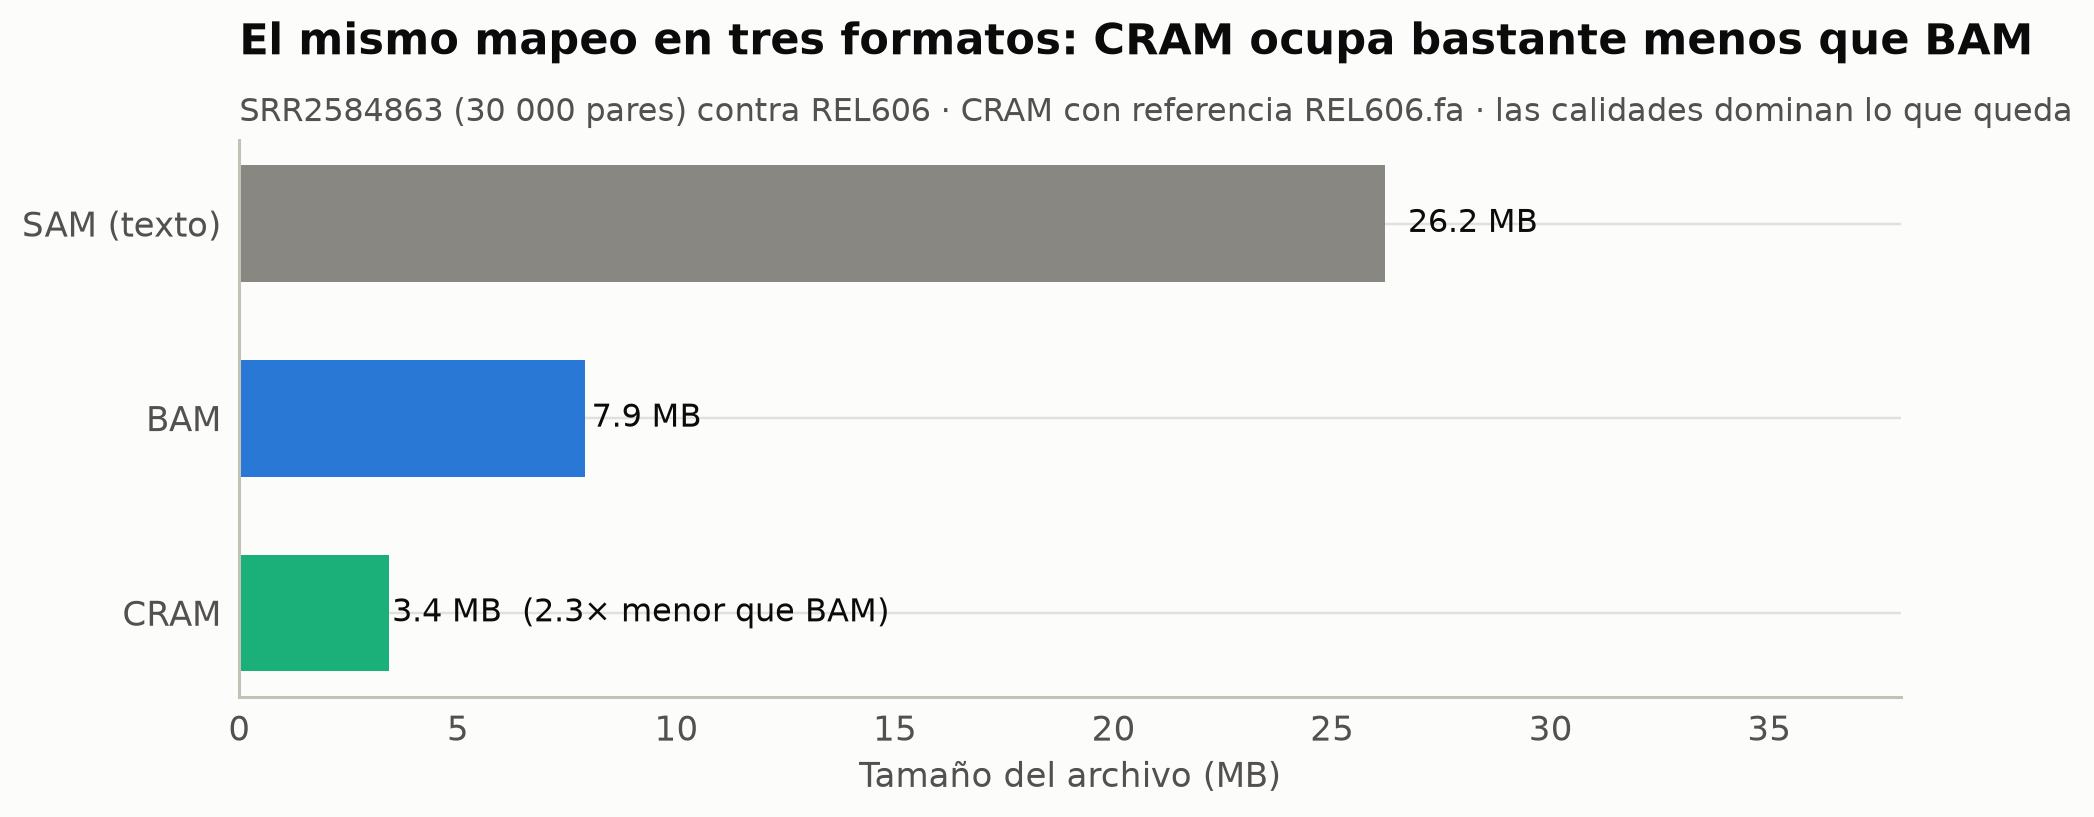

In [36]:
samtools("view", "-C", "-T", "REL606.fa", "-o", "SRR2584863_bwa.cram", BAM)
sizes = {"BAM": os.path.getsize(BAM) / 1e6, "CRAM": os.path.getsize("SRR2584863_bwa.cram") / 1e6}
if os.path.exists("SRR2584863_bwa.sam"):
    sizes = {"SAM (texto)": os.path.getsize("SRR2584863_bwa.sam") / 1e6, **sizes}
n_cram = int(str(samtools("view", "-c", "-T", "REL606.fa", "SRR2584863_bwa.cram")).strip())
print({k: f"{v:.2f} MB" for k, v in sizes.items()}, f"· registros en el CRAM: {n_cram:,} (BAM: {funnel.registros[0]:,})")
if not HAS_MAPPERS:
    print("Nota: la copia del curso no tiene calidades (QUAL = '*'), así que BAM y CRAM salen más pequeños de lo normal.")

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ks, vs = list(sizes), list(sizes.values())
ax.barh(range(len(ks))[::-1], vs, color=[ec.MUTED] * (len(ks) - 2) + [ec.BLUE, ec.AQUA], height=0.6)
for yi, v_ in zip(range(len(ks))[::-1], vs):
    ax.text(v_ * 1.02, yi, f"{v_:.1f} MB" + (f"  ({vs[-2] / v_:.1f}× menor que BAM)" if v_ == vs[-1] else ""),
            va="center", fontsize=10.5)
ax.set_yticks(range(len(ks))[::-1], ks); ax.set_xlim(0, max(vs) * 1.45)
ax.set_xlabel("Tamaño del archivo (MB)")
ec.title(ax, "El mismo mapeo en tres formatos: CRAM ocupa bastante menos que BAM",
         "SRR2584863 (30 000 pares) contra REL606 · CRAM con referencia REL606.fa · las calidades dominan lo que queda")
plt.show()

> 🔎 **Qué observamos.** El SAM de texto es el más voluminoso; BAM lo reduce varias veces, y CRAM lo reduce aún más con
> exactamente los mismos registros. El precio es la dependencia: un CRAM sin **la misma versión exacta** del FASTA de
> referencia no se puede leer. Por eso los grandes proyectos (el de 1000 Genomas, los biobancos) archivan en CRAM y
> guardan la referencia junto a los datos.

### `samtools flagstat`: el primer control de cualquier BAM

In [37]:
flagstat_txt = samtools("flagstat", BAM)
print(flagstat_txt)

$ samtools flagstat SRR2584863_bwa.bam
60414 + 0 in total (QC-passed reads + QC-failed reads)
60000 + 0 primary
0 + 0 secondary
414 + 0 supplementary
34 + 0 duplicates
34 + 0 primary duplicates
60016 + 0 mapped (99.34% : N/A)
59602 + 0 primary mapped (99.34% : N/A)
60000 + 0 paired in sequencing
30000 + 0 read1
30000 + 0 read2
58164 + 0 properly paired (96.94% : N/A)
59212 + 0 with itself and mate mapped
390 + 0 singletons (0.65% : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)



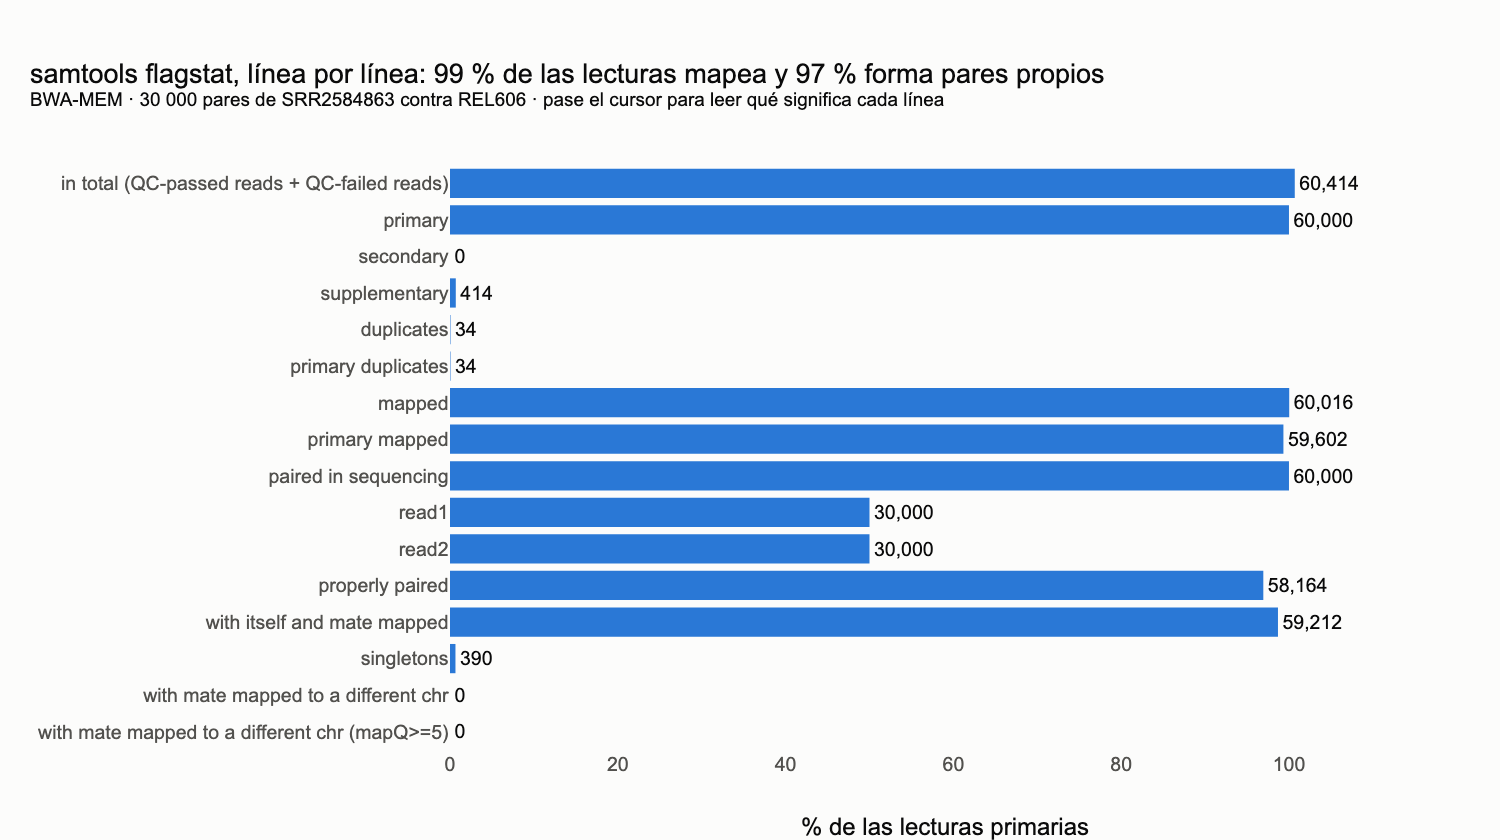

In [38]:
FLAGSTAT_HELP = {
    "in total": "Todos los registros del BAM: primarios + secundarios + suplementarios",
    "primary": "Un registro por lectura del FASTQ: debe coincidir con el número de lecturas de entrada",
    "secondary": "Posiciones alternativas (FLAG 0x100); BWA-MEM no las escribe por defecto",
    "supplementary": "Partes de una lectura quimérica alineadas en otro sitio (FLAG 0x800); aquí, sobre todo, lecturas que cruzan el origen",
    "duplicates": "Marcadas como duplicado de PCR u óptico (FLAG 0x400) por samtools markdup",
    "primary duplicates": "Duplicados entre los registros primarios",
    "mapped": "Registros alineados (incluye suplementarios)",
    "primary mapped": "Lecturas alineadas: la cifra que se informa como 'tasa de mapeo'",
    "paired in sequencing": "Lecturas que vienen de un par (FLAG 0x1)",
    "read1": "Primera lectura del par (FLAG 0x40)",
    "read2": "Segunda lectura del par (FLAG 0x80)",
    "properly paired": "Ambas mapean con la orientación y la distancia esperadas (FLAG 0x2)",
    "with itself and mate mapped": "Lectura mapeada y su compañera también",
    "singletons": "Lectura mapeada pero su compañera no",
    "with mate mapped to a different chr": "Compañera en otro cromosoma (aquí sólo hay uno)",
    "with mate mapped to a different chr (mapQ>=5)": "Lo mismo, con MAPQ ≥ 5: posibles reordenamientos",
}

def parse_flagstat(txt):
    rows = []
    for line in txt.strip().splitlines():
        m = re.match(r"(\d+) \+ (\d+) (.+?)(?: \(([\d.]+%.*|N/A.*)\))?$", line)
        if m:
            label = m.group(3).strip()
            rows.append(dict(label=label, n=int(m.group(1)), help=FLAGSTAT_HELP.get(label, "")))
    return pd.DataFrame(rows)

fs = parse_flagstat(flagstat_txt)
fs["pct"] = 100 * fs.n / fs.loc[fs.label == "primary", "n"].iloc[0]
fs_plot = fs[fs.label != "in total"].iloc[::-1]
fig = go.Figure(go.Bar(
    x=fs_plot.pct, y=fs_plot.label, orientation="h", marker_color=ec.BLUE,
    text=[f"{n:,}" for n in fs_plot.n], textposition="outside",
    customdata=np.column_stack([fs_plot.n, fs_plot.help]),
    hovertemplate="<b>%{y}</b><br>%{customdata[0]:,} registros (%{x:.2f} % de las lecturas)<br>%{customdata[1]}<extra></extra>"))
fig.update_layout(
    title=dict(text="samtools flagstat, línea por línea: 99 % de las lecturas mapea y 97 % forma pares propios"
                    "<br><sup>BWA-MEM · 30 000 pares de SRR2584863 contra REL606 · pase el cursor para leer qué significa cada línea</sup>"),
    xaxis=dict(title="% de las lecturas primarias", range=[0, 118]), height=560,
    margin=dict(t=110, l=300, r=40, b=60))
fig.show()

> 🔎 **Qué observamos.** Un buen mapeo contra la referencia correcta del mismo organismo tiene más de 95 % de lecturas
> mapeadas y más de 90 % en pares propios; aquí estamos por encima de ambas cifras. Los *singletons* (lecturas cuyo
> compañero no mapeó) suelen ser pares en los que una de las dos lecturas es casi toda adaptador o de muy baja calidad:
> los problemas que vimos en la Lección 6.2. Si mapeáramos contra *E. coli* K-12 en lugar de B REL606, la fracción
> mapeada bajaría y aparecerían regiones enteras sin cobertura: las diferencias entre cepas.

### `samtools stats`, `idxstats` y `depth`

`samtools stats` produce un informe mucho más largo (el que resume MultiQC). Sus líneas `SN` son el resumen numérico;
otras secciones (`IS` tamaño de inserto, `COV` cobertura, `MPC` diferencias por ciclo…) tienen tablas completas.

In [39]:
stats_txt = samtools("stats", BAM)
SN = {}
for line in stats_txt.splitlines():
    if line.startswith("SN\t"):
        _, key, val = line.split("\t")[:3]
        SN[key.rstrip(":")] = float(val)
for key in ["raw total sequences", "reads mapped", "reads properly paired", "reads MQ0", "supplementary alignments",
            "bases mapped (cigar)", "mismatches", "error rate", "insert size average", "insert size standard deviation",
            "inward oriented pairs", "outward oriented pairs", "pairs with other orientation"]:
    print(f"{key:32s} {SN[key]:>14,.5g}")
print("\nidxstats (cromosoma, longitud, lecturas mapeadas, no mapeadas):")
print(samtools("idxstats", BAM))

$ samtools stats SRR2584863_bwa.bam
raw total sequences                      60,000
reads mapped                             59,602
reads properly paired                    58,164
reads MQ0                                 1,171
supplementary alignments                    414
bases mapped (cigar)                 8.4108e+06
mismatches                               52,815
error rate                            0.0062794
insert size average                       536.7
insert size standard deviation            335.8
inward oriented pairs                    28,215
outward oriented pairs                    1,041
pairs with other orientation                350

idxstats (cromosoma, longitud, lecturas mapeadas, no mapeadas):
$ samtools idxstats SRR2584863_bwa.bam
NC_012967.1	4629812	60016	390
*	0	0	8



Observe la tasa de error (`error rate` = diferencias según `NM` / bases alineadas ≈ 0.6 %) y el tamaño de inserto medio
de ≈ 540 pb con una desviación estándar enorme: la biblioteca Nextera produce insertos de tamaños muy variables. Lo
examinaremos con detalle en la sección 8.

`samtools depth` da la profundidad base a base. Comparemos la profundidad en el primer operón *rrn* contando todas las
lecturas y contando sólo las de MAPQ ≥ 20 (`-Q 20`):

In [40]:
op1 = operons.iloc[0]
region = f"{ACC}:{op1.start - 2000}-{op1.end + 2000}"
depth_all = samtools("depth", "-a", "-r", region, BAM)
depth_q20 = samtools("depth", "-a", "-Q", "20", "-r", region, BAM)
dep = pd.read_csv(io.StringIO(depth_all), sep="\t", header=None, names=["chrom", "pos", "all"])
dep["q20"] = pd.read_csv(io.StringIO(depth_q20), sep="\t", header=None)[2].values
print(dep.head(3).to_string(index=False))
inside = (dep.pos >= op1.start) & (dep.pos <= op1.end)
print(f"\nDentro de {op1['name']}: profundidad media {dep.loc[inside, 'all'].mean():.2f} (todas) · "
      f"{dep.loc[inside, 'q20'].mean():.2f} (MAPQ ≥ 20)")
print(f"Fuera (flancos): {dep.loc[~inside, 'all'].mean():.2f} (todas) · {dep.loc[~inside, 'q20'].mean():.2f} (MAPQ ≥ 20)")

$ samtools depth -a -r NC_012967.1:224609-233797 SRR2584863_bwa.bam


$ samtools depth -a -Q 20 -r NC_012967.1:224609-233797 SRR2584863_bwa.bam
      chrom    pos  all  q20
NC_012967.1 224609    0    0
NC_012967.1 224610    0    0
NC_012967.1 224611    0    0

Dentro de rrn-1: profundidad media 2.06 (todas) · 0.45 (MAPQ ≥ 20)
Fuera (flancos): 1.34 (todas) · 1.33 (MAPQ ≥ 20)


### minimap2 con lecturas cortas, y dos conjuntos simulados

Mapeamos los mismos pares con `minimap2 -ax sr`. Además, preparamos dos conjuntos **simulados** a partir de REL606,
en los que conocemos la verdad (la posición de origen está en el nombre de cada lectura):

* **5 000 pares Illumina** (2 × 150, inserto ≈ 400 pb, 0.4 % de sustituciones): 4 000 tomados al azar del genoma y 1 000
  dentro de operones *rrn* y copias de IS1. Servirán para **comprobar** si la MAPQ de BWA-MEM dice la verdad.
* **148 lecturas largas tipo nanoporo** (1.5–30 kb, ≈ 5 % de error con inserciones y deleciones): 120 al azar y 28 que
  atraviesan completos los operones *rrn*. Se mapean con `minimap2 -cx map-ont` (salida PAF con CIGAR).

Los dos conjuntos se generaron con las funciones de la sección 10 (semilla 72) y están guardados en `data/`.

In [41]:
MM2_TSV_COLS = ["qname", "flag", "pos", "mapq", "cigar", "NM", "AS", "XS"]

def bam_to_table(path):
    """Tabla con los campos que usaremos de cada registro de un BAM/SAM (incluye no mapeados)."""
    rows = []
    with pysam.AlignmentFile(path) as fh:
        for r in fh.fetch(until_eof=True):
            tg = dict(r.get_tags())
            rows.append((r.query_name, r.flag, r.reference_start + 1, r.mapping_quality, r.cigarstring or "*",
                         tg.get("NM", np.nan), tg.get("AS", np.nan), tg.get("XS", np.nan)))
    return pd.DataFrame(rows, columns=MM2_TSV_COLS)

SIM1, SIM2 = course_file("sim_REL606_pairs_1.fastq.gz"), course_file("sim_REL606_pairs_2.fastq.gz")
LONG_FA = course_file("sim_REL606_long.fasta.gz")
PAF_COLS = ["qname", "qlen", "qstart", "qend", "strand", "tname", "tlen", "tstart", "tend", "nmatch", "alen", "mapq"]
if HAS_MAPPERS:
    _, timing["minimap2 -ax sr"] = sh(f"minimap2 -ax sr -t 2 REL606.fa {FQ1} {FQ2} > SRR2584863_mm2.sam", log="mm2.log")
    mm2 = bam_to_table("SRR2584863_mm2.sam")
    sh(f"bwa mem -t 2 REL606 {SIM1} {SIM2} > sim_bwa.sam", log="sim.log")
    sim = bam_to_table("sim_bwa.sam")
    paf_txt, timing["minimap2 -cx map-ont"] = sh(f"minimap2 -cx map-ont -t 2 REL606.fa {LONG_FA}", log="long.log")
else:
    mm2 = pd.read_csv(io.BytesIO(course_bytes("SRR2584863_30k_REL606_minimap2.tsv.gz")), sep="\t", compression="gzip")
    sim = pd.read_csv(io.BytesIO(course_bytes("sim_REL606_pairs_bwa.tsv.gz")), sep="\t", compression="gzip")
    paf_txt = gzip.decompress(course_bytes("sim_REL606_long_minimap2.paf.gz")).decode()
    timing["minimap2 -ax sr"] = course_log["seconds"]["minimap2 -ax sr (incluye indexar)"]
paf = pd.read_csv(io.StringIO(paf_txt), sep="\t", header=None, usecols=range(12), names=PAF_COLS)
print(f"minimap2 -ax sr: {len(mm2):,} registros · simulados (BWA): {len(sim):,} · lecturas largas en el PAF: {len(paf)}")
print("Tiempos (s):", {k: round(v, 2) for k, v in timing.items()})

$ minimap2 -ax sr -t 2 REL606.fa ../data/SRR2584863_30k_1.fastq.gz ../data/SRR2584863_30k_2.fastq.gz > SRR2584863_mm2.sam


$ bwa mem -t 2 REL606 ../data/sim_REL606_pairs_1.fastq.gz ../data/sim_REL606_pairs_2.fastq.gz > sim_bwa.sam


$ minimap2 -cx map-ont -t 2 REL606.fa ../data/sim_REL606_long.fasta.gz


minimap2 -ax sr: 60,348 registros · simulados (BWA): 10,000 · lecturas largas en el PAF: 148
Tiempos (s): {'bwa index': 0.81, 'bwa mem': 1.16, 'fixmate + sort + markdup + index': 1.09, 'minimap2 -ax sr': 0.54, 'minimap2 -cx map-ont': 0.27}


## 8. Leer el BAM con pysam: MAPQ, pares, errores por ciclo y cobertura

samtools resume; para preguntas propias hay que leer el BAM registro por registro. **pysam** da acceso a cada campo
como un atributo de Python:

| Atributo de pysam | Campo SAM | Nota |
|---|---|---|
| `r.query_name`, `r.flag` | QNAME, FLAG | además `r.is_read1`, `r.is_reverse`, `r.is_proper_pair`, `r.is_supplementary`… |
| `r.reference_start` | POS − 1 | **0-based**, semiabierto (Lección 2.1: el error de uno) |
| `r.reference_end` | — | fin 0-based exclusivo, calculado a partir de la CIGAR |
| `r.mapping_quality`, `r.cigartuples` | MAPQ, CIGAR | la CIGAR como lista de (operación, longitud) |
| `r.template_length`, `r.next_reference_start` | TLEN, PNEXT | |
| `r.get_tag("NM")` | etiquetas | |
| `r.get_aligned_pairs(matches_only=True, with_seq=True)` | CIGAR + MD | (posición en la lectura, en la referencia, base de referencia); la base va en **minúscula** si es una diferencia |

Recorremos el BAM una sola vez, quedándonos con los registros **primarios** (sin `0x100` ni `0x800`), y guardamos lo
necesario en una tabla. De paso, contamos las diferencias por **ciclo** (posición en la lectura tal como salió del
secuenciador: si la lectura mapeó en la hebra −, el ciclo 1 está al **final** de la secuencia del BAM) y por calidad
Phred, que tomamos del FASTQ original.

In [42]:
qual_of = {("R1", n): q for n, q in zip(names1, quals1)}
qual_of.update({("R2", n): q for n, q in zip(names2, quals2)})
MAXQ = 42
mm_cycle = np.zeros((2, L)); al_cycle = np.zeros((2, L))            # diferencias y bases alineadas por ciclo
clip5 = np.zeros((2, L + 1), int); clip3 = np.zeros((2, L + 1), int)  # longitud de recorte suave por extremo
mm_q = np.zeros(MAXQ); al_q = np.zeros(MAXQ)                        # diferencias y bases por calidad Phred
rows = []
t0 = time.time()
with pysam.AlignmentFile(BAM) as fh:
    for r in fh.fetch(until_eof=True):
        if r.is_secondary or r.is_supplementary:
            continue
        mate = "R1" if r.is_read1 else "R2"
        tg = dict(r.get_tags()) if not r.is_unmapped else {}
        rows.append((r.query_name, mate, r.flag, r.is_unmapped, r.reference_start + 1, r.reference_end or 0,
                     r.mapping_quality, r.is_reverse, r.mate_is_reverse, r.is_proper_pair, r.mate_is_unmapped,
                     r.template_length, tg.get("NM", np.nan), tg.get("AS", np.nan), tg.get("XS", np.nan),
                     r.cigarstring or "*"))
        if r.is_unmapped:
            continue
        m = int(mate == "R2")
        ct = r.cigartuples
        left = ct[0][1] if ct[0][0] == 4 else 0                     # recorte suave a la izquierda (en el BAM)
        right = ct[-1][1] if ct[-1][0] == 4 else 0
        c5, c3 = (right, left) if r.is_reverse else (left, right)    # en coordenadas del secuenciador
        clip5[m, c5] += 1; clip3[m, c3] += 1
        pairs = np.array([(qp, b.islower()) for qp, _, b in r.get_aligned_pairs(matches_only=True, with_seq=True)])
        cyc = (L - 1 - pairs[:, 0]) if r.is_reverse else pairs[:, 0]
        np.add.at(al_cycle[m], cyc, 1); np.add.at(mm_cycle[m], cyc, pairs[:, 1])
        q = np.frombuffer(qual_of[(mate, r.query_name)].encode(), np.uint8)[cyc] - 33   # calidad en el orden del ciclo
        np.add.at(al_q, np.minimum(q, MAXQ - 1), 1); np.add.at(mm_q, np.minimum(q, MAXQ - 1), pairs[:, 1])
aln = pd.DataFrame(rows, columns=["qname", "mate", "flag", "unmapped", "pos", "end", "mapq", "rev", "mate_rev",
                                  "proper", "mate_unmapped", "tlen", "NM", "AS", "XS", "cigar"])
print(f"{len(aln):,} registros primarios leídos en {time.time() - t0:.1f} s · mapeados: {(~aln.unmapped).mean():.2%}")
aln.head()

60,000 registros primarios leídos en 3.1 s · mapeados: 99.34%


,qname,mate,flag,unmapped,pos,end,mapq,rev,mate_rev,proper,mate_unmapped,tlen,NM,AS,XS,cigar
0,SRR2584863.4402,R1,99,False,177,236,60,False,True,True,False,60,0.0,60.0,0.0,60M90S
1,SRR2584863.29217,R1,99,False,177,326,60,False,True,True,False,745,0.0,150.0,0.0,150M
2,SRR2584863.4402,R2,147,False,177,236,60,True,False,True,False,-60,0.0,60.0,0.0,90S60M
3,SRR2584863.29217,R2,147,False,847,921,60,True,False,True,False,-745,3.0,60.0,0.0,75S75M
4,SRR2584863.20238,R1,99,False,1195,1323,60,False,True,True,False,129,0.0,129.0,0.0,129M21S


### 8.1 La distribución de MAPQ y su relación con AS − XS

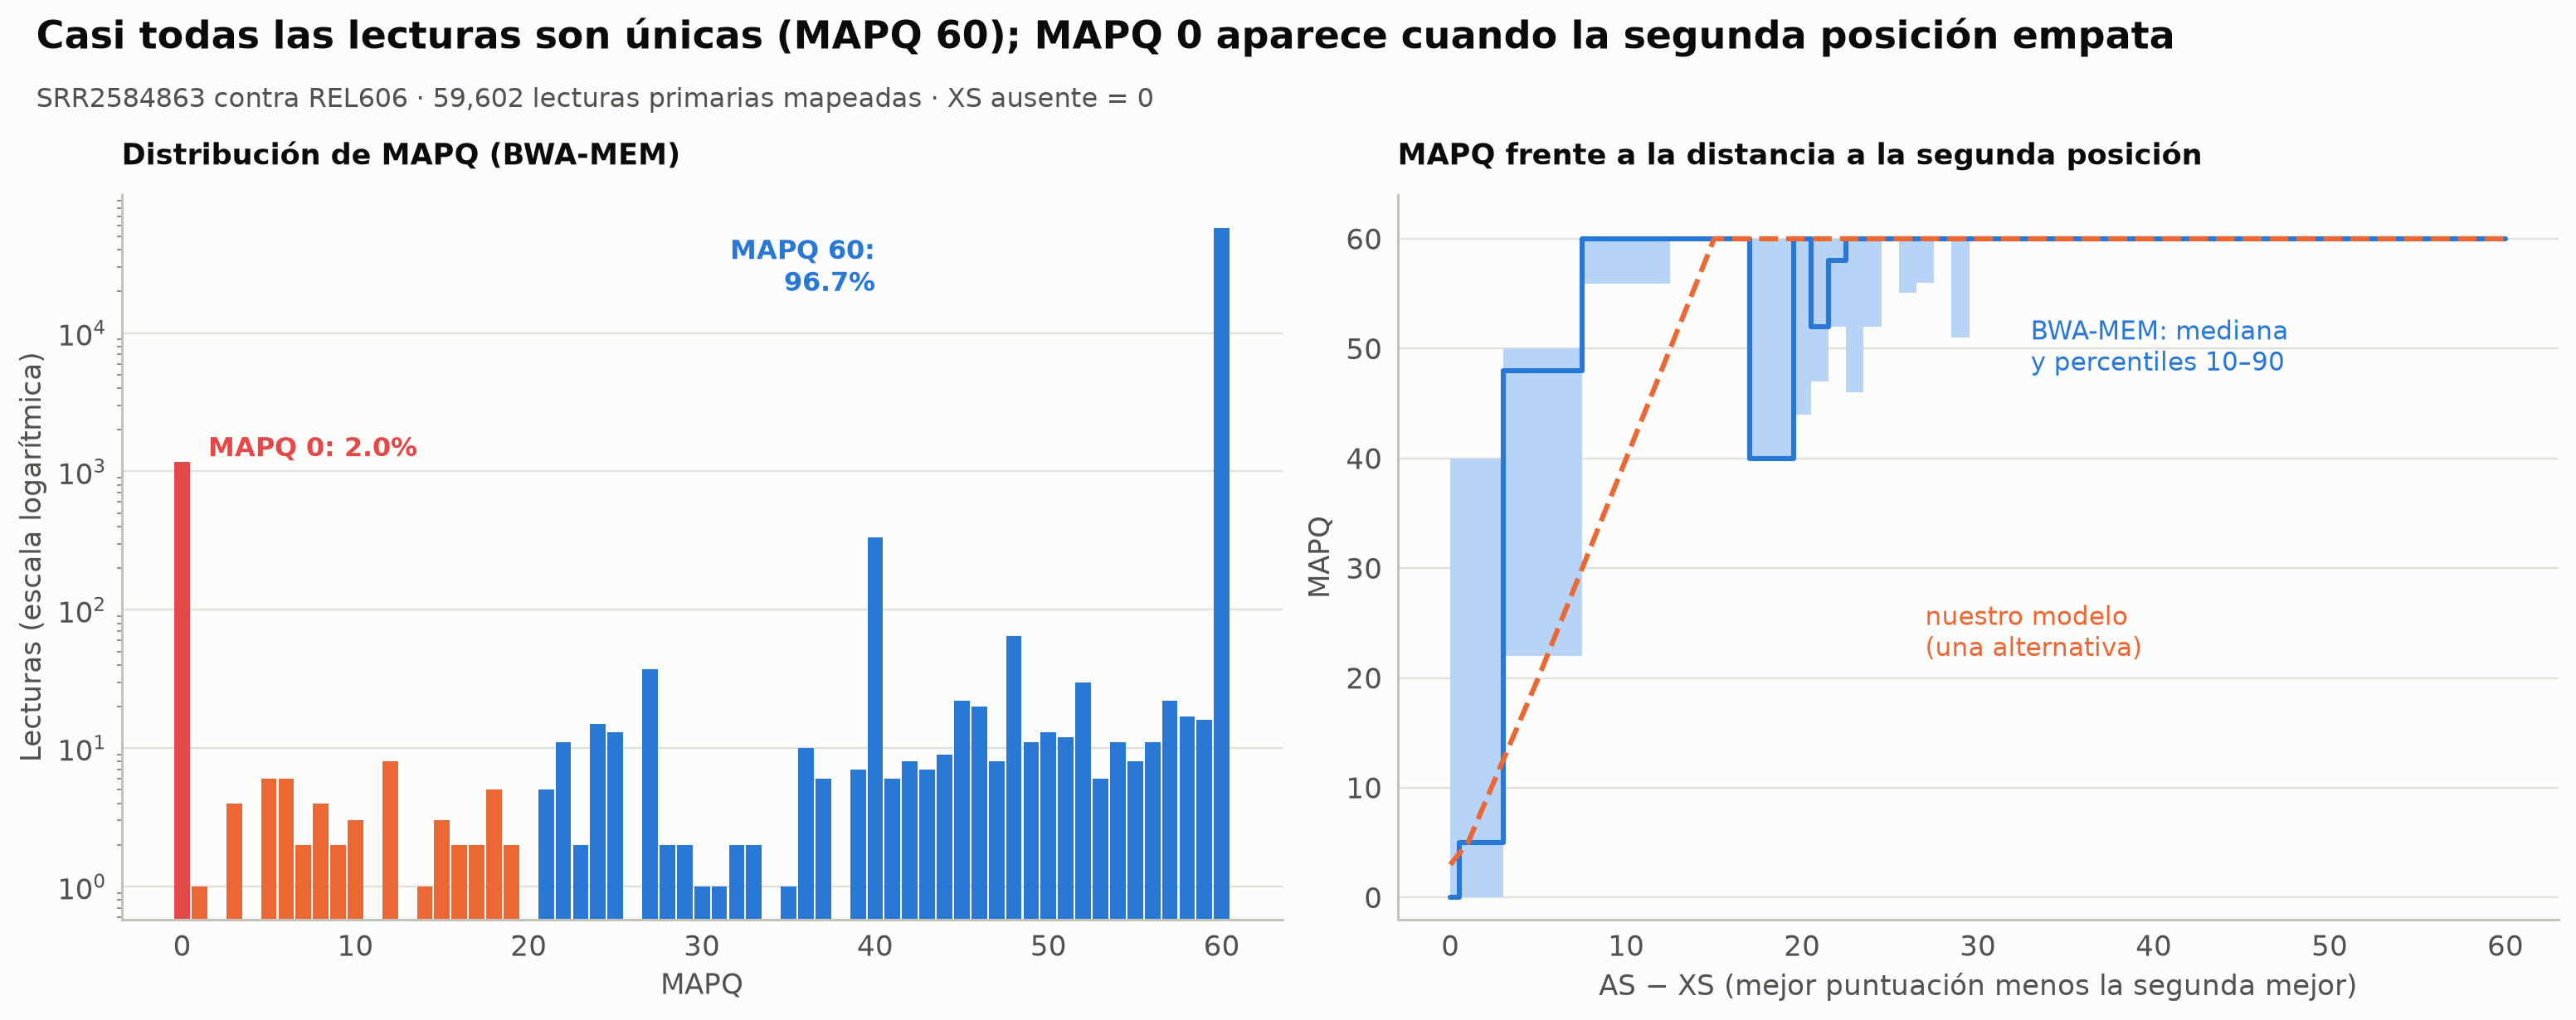

Lecturas con AS = XS: 1,501; de ellas con MAPQ 0: 76.7%


In [43]:
m_ = aln[~aln.unmapped].copy()
m_["XS"] = m_["XS"].fillna(0)
m_["delta"] = m_["AS"] - m_["XS"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
vc = m_.mapq.value_counts().sort_index()
ax.bar(vc.index, vc.values, color=[ec.RED if q == 0 else (ec.ORANGE if q < 20 else ec.BLUE) for q in vc.index], width=0.9)
ax.set_yscale("log")
ax.set_xlabel("MAPQ"); ax.set_ylabel("Lecturas (escala logarítmica)")
ax.text(1.5, vc.get(0, 1) * 1.1, f"MAPQ 0: {np.mean(m_.mapq == 0):.1%}", color=ec.RED, fontsize=10.5, fontweight="bold")
ax.text(40, vc.get(60, 1) * 0.35, f"MAPQ 60:\n{np.mean(m_.mapq == 60):.1%}", color=ec.BLUE, fontsize=10.5, fontweight="bold",
        ha="right")
ax.set_title("Distribución de MAPQ (BWA-MEM)", fontsize=11.5, loc="left")
ax = axes[1]
sub = m_[(m_.delta >= 0) & (m_.delta <= 60)]
agg = sub.groupby("delta").mapq.agg(["median", lambda s: s.quantile(0.1), lambda s: s.quantile(0.9), "size"])
agg.columns = ["mediana", "p10", "p90", "n"]
agg = agg[agg.n >= 20]
ax.fill_between(agg.index, agg.p10, agg.p90, color=ec.SEQ_BLUE[1], step="mid")
ax.step(agg.index, agg.mediana, where="mid", color=ec.BLUE, lw=2)
model = [mapq_from_scores([150, 150 - d]) for d in agg.index]
ax.plot(agg.index, model, color=ec.ORANGE, ls="--", lw=2)
ax.text(agg.index.max() * 0.45, 22, "nuestro modelo\n(una alternativa)", color=ec.ORANGE, fontsize=10)
ax.text(agg.index.max() * 0.55, 48, "BWA-MEM: mediana\ny percentiles 10–90", color=ec.BLUE, fontsize=10)
ax.set_xlabel("AS − XS (mejor puntuación menos la segunda mejor)"); ax.set_ylabel("MAPQ")
ax.set_ylim(-2, 64)
ax.set_title("MAPQ frente a la distancia a la segunda posición", fontsize=11.5, loc="left")
ec.fig_title(fig, "Casi todas las lecturas son únicas (MAPQ 60); MAPQ 0 aparece cuando la segunda posición empata",
             f"SRR2584863 contra REL606 · {len(m_):,} lecturas primarias mapeadas · XS ausente = 0")
plt.show()
tie = m_.delta == 0
print(f"Lecturas con AS = XS: {tie.sum():,}; de ellas con MAPQ 0: {np.mean(m_.loc[tie, 'mapq'] == 0):.1%}")

> 🔎 **Qué observamos.** La distribución es bimodal y extrema: casi todo es MAPQ 60, hay un grupo de MAPQ 0 y muy poco
> en medio. Cuando la segunda mejor posición **empata** con la primera (AS = XS), BWA-MEM asigna MAPQ 0 en unas tres de
> cada cuatro lecturas. ¿Y el resto? BWA-MEM también mira al **compañero**: si la otra lectura del par cae en secuencia
> única, sólo una de las copias queda a la distancia de inserto esperada, y la MAPQ del par sube. A medida que AS − XS crece, la MAPQ sube, como en nuestro modelo, aunque no con la misma forma: BWA-MEM usa su
> propia fórmula (que también tiene en cuenta la longitud de las semillas y al compañero del par) y, por ejemplo, con
> AS − XS entre 3 y 7 ya asigna MAPQ ≈ 48, más que nuestro modelo. Lo importante es la tendencia compartida: sin
> distancia a la segunda posición no hay confianza.

### 8.2 ¿Dice la verdad la MAPQ? Comprobación con lecturas simuladas

En datos reales no sabemos de dónde viene cada lectura. En los simulados sí: comparamos la posición de BWA-MEM con la
verdadera y calculamos, para cada rango de MAPQ, la fracción de lecturas mal colocadas.

  bin    n  wrong  mapq_mean  esperado
    0  964 0.8589     0.0000    1.0000
  1–3    2 0.0000     1.0000    0.7943
 4–10    2 0.0000     5.0000    0.3162
11–20   14 0.0000    15.4286    0.0287
21–30   44 0.0000    25.4091    0.0029
31–59  471 0.0000    40.7070    0.0001
   60 8503 0.0000    60.0000    0.0000

Lecturas simuladas desde repeticiones con MAPQ 0: 44.0% · desde el resto: 1.1%


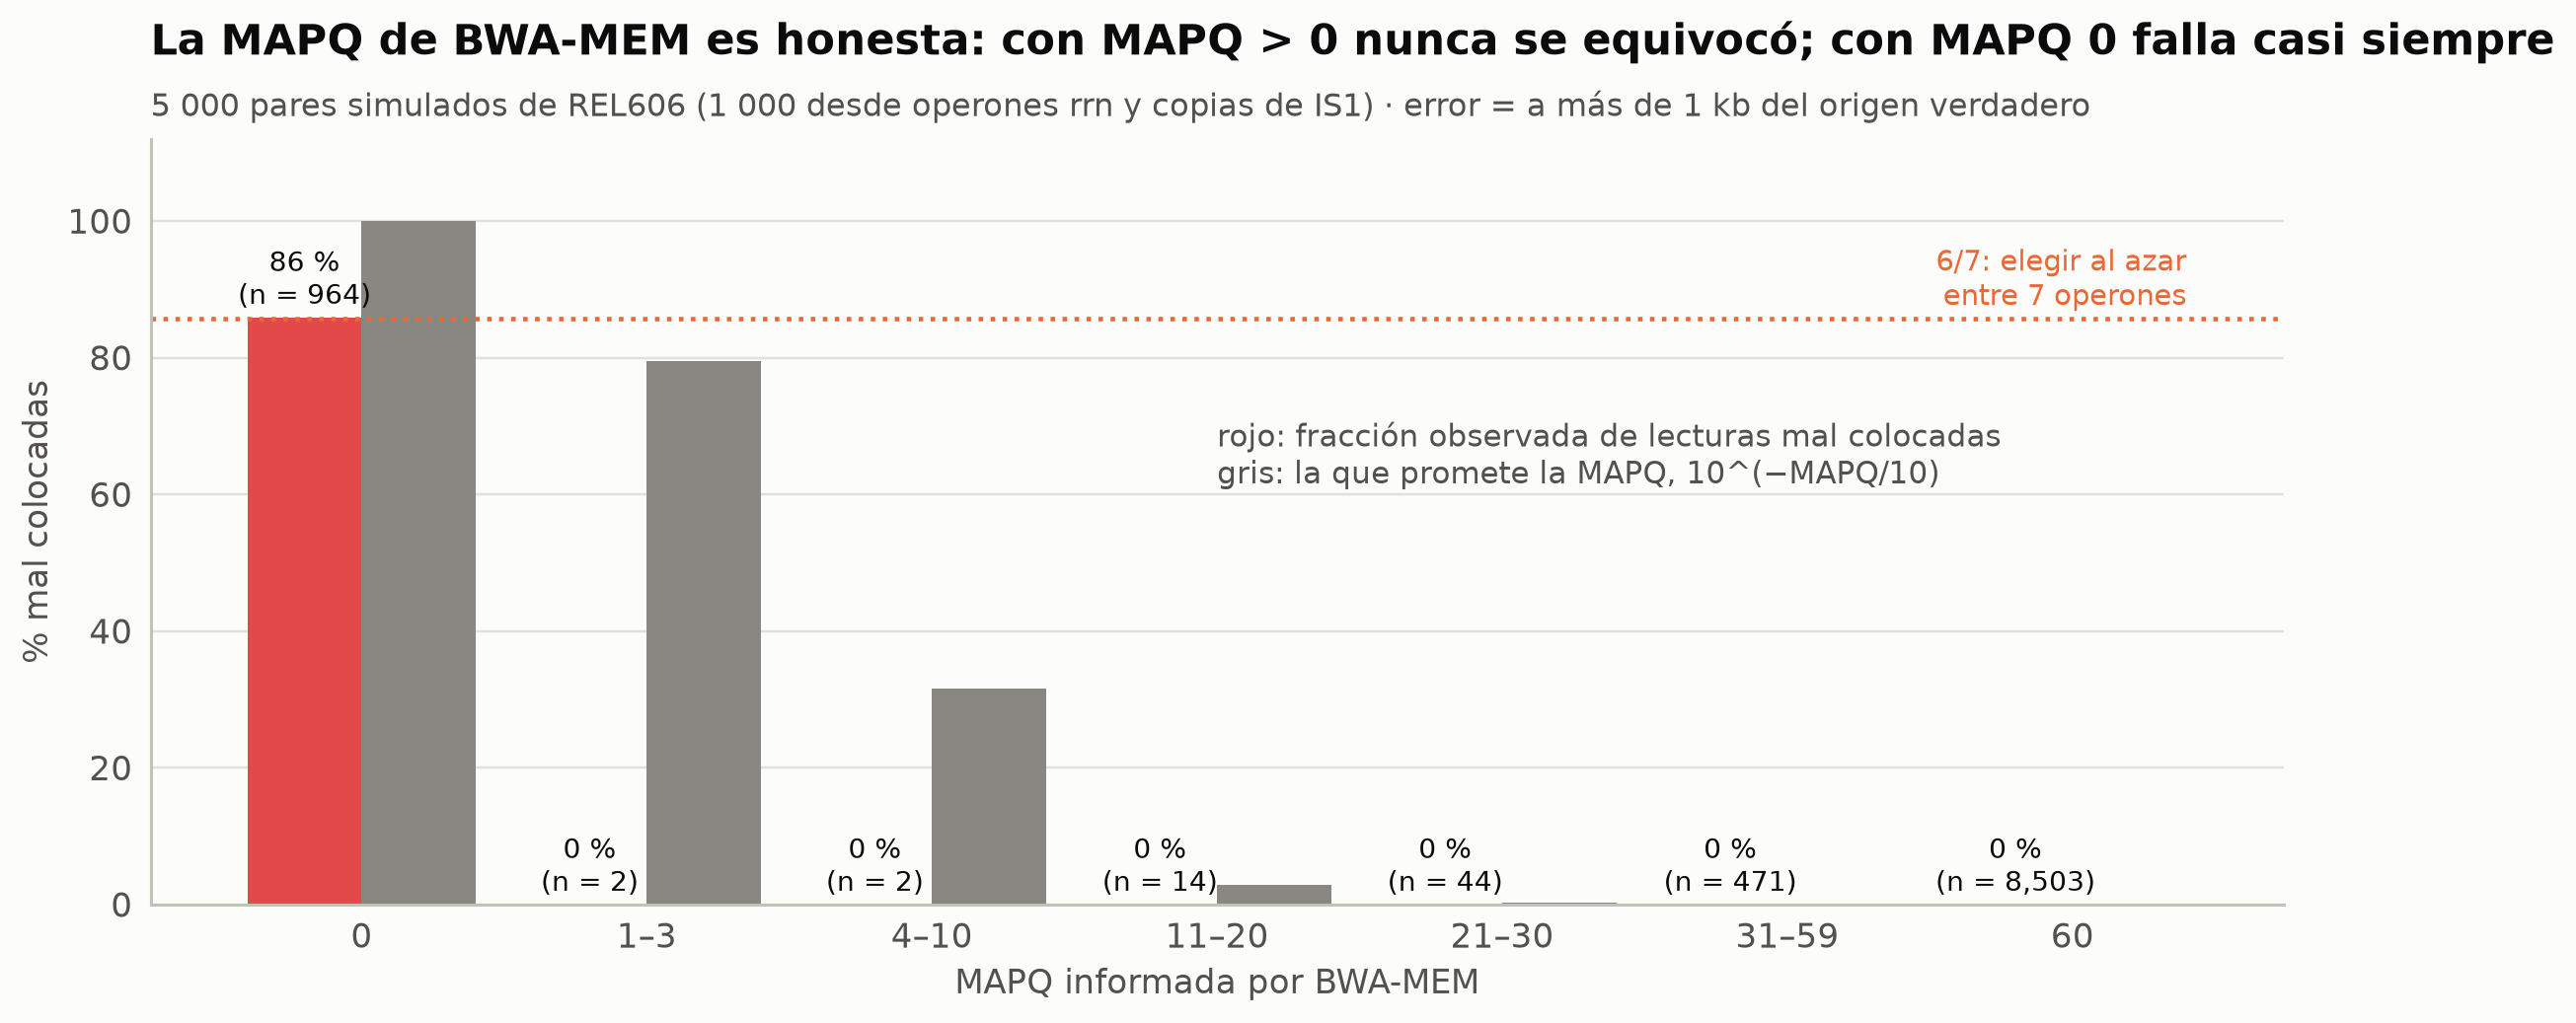

In [44]:
s_ = sim[(sim.flag & 0x904) == 0].copy()                         # primarios mapeados
s_["true_start"] = s_.qname.str.split("_").str[1].astype(int)
s_["wrong"] = (s_.pos - s_.true_start).abs() > 1000               # el fragmento mide ≤ 800 pb
s_["from_repeat"] = s_.qname.str[3:].str.split("_").str[0].astype(int) >= 4000
bins = [-1, 0, 3, 10, 20, 30, 59, 60]
labels_b = ["0", "1–3", "4–10", "11–20", "21–30", "31–59", "60"]
s_["bin"] = pd.cut(s_.mapq, bins, labels=labels_b)
calib = s_.groupby("bin", observed=False).agg(n=("wrong", "size"), wrong=("wrong", "mean"),
                                               mapq_mean=("mapq", "mean")).reset_index()
calib["esperado"] = 10 ** (-calib.mapq_mean / 10)
print(calib.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nLecturas simuladas desde repeticiones con MAPQ 0: {np.mean(s_[s_.from_repeat].mapq == 0):.1%} · "
      f"desde el resto: {np.mean(s_[~s_.from_repeat].mapq == 0):.1%}")

fig, ax = plt.subplots(figsize=(10.5, 4.6))
x_ = np.arange(len(calib))
ax.bar(x_ - 0.2, 100 * calib.wrong, width=0.4, color=ec.RED)
ax.bar(x_ + 0.2, 100 * calib.esperado.clip(upper=1), width=0.4, color=ec.MUTED)
for xi, (n, w_) in enumerate(zip(calib.n, calib.wrong)):
    ax.text(xi - 0.2, 100 * w_ + 2, f"{100 * w_:.0f} %\n(n = {n:,})", ha="center", fontsize=9, color=ec.INK)
ax.axhline(100 * 6 / 7, color=ec.ORANGE, ls=":", lw=1.5)
ax.text(len(calib) - 0.6, 100 * 6 / 7 + 2, "6/7: elegir al azar\nentre 7 operones", color=ec.ORANGE, fontsize=9.5, ha="right")
ax.text(0.5, 0.55, "rojo: fracción observada de lecturas mal colocadas\ngris: la que promete la MAPQ, 10^(−MAPQ/10)",
        transform=ax.transAxes, fontsize=10, color=ec.INK_2)
ax.set_xticks(x_, labels_b); ax.set_xlabel("MAPQ informada por BWA-MEM"); ax.set_ylabel("% mal colocadas")
ax.set_ylim(0, 112)
ec.title(ax, "La MAPQ de BWA-MEM es honesta: con MAPQ > 0 nunca se equivocó; con MAPQ 0 falla casi siempre",
         "5 000 pares simulados de REL606 (1 000 desde operones rrn y copias de IS1) · error = a más de 1 kb del origen verdadero")
plt.show()

> 🔎 **Qué observamos.** Las lecturas con MAPQ 0 están mal colocadas en torno al 86 % de las veces: casi exactamente
> $6/7 \approx 0.857$, lo que se espera si el mapeador elige al azar entre siete copias idénticas. En cambio, ninguna
> lectura con MAPQ > 0 cayó en un lugar equivocado: en este genoma pequeño y con lecturas de 150 nt, BWA-MEM es
> incluso **conservador** (promete, por ejemplo, 1 error en 1 000 con MAPQ 30, y comete menos). La lección práctica: una
> lectura con MAPQ 0 no aporta información de posición; hay que descartarla o tratarla aparte.

### 8.3 Las repeticiones reales: operones *rrn* e IS1

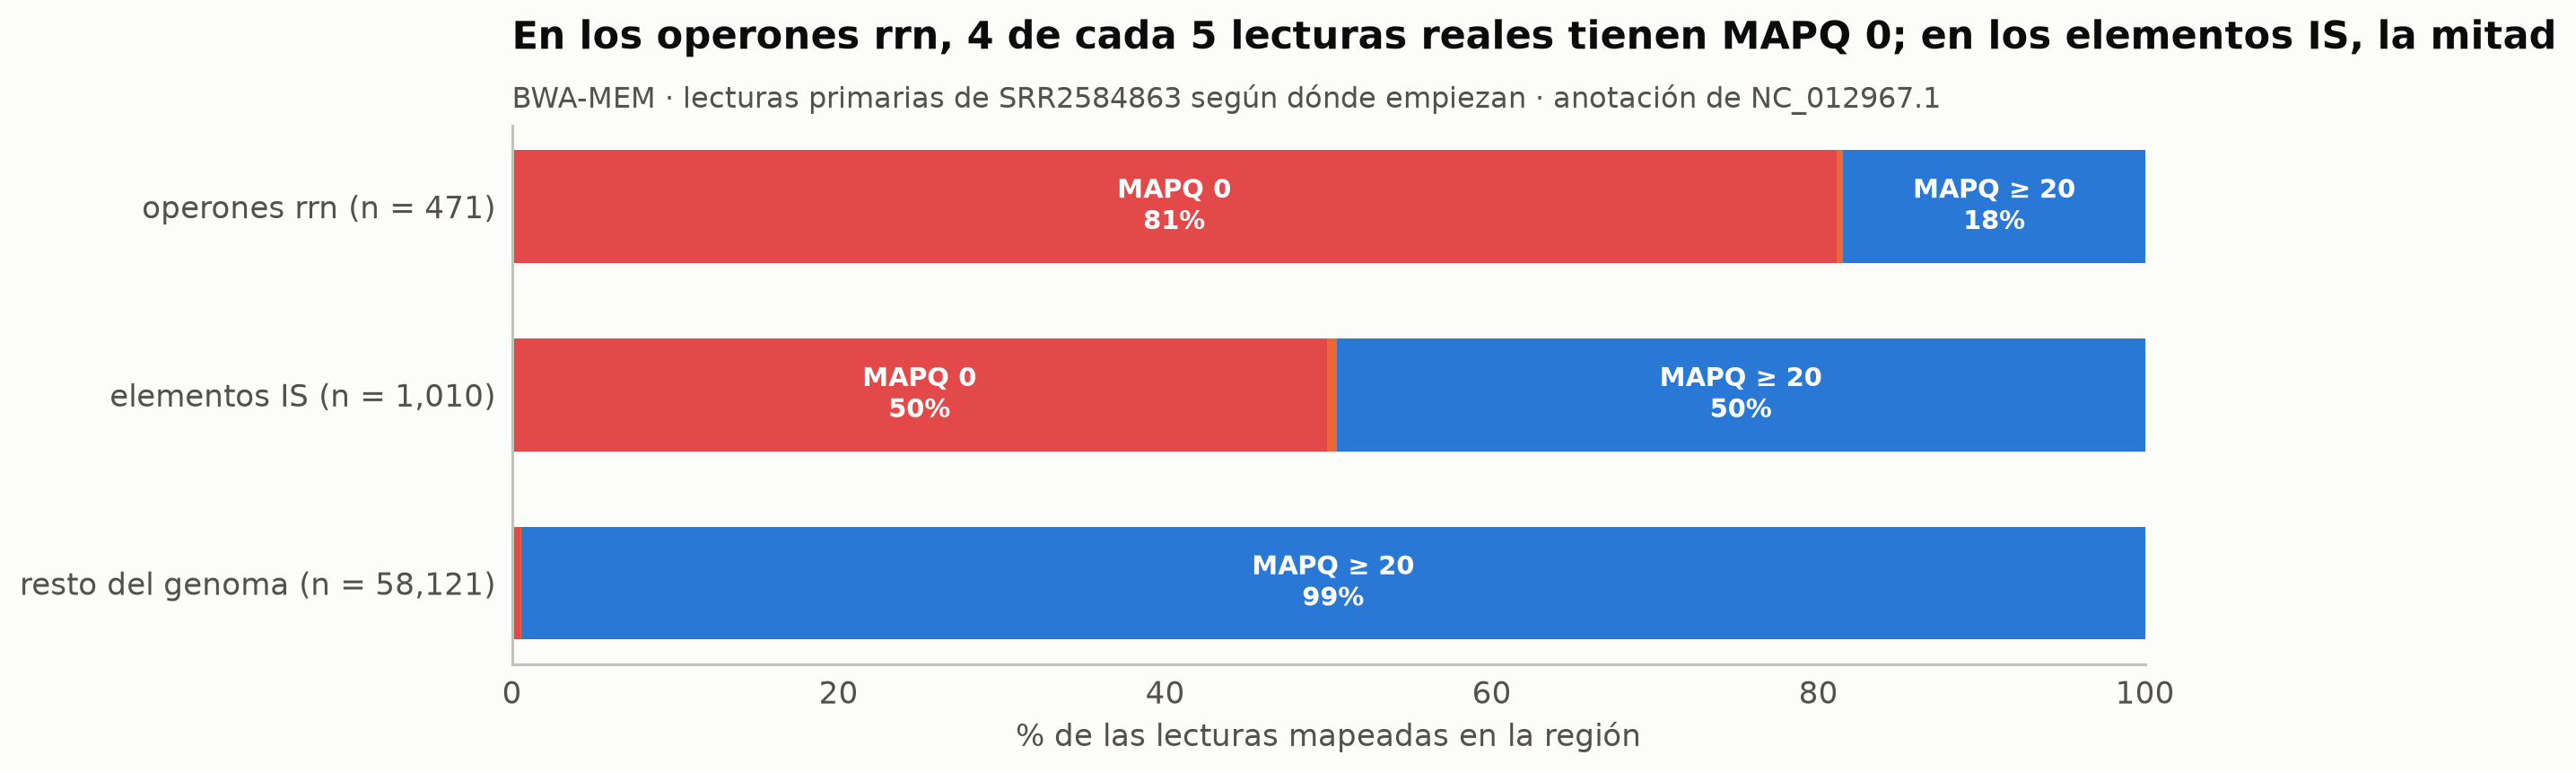

In [45]:
m_["region"] = np.where(in_intervals(m_.pos.values, operons.start, operons.end), "operones rrn",
                np.where(in_intervals(m_.pos.values, is_elems.start, is_elems.end), "elementos IS", "resto del genoma"))
m_["clase"] = pd.cut(m_.mapq, [-1, 0, 19, 60], labels=["MAPQ 0", "MAPQ 1–19", "MAPQ ≥ 20"])
tab = pd.crosstab(m_.region, m_.clase, normalize="index").loc[["resto del genoma", "elementos IS", "operones rrn"]]
counts = m_.region.value_counts()
fig, ax = plt.subplots(figsize=(11, 3.8))
left = np.zeros(len(tab))
for col, c in zip(tab.columns, [ec.RED, ec.ORANGE, ec.BLUE]):
    ax.barh(range(len(tab)), 100 * tab[col], left=left, color=c, height=0.6)
    for i_, (l_, v_) in enumerate(zip(left, tab[col])):
        if v_ > 0.06:
            ax.text(l_ + 50 * v_, i_, f"{col}\n{v_:.0%}", ha="center", va="center", color="white", fontsize=9.5,
                    fontweight="bold")
    left += 100 * tab[col].values
ax.set_yticks(range(len(tab)), [f"{r} (n = {counts[r]:,})" for r in tab.index])
ax.set_xlim(0, 100); ax.set_xlabel("% de las lecturas mapeadas en la región")
ec.title(ax, "En los operones rrn, 4 de cada 5 lecturas reales tienen MAPQ 0; en los elementos IS, la mitad",
         "BWA-MEM · lecturas primarias de SRR2584863 según dónde empiezan · anotación de NC_012967.1")
plt.show()

> 🔎 **Qué observamos.** Fuera de las repeticiones, más del 99 % de las lecturas tiene MAPQ ≥ 20. Dentro de los
> operones *rrn*, la mayoría tiene MAPQ 0; las que se salvan son las que contienen alguna de las pocas diferencias entre
> copias (la matriz del 16S de la sección 2) o las que tocan el borde del operón y alcanzan secuencia única. En los
> elementos IS la proporción es de la mitad: las familias con muchas copias (IS1, IS3) producen lecturas ambiguas,
> pero algunas familias tienen una sola copia en REL606 y sus lecturas son únicas. Si filtramos por MAPQ ≥ 20 (lo habitual antes de llamar variantes), esas regiones
> quedarán **ciegas**: no podremos ver mutaciones en ellas con lecturas cortas. Volveremos a esto en la sección 10.

#### La referencia también decide: GRCh38 frente a T2T-CHM13

Cuánto de este problema es inevitable depende de la **referencia**. Imagine que en nuestro FASTA faltara uno de los
siete operones *rrn*: las lecturas de esa copia no desaparecerían, se irían a las otras seis, **con confianza**, y
llevarían sus pocas diferencias propias como si fueran mutaciones. Es lo que la advertencia de la sección 6 llamaba
"la MAPQ depende de la referencia", y es la misma razón por la que mapeamos contra REL606 y no contra K-12.

En el genoma humano el efecto es enorme. **GRCh38**, pese a su calidad (Schneider *et al.*, 2017), dejó huecos en los
centrómeros y en los brazos cortos de los cromosomas acrocéntricos. El genoma **T2T-CHM13** (Nurk *et al.*, 2022)
completó el 8 % restante: 3 055 millones de bases **sin huecos**, con casi 200 millones de bases nuevas, en buena parte
satélites y duplicaciones segmentarias recientes. Las lecturas que antes no tenían dónde caer, o que caían en una copia
parálogas equivocada, ahora tienen un sitio.

**Ejemplo a mano.** ¿Cuántas lecturas de un genoma a $c = 30\times$ con $m = 150$ proceden de esos
$\Delta \approx 2\times10^{8}$ pb nuevos? $N_\Delta = c\,\Delta/m = 30\cdot 2\times10^{8}/150 = 4\times10^{7}$:
**cuarenta millones** de lecturas por muestra que, con GRCh38, se quedaban sin mapear o se mapeaban en otro sitio.

$$
N_\Delta \;=\; \frac{c\,\Delta}{m}
$$

| Símbolo | Significado |
|---|---|
| $c$ | cobertura media (Lección 6.3) |
| $\Delta$ | bases de la muestra que faltan en la referencia (o que la referencia tiene colapsadas en menos copias) |
| $m$ | longitud de la lectura |
| $N_\Delta$ | lecturas que no tienen su origen verdadero en la referencia |

In [46]:
def reads_without_home(c, delta, m=150):
    """Lecturas cuyo origen verdadero falta en la referencia: N = c·Δ/m."""
    return c * delta / m

ref_rows = [("Humano, T2T-CHM13 frente a GRCh38 (~200 Mb nuevas)", 30, 200e6),
            ("REL606 sin un operón rrn (5 kb), a la cobertura de esta submuestra", 2 * len(seqs1) * L / G, 5_000),
            ("REL606 sin un operón rrn (5 kb), a 30×", 30, 5_000)]
tab_ref = pd.DataFrame([(lab, f"{c_:.1f}×", f"{d_:,.0f}", f"{reads_without_home(c_, d_):,.0f}") for lab, c_, d_ in ref_rows],
                       columns=["situación", "c", "Δ (pb)", "N_Δ = c·Δ/m"])
tab_ref

,situación,c,Δ (pb),N_Δ = c·Δ/m
0,"Humano, T2T-CHM13 frente a GRCh38 (~200 Mb nue...",30.0×,"200,000,000","40,000,000"
1,"REL606 sin un operón rrn (5 kb), a la cobertur...",1.9×,"5,000",65
2,"REL606 sin un operón rrn (5 kb), a 30×",30.0×,"5,000","1,000"


> 🔎 **Qué observamos.** En el humano, completar la referencia devuelve su sitio a decenas de millones de lecturas por
> muestra, casi todas en satélites y duplicaciones segmentarias. En nuestra bacteria las cifras son pequeñas, pero la
> lógica es idéntica: a 30×, un solo operón ausente del FASTA mandaría ≈ 1 000 lecturas a las otras copias, donde
> parecerían un puñado de "mutaciones" con buena calidad de mapeo. Antes de interpretar una variante en una región
> repetida, pregunte siempre qué referencia se usó.

### 8.4 Orientación de los pares y tamaño de inserto

En una biblioteca Illumina estándar, R1 y R2 se leen desde los dos extremos del fragmento **hacia dentro**: la lectura
de la izquierda va en la hebra + y la de la derecha en la −. Es la orientación **FR** (*forward–reverse*, "hacia
dentro"). **RF** (hacia fuera) aparece en bibliotecas *mate-pair* o cuando el fragmento cruza el origen de un genoma
circular. **FF/RR** (misma hebra) indican reordenamientos o errores.

El **tamaño de inserto** (TLEN, con signo) es la distancia desde el inicio de la lectura más a la izquierda hasta el
final de la más a la derecha.

In [47]:
r1 = aln[(aln.mate == "R1") & ~aln.unmapped & ~aln.mate_unmapped].copy()
r1["abs_tlen"] = r1.tlen.abs()
wrap = r1.abs_tlen > G / 2                                  # el fragmento cruza el origen del cromosoma circular
left_is_r1 = r1.tlen > 0
left_rev = np.where(left_is_r1, r1.rev, r1.mate_rev)
right_rev = np.where(left_is_r1, r1.mate_rev, r1.rev)
r1["orient"] = np.select([~left_rev & right_rev, left_rev & ~right_rev, ~left_rev & ~right_rev],
                         ["FR (hacia dentro)", "RF (hacia fuera)", "FF"], "RR")
r1.loc[wrap, "orient"] = "cruza el origen"
r1.loc[r1.tlen == 0, "orient"] = "sin TLEN"
orient_counts = r1.orient.value_counts()
print(orient_counts.to_string())
fr = r1[(r1.orient == "FR (hacia dentro)")]
q_ = fr.abs_tlen.quantile([0.25, 0.5, 0.75])
print(f"\nInserto de los pares FR: cuartiles {q_.values.astype(int)} pb · > 800 pb: {np.mean(fr.abs_tlen > 800):.1%}")

orient
FR (hacia dentro)    29153
RR                     158
FF                     148
cruza el origen         86
RF (hacia fuera)        61

Inserto de los pares FR: cuartiles [273 553 753] pb · > 800 pb: 19.4%


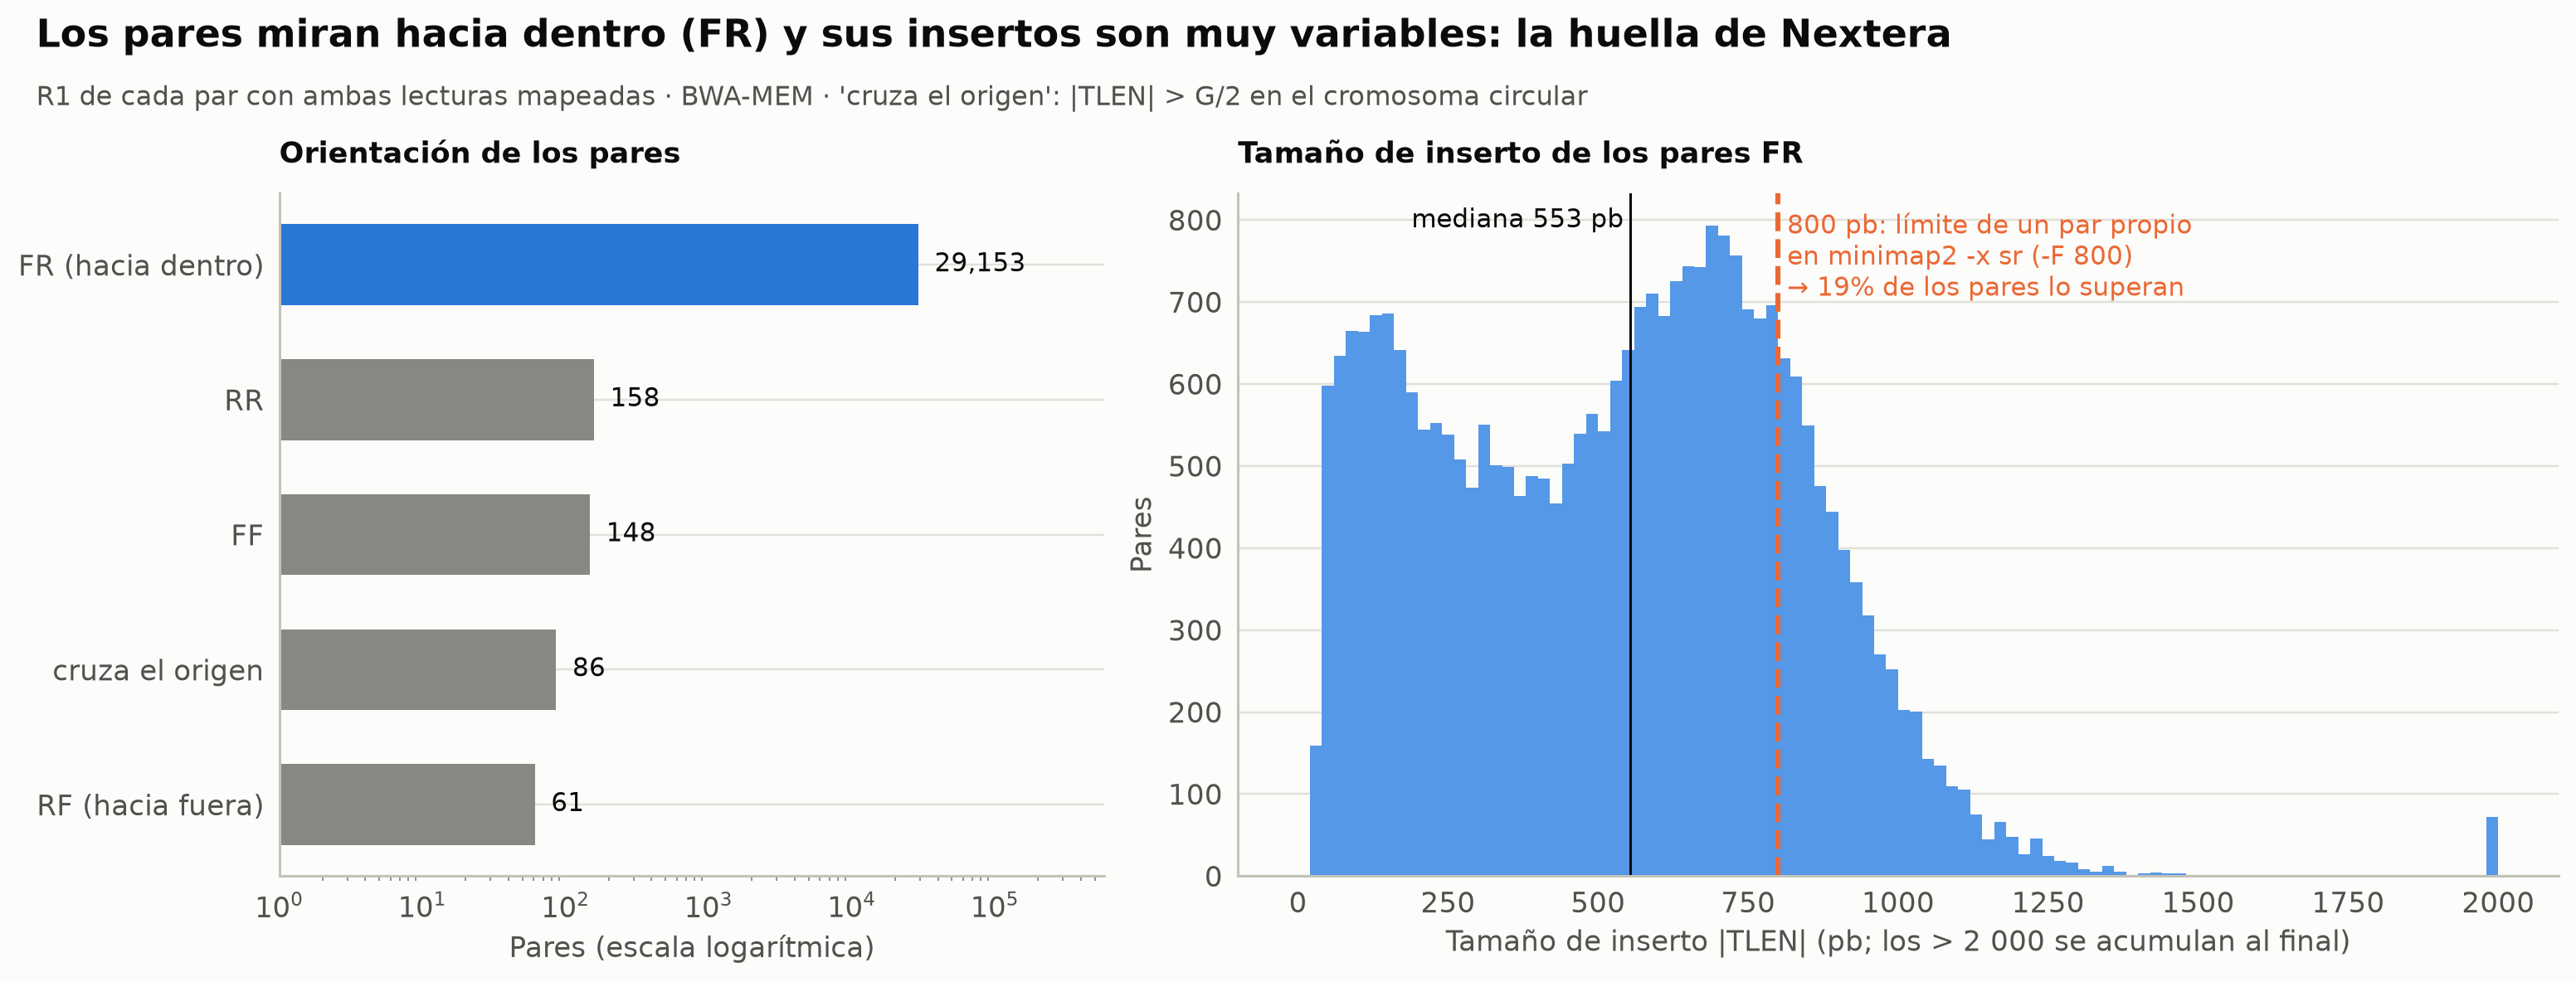

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw=dict(width_ratios=[1, 1.6]))
ax = axes[0]
oc = orient_counts.sort_values()
ax.barh(range(len(oc)), oc.values, color=[ec.BLUE if "FR" in o else ec.MUTED for o in oc.index], height=0.6)
for i_, v_ in enumerate(oc.values):
    ax.text(v_ * 1.3, i_, f"{v_:,}", va="center", fontsize=10)
ax.set_xscale("log"); ax.set_xlim(1, oc.max() * 20)
ax.set_yticks(range(len(oc)), oc.index); ax.set_xlabel("Pares (escala logarítmica)")
ax.set_title("Orientación de los pares", fontsize=11.5, loc="left")
ax = axes[1]
bins_i = np.arange(0, 2001, 20)
ax.hist(fr.abs_tlen.clip(upper=2000), bins=bins_i, color=ec.SEQ_BLUE[5])
ax.axvline(800, color=ec.ORANGE, lw=2, ls="--")
ax.text(815, ax.get_ylim()[1] * 0.85, f"800 pb: límite de un par propio\nen minimap2 -x sr (-F 800)\n"
                                      f"→ {np.mean(fr.abs_tlen > 800):.0%} de los pares lo superan",
        color=ec.ORANGE, fontsize=10)
ax.axvline(q_[0.5], color=ec.INK, lw=1)
ax.text(q_[0.5] - 10, ax.get_ylim()[1] * 0.95, f"mediana {q_[0.5]:.0f} pb", ha="right", fontsize=10)
ax.set_xlabel("Tamaño de inserto |TLEN| (pb; los > 2 000 se acumulan al final)"); ax.set_ylabel("Pares")
ax.set_title("Tamaño de inserto de los pares FR", fontsize=11.5, loc="left")
ec.fig_title(fig, "Los pares miran hacia dentro (FR) y sus insertos son muy variables: la huella de Nextera",
             "R1 de cada par con ambas lecturas mapeadas · BWA-MEM · 'cruza el origen': |TLEN| > G/2 en el cromosoma circular")
plt.show()

> 🔎 **Qué observamos.** Casi todos los pares son FR, como corresponde a una biblioteca de extremos pareados. Los
> pocos cientos de FF, RR y RF (≈ 1 %) tienen ambas lecturas bien alineadas pero a distancias de kilobases o
> megabases: pueden ser fragmentos quiméricos de la biblioteca o reordenamientos reales del clon frente al ancestro
> (en un estudio de variantes estructurales serían el punto de partida); con 30 000 pares no podemos distinguirlos. Hay unas
> decenas de pares cuyo |TLEN| es de millones de pares de bases: no son reordenamientos, son fragmentos que **cruzan el
> origen** del cromosoma circular, y en las coordenadas lineales del FASTA parecen estar a 4.6 Mb de distancia. Los
> insertos de la biblioteca **Nextera** son muy variables (la transposasa corta donde le toca): desde menos de 150 pb
> (los que producían *read-through* de adaptador en la 6.2) hasta más de 1 kb. Eso tendrá consecuencias al comparar
> mapeadores (sección 9).

### Cómo puntúa BWA-MEM un par: $S_{ij}$ y el modelo normal del tamaño de inserto

Las dos lecturas de un par no son independientes: deben caer en hebras opuestas, mirándose, a una distancia compatible
con el tamaño de los fragmentos de la biblioteca. Esa información resuelve ambigüedades: si R1 cae en un operón *rrn*
pero R2 cae en secuencia única, R2 "ancla" a R1, porque sólo una de las siete copias queda a la distancia esperada (así
se explica que una parte de las lecturas con AS = XS de la sección 8.1 no tuviera MAPQ 0). BWA-MEM estima la
distribución del inserto con los pares únicos (el registro `mem_pestat`), le ajusta una **normal** y puntúa cada
combinación $(i, j)$ de ubicaciones de las dos lecturas **restando** una penalización que crece cuanto más improbable
es la distancia:

$$
S_{ij} \;=\; S_i + S_j - \min\big\{-a\log_4 P(d_{ij}),\; U\big\}
$$

| Símbolo | Significado |
|---|---|
| $S_i,\ S_j$ | puntuaciones de Smith–Waterman de cada lectura en su ubicación (la etiqueta `AS`) |
| $d_{ij}$ | distancia entre las dos ubicaciones (infinita si la orientación es incorrecta) |
| $P(d)$ | probabilidad de observar un inserto mayor que $d$ según la distribución normal ajustada, de media $\mu$ y desviación $\sigma$ |
| $a$ | puntuación de una coincidencia (1 en BWA-MEM, opción `-A`); convierte probabilidades en unidades de puntuación |
| $U$ | penalización máxima (17 por defecto, opción `-U`): si el par es muy improbable, es preferible tratar las lecturas como no emparejadas |

El logaritmo en base 4 aparece al interpretar la puntuación de Smith–Waterman como una razón de verosimilitudes
(Lección 3.3): con cuatro bases equiprobables, una coincidencia "vale" un factor 4. Los pares **concordantes** son los
que caen en $\mu \pm 4\sigma$; los que el modelo no puede explicar (demasiado separados, demasiado juntos o mal
orientados) son **discordantes**, y son justo la señal que buscan los detectores de variantes estructurales.

**Ejemplo a mano (el modelo del libro: $\mu = 350$, $\sigma = 40$; $a = 1$, $U = 17$; dos lecturas perfectas,
$S_i = S_j = 150$).**

| $d_{ij}$ | $z = (d-\mu)/\sigma$ | $P(d)$ | $-\log_4 P(d)$ | $S_{ij}$ |
|---|---|---|---|---|
| 350 ($\mu$) | 0 | 0.5 | 0.50 | 299.5 |
| 430 ($\mu + 2\sigma$) | 2 | 0.0228 | 2.73 | 297.3 |
| 510 ($\mu + 4\sigma$) | 4 | $3.17\times10^{-5}$ | 7.47 | 292.5 |
| 1 550 (una deleción de 1.2 kb en la muestra) | 30 | $\approx 0$ | enorme → tope $U = 17$ | 283.0 |

Bajo el modelo normal, un inserto mayor que $\mu + 4\sigma = 510$ pb tiene probabilidad $3\times10^{-5}$: con 20 000
pares esperaríamos menos de uno por azar. Si aparecen 150 agrupados en la misma región, algo le pasó al genoma de la
muestra (en el ejemplo del libro, una deleción de 1 200 pb: la referencia conserva el segmento que la muestra perdió y
los pares que lo atraviesan parecen 1 200 pb más largos).

In [49]:
from math import erfc, sqrt, log

def p_longer(d, mu, sigma):
    """P(inserto > d) bajo una normal N(μ, σ²)."""
    return 0.5 * erfc((d - mu) / (sigma * sqrt(2)))

def pair_penalty(d, mu, sigma, a=1, U=17):
    p = p_longer(d, mu, sigma)
    return U if p <= 0 else min(-a * log(p) / log(4), U)

def pair_score(S_i, S_j, d, mu, sigma, a=1, U=17):
    """S_ij = S_i + S_j − min{−a·log4 P(d), U} (Li, 2013)."""
    return S_i + S_j - pair_penalty(d, mu, sigma, a, U)

for d_ in (350, 430, 510, 1550):
    print(f"μ = 350, σ = 40, d = {d_:>5}: P(d) = {p_longer(d_, 350, 40):.3g} · penalización "
          f"{pair_penalty(d_, 350, 40):5.2f} · S_ij = {pair_score(150, 150, d_, 350, 40):.1f}")

# el modelo que BWA-MEM ajustó a NUESTRA biblioteca (orientación FR, registro mem_pestat)
fr_lines = pestat[[i for i, l in enumerate(pestat) if "orientation FR" in l][0]:]
mu_fr, sd_fr = map(float, re.search(r"(?<!computing )mean and std.dev: \(([\d.]+), ([\d.]+)\)", "\n".join(fr_lines)).groups())
q25, q50, q75 = map(int, re.search(r"percentile: \((\d+), (\d+), (\d+)\)", "\n".join(fr_lines)).groups())
lo_pp, hi_pp = map(int, re.search(r"proper pairs: \((\d+), (\d+)\)", "\n".join(fr_lines)).groups())
print(f"\nSRR2584863 (FR): μ = {mu_fr:.0f}, σ = {sd_fr:.0f} → μ ± 4σ = ({mu_fr - 4 * sd_fr:.0f}, {mu_fr + 4 * sd_fr:.0f}) pb")
print(f"Cuartiles ({q25}, {q50}, {q75}) · límites de par propio de BWA-MEM: ({lo_pp}, {hi_pp}) = Q3 + 3·IQR = {q75 + 3 * (q75 - q25)}")

# un par real: R1 y R2 del mismo fragmento, con sus AS y su |TLEN|
good_ = aln[aln.proper & (aln.AS >= 145) & (aln.tlen.abs().between(300, 700))]
pr_ = good_[(good_.mate == "R1") & good_.qname.isin(good_[good_.mate == "R2"].qname)].iloc[0]
pr2 = good_[(good_.qname == pr_.qname) & (good_.mate == "R2")].iloc[0]
print(f"\nPar real {pr_.qname}: AS(R1) = {pr_.AS:.0f}, AS(R2) = {pr2.AS:.0f}, |TLEN| = {abs(pr_.tlen)} pb → "
      f"S_ij = {pair_score(pr_.AS, pr2.AS, abs(pr_.tlen), mu_fr, sd_fr):.1f}")

μ = 350, σ = 40, d =   350: P(d) = 0.5 · penalización  0.50 · S_ij = 299.5
μ = 350, σ = 40, d =   430: P(d) = 0.0228 · penalización  2.73 · S_ij = 297.3
μ = 350, σ = 40, d =   510: P(d) = 3.17e-05 · penalización  7.47 · S_ij = 292.5
μ = 350, σ = 40, d =  1550: P(d) = 4.91e-198 · penalización 17.00 · S_ij = 283.0

SRR2584863 (FR): μ = 525, σ = 289 → μ ± 4σ = (-630, 1679) pb
Cuartiles (268, 547, 746) · límites de par propio de BWA-MEM: (1, 2180) = Q3 + 3·IQR = 2180

Par real SRR2584863.15746: AS(R1) = 150, AS(R2) = 150, |TLEN| = 689 pb → S_ij = 299.1


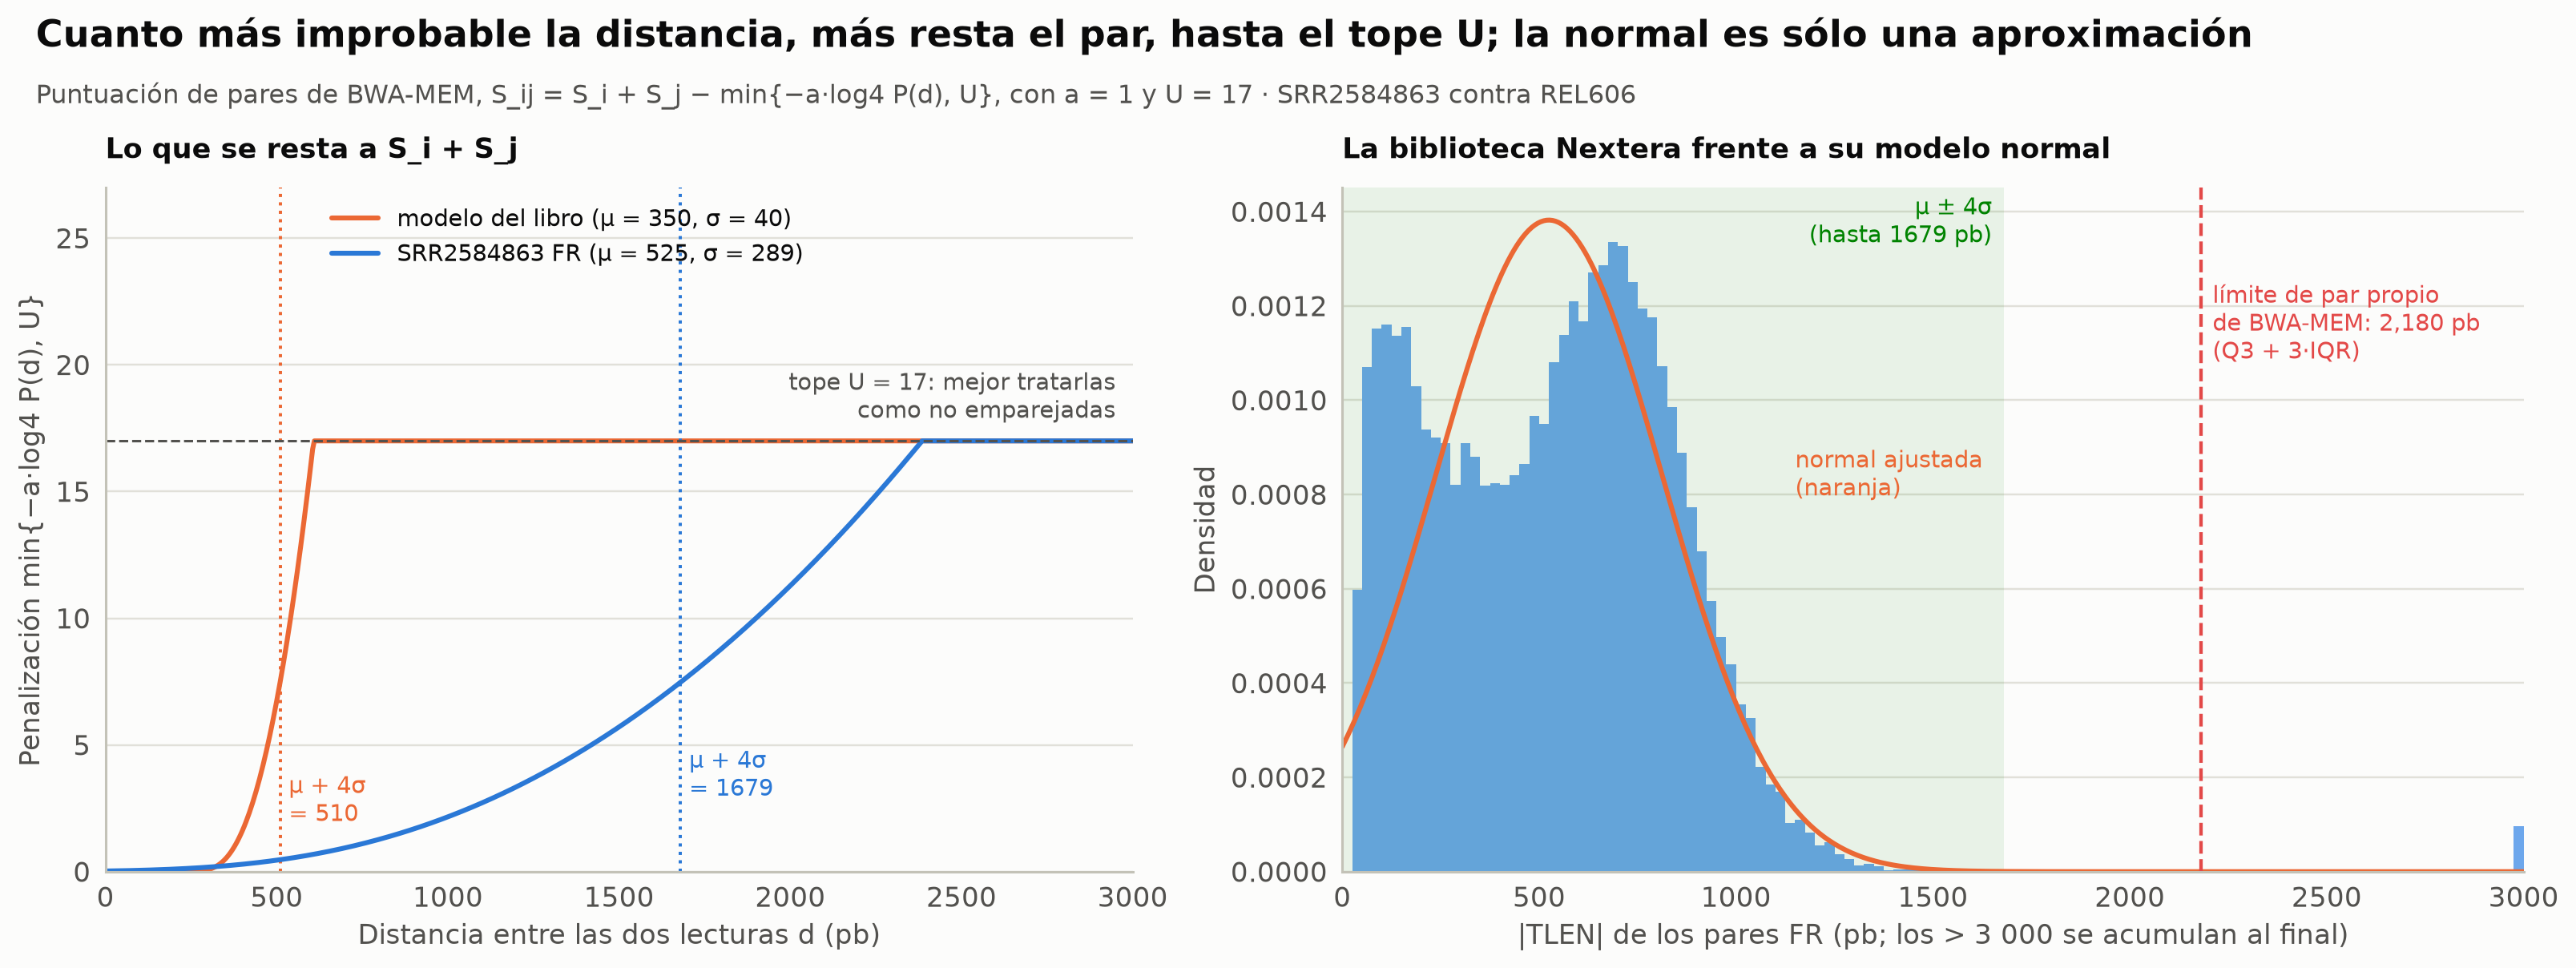

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.7), gridspec_kw=dict(width_ratios=[1, 1.15]))
ax = axes[0]
dd = np.arange(0, 3001, 5)
for (mu_, sd_, col, lab) in [(350, 40, ec.ORANGE, "modelo del libro (μ = 350, σ = 40)"),
                              (mu_fr, sd_fr, ec.BLUE, f"SRR2584863 FR (μ = {mu_fr:.0f}, σ = {sd_fr:.0f})")]:
    ax.plot(dd, [pair_penalty(x, mu_, sd_) for x in dd], color=col, lw=2, label=lab)
    ax.axvline(mu_ + 4 * sd_, color=col, ls=":", lw=1.3)
    ax.text(mu_ + 4 * sd_ + 25, 2 if col == ec.ORANGE else 3, f"μ + 4σ\n= {mu_ + 4 * sd_:.0f}", color=col, fontsize=9.5)
ax.axhline(17, color=ec.INK_2, ls="--", lw=1)
ax.text(2950, 17.6, "tope U = 17: mejor tratarlas\ncomo no emparejadas", ha="right", va="bottom", fontsize=9.5, color=ec.INK_2)
ax.set_ylim(0, 27); ax.set_xlim(0, 3000)
ax.set_xlabel("Distancia entre las dos lecturas d (pb)"); ax.set_ylabel("Penalización min{−a·log4 P(d), U}")
ax.legend(loc="upper left", bbox_to_anchor=(0.2, 1.0), frameon=False, fontsize=9.5)
ax.set_title("Lo que se resta a S_i + S_j", fontsize=11.5, loc="left")
ax = axes[1]
bins_n = np.arange(0, 3001, 25)
ax.hist(fr.abs_tlen.clip(upper=3000), bins=bins_n, color=ec.SEQ_BLUE[4], density=True)
xx = np.linspace(0, 3000, 400)
ax.plot(xx, np.exp(-(xx - mu_fr) ** 2 / (2 * sd_fr ** 2)) / (sd_fr * np.sqrt(2 * np.pi)), color=ec.ORANGE, lw=2)
ax.axvspan(max(0, mu_fr - 4 * sd_fr), mu_fr + 4 * sd_fr, color=ec.GREEN, alpha=0.08, lw=0)
ax.axvline(hi_pp, color=ec.RED, ls="--", lw=1.4)
ytop = ax.get_ylim()[1]
ax.text(mu_fr + 4 * sd_fr - 30, ytop * 0.92, f"μ ± 4σ\n(hasta {mu_fr + 4 * sd_fr:.0f} pb)", ha="right", fontsize=9.5, color=ec.GREEN)
ax.text(hi_pp + 30, ytop * 0.75, f"límite de par propio\nde BWA-MEM: {hi_pp:,} pb\n(Q3 + 3·IQR)", fontsize=9.5, color=ec.RED)
ax.text(1150, ytop * 0.55, "normal ajustada\n(naranja)", fontsize=9.5, color=ec.ORANGE)
ax.set_xlabel("|TLEN| de los pares FR (pb; los > 3 000 se acumulan al final)"); ax.set_ylabel("Densidad")
ax.set_xlim(0, 3000)
ax.set_title("La biblioteca Nextera frente a su modelo normal", fontsize=11.5, loc="left")
ec.fig_title(fig, "Cuanto más improbable la distancia, más resta el par, hasta el tope U; la normal es sólo una aproximación",
             "Puntuación de pares de BWA-MEM, S_ij = S_i + S_j − min{−a·log4 P(d), U}, con a = 1 y U = 17 · SRR2584863 contra REL606")
plt.show()

> 🔎 **Qué observamos.** Con el modelo estrecho del libro ($\sigma = 40$), la penalización pasa de 0.5 a 17 en unos
> 250 pb: un par a 600 pb ya se trata como dos lecturas sueltas. Con nuestra biblioteca Nextera ($\sigma$ de casi
> 300 pb) la curva es mucho más tendida: BWA-MEM tolera distancias de hasta 1–2 kb sin castigo fuerte, porque así es la
> biblioteca. El panel derecho muestra por qué el modelo normal es sólo una aproximación: la distribución real es
> **bimodal**, con un grupo de insertos muy cortos (< 200 pb, los del *read-through* de adaptador de la Lección 6.2) y
> otro en torno a 700 pb, y $\mu - 4\sigma$ es **negativo** (el límite inferior queda en 1 pb). Por
> eso BWA-MEM no usa $\mu \pm 4\sigma$ a secas para marcar la FLAG `0x2`: toma los cuartiles y declara propio todo par
> hasta $Q_3 + 3\cdot\text{IQR}$ (2 180 pb aquí), algo más allá de $\mu + 4\sigma$. En una biblioteca TruSeq de inserto
> estrecho, como la del libro, ambas reglas casi coinciden.

A continuación, un explorador interactivo con una muestra de 4 000 pares: el tamaño de inserto frente a la MAPQ de R1.
Pase el cursor para ver el nombre, la posición, la CIGAR y la orientación de cada par.

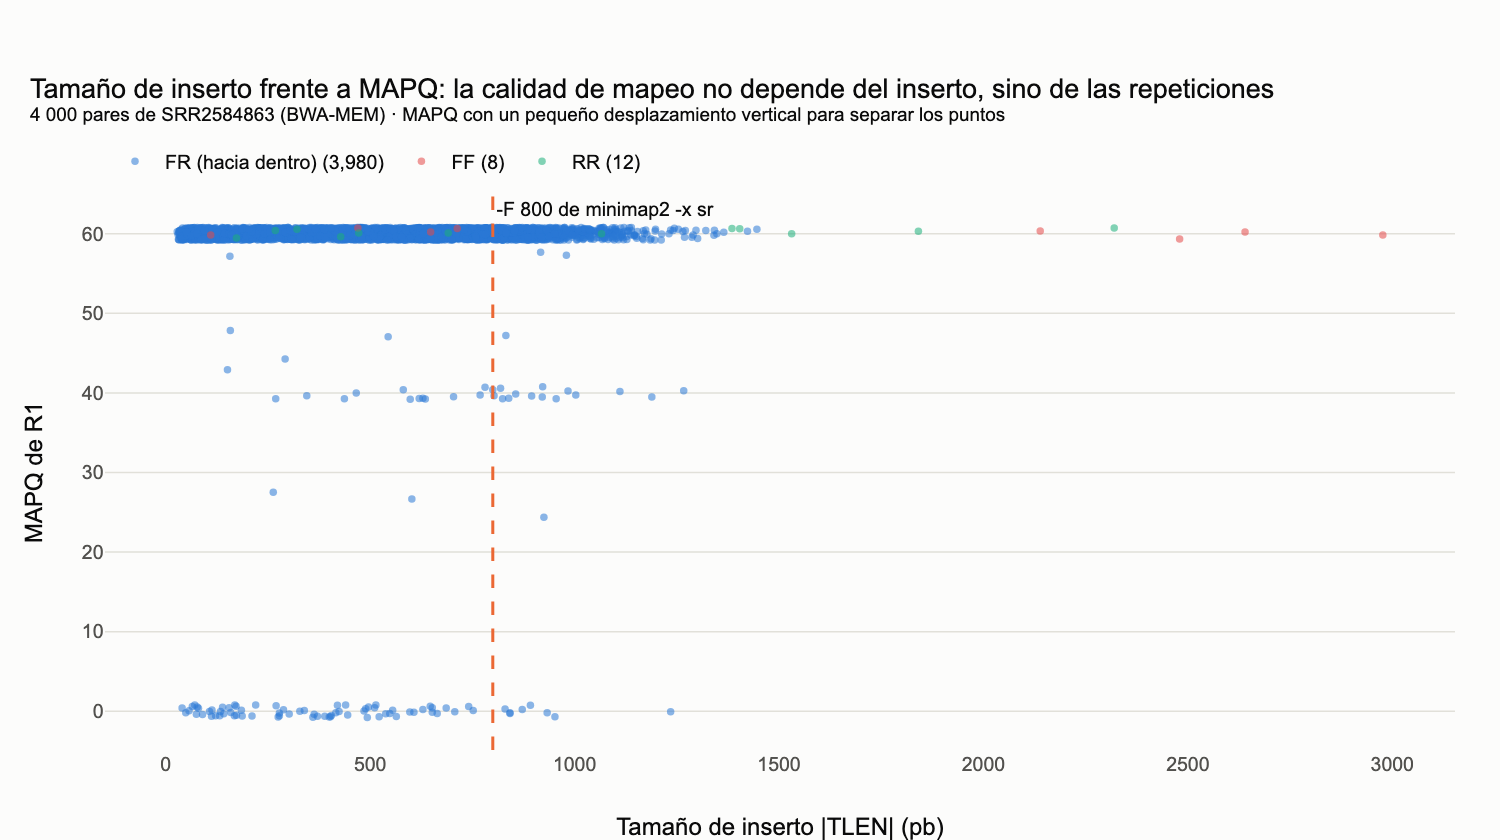

In [51]:
samp = r1[(r1.abs_tlen < 3000)].sample(min(4000, len(r1)), random_state=72)
samp = samp.assign(jmapq=samp.mapq + rng.uniform(-0.8, 0.8, len(samp)))
fig = go.Figure()
for o, col in [("FR (hacia dentro)", ec.BLUE), ("RF (hacia fuera)", ec.ORANGE), ("FF", ec.RED), ("RR", ec.AQUA)]:
    d = samp[samp.orient == o]
    if len(d) == 0:
        continue
    fig.add_scatter(x=d.abs_tlen, y=d.jmapq, mode="markers", name=f"{o} ({len(d):,})",
                    marker=dict(color=col, size=5, opacity=0.55),
                    customdata=np.column_stack([d.qname, d.pos, d.cigar, d.mapq, d.proper]),
                    hovertemplate="<b>%{customdata[0]}</b><br>posición %{customdata[1]:,} · CIGAR %{customdata[2]}"
                                  "<br>|TLEN| = %{x} pb · MAPQ = %{customdata[3]}<br>par propio: %{customdata[4]}<extra></extra>")
fig.add_vline(x=800, line=dict(color=ec.ORANGE, dash="dash"), annotation_text="-F 800 de minimap2 -x sr",
              annotation_position="top right")
fig.update_layout(
    title=dict(text="Tamaño de inserto frente a MAPQ: la calidad de mapeo no depende del inserto, sino de las repeticiones"
                    "<br><sup>4 000 pares de SRR2584863 (BWA-MEM) · MAPQ con un pequeño desplazamiento vertical para separar los puntos</sup>"),
    xaxis_title="Tamaño de inserto |TLEN| (pb)", yaxis_title="MAPQ de R1", height=560,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=70, r=30, b=60))
fig.show()

### 8.5 Errores y recortes por ciclo: la Lección 6.2 vista desde el BAM

Con la etiqueta `MD`, cada base alineada sabe si coincide con la referencia. Agrupando por **ciclo** obtenemos la tasa
de diferencias por posición de la lectura, y agrupando por **calidad Phred** podemos comprobar si las calidades del
secuenciador dicen la verdad: si $Q = 30$, deberíamos ver una diferencia cada 1 000 bases. Además contamos cuántas
bases recortó BWA-MEM en el extremo 3′ de cada lectura (`S` en la CIGAR).

Un detalle: una diferencia no siempre es un error de secuenciación; puede ser una **mutación real** del clon respecto
del ancestro. Pero el clon tiene, a lo sumo, unas decenas de mutaciones frente a más de 50 000 diferencias
observadas, así que su efecto es despreciable aquí.

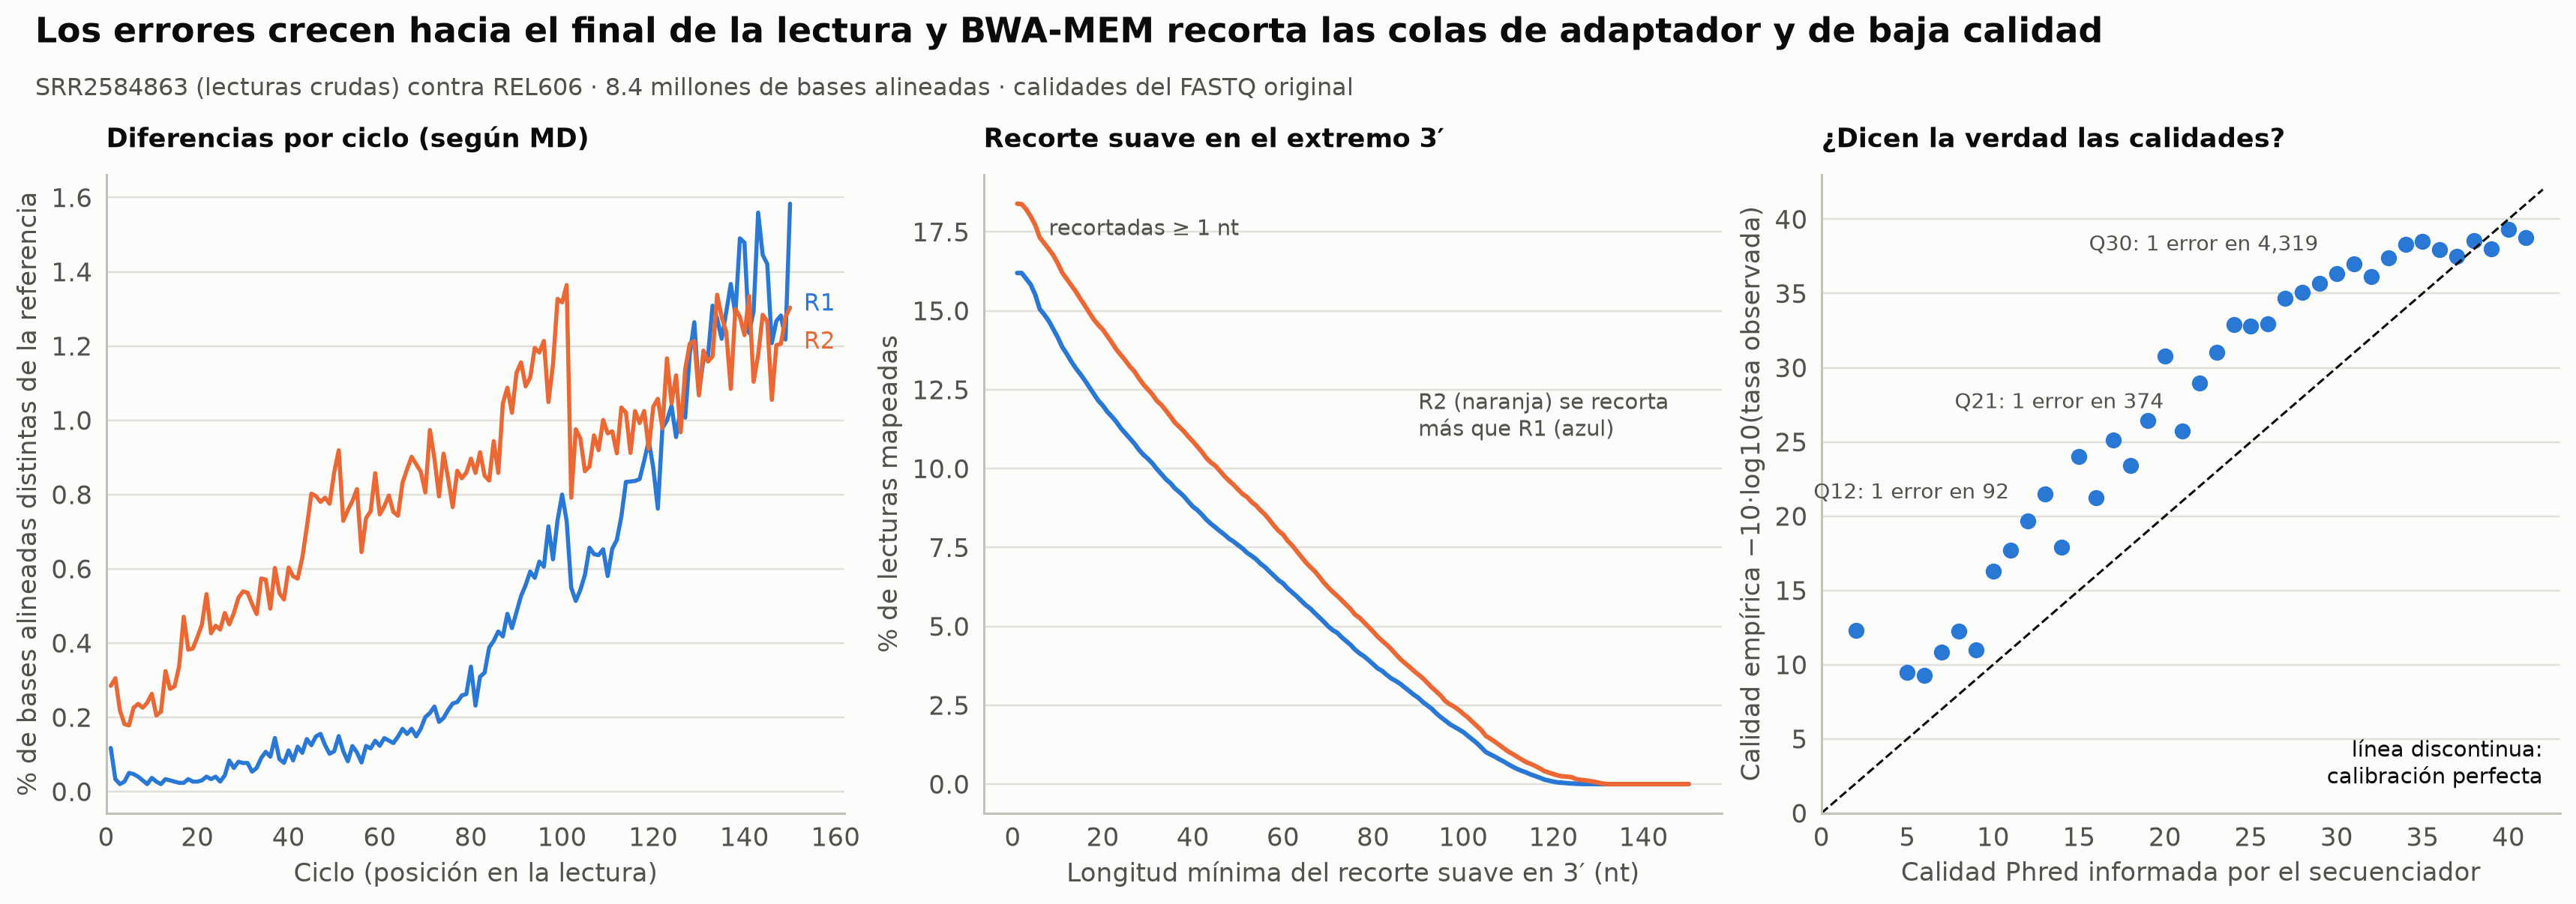

Tasa global de diferencias: 0.624% (samtools stats: 0.628%)


In [52]:
rate_cycle = mm_cycle / np.maximum(al_cycle, 1)
reads_mapped = aln[~aln.unmapped].groupby("mate").size()
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7))
ax = axes[0]
for m, col, lab in [(0, ec.BLUE, "R1"), (1, ec.ORANGE, "R2")]:
    ax.plot(np.arange(1, L + 1), 100 * rate_cycle[m], color=col, lw=1.8)
    ec.label_end(ax, L, 100 * rate_cycle[m][-5:].mean(), lab, col)
ax.set_xlabel("Ciclo (posición en la lectura)"); ax.set_ylabel("% de bases alineadas distintas de la referencia")
ax.set_xlim(0, L + 12)
ax.set_title("Diferencias por ciclo (según MD)", fontsize=11.5, loc="left")
ax = axes[1]
for m, col, lab in [(0, ec.BLUE, "R1"), (1, ec.ORANGE, "R2")]:
    n_m = reads_mapped["R1" if m == 0 else "R2"]
    frac_clipped = 100 * np.cumsum(clip3[m][::-1])[::-1][1:] / n_m      # % de lecturas con recorte 3′ ≥ c
    ax.plot(np.arange(1, L + 1), frac_clipped, color=col, lw=2)
ax.text(8, 100 * clip3[0][1:].sum() / reads_mapped["R1"] + 1.2, "recortadas ≥ 1 nt", fontsize=9.5, color=ec.INK_2)
ax.text(90, 0.6 * 100 * clip3[1][1:].sum() / reads_mapped["R2"], "R2 (naranja) se recorta\nmás que R1 (azul)", fontsize=9.5,
        color=ec.INK_2)
ax.set_xlabel("Longitud mínima del recorte suave en 3′ (nt)"); ax.set_ylabel("% de lecturas mapeadas")
ax.set_title("Recorte suave en el extremo 3′", fontsize=11.5, loc="left")
ax = axes[2]
okq = al_q > 2000
qs = np.arange(MAXQ)[okq]
obs = mm_q[okq] / al_q[okq]
ax.plot(qs, -10 * np.log10(np.maximum(obs, 1e-6)), "o", color=ec.BLUE, ms=6)
ax.plot([0, 42], [0, 42], color=ec.INK, ls="--", lw=1)
ax.text(42, 2, "línea discontinua:\ncalibración perfecta", fontsize=9.5, color=ec.INK, ha="right")
for qv, ov in zip(qs, obs):
    if qv in (12, 21, 30):
        ax.annotate(f"Q{qv}: 1 error en {1 / max(ov, 1e-6):,.0f}", (qv, -10 * np.log10(max(ov, 1e-6))), xytext=(-8, 10),
                    textcoords="offset points", fontsize=9, color=ec.INK_2, ha="right")
ax.set_xlabel("Calidad Phred informada por el secuenciador"); ax.set_ylabel("Calidad empírica −10·log10(tasa observada)")
ax.set_xlim(0, 43); ax.set_ylim(0, 43)
ax.set_title("¿Dicen la verdad las calidades?", fontsize=11.5, loc="left")
ec.fig_title(fig, "Los errores crecen hacia el final de la lectura y BWA-MEM recorta las colas de adaptador y de baja calidad",
             f"SRR2584863 (lecturas crudas) contra REL606 · {al_cycle.sum() / 1e6:.1f} millones de bases alineadas · calidades del FASTQ original")
plt.show()
print(f"Tasa global de diferencias: {mm_cycle.sum() / al_cycle.sum():.3%} (samtools stats: {SN['error rate']:.3%})")

> 🔎 **Qué observamos.** (1) La tasa de diferencias de R1 empieza por debajo de 0.1 % y la de R2 cerca de 0.3 %; las
> dos crecen a lo largo de la lectura hasta ≈ 1.2–1.5 % en los últimos ciclos: exactamente el perfil de calidad que
> vimos en la Lección 6.2, con R2 peor que R1. (2) Una fracción
> importante de las lecturas tiene recorte suave en 3′: son las colas de adaptador Nextera (*read-through* de insertos
> cortos) y las colas de `#` (Q2). BWA-MEM las deja fuera del alineamiento porque recortar cuesta sólo 5 puntos y
> alinearlas costaría mucho más. Por eso un buen mapeador local tolera lecturas sin limpiar, aunque limpiar sigue
> siendo recomendable para el conteo de bases y el llamado de variantes. (3) Las calidades Phred crecen con la
> calidad empírica, pero no coinciden con ella: todos los puntos quedan **por encima** de la diagonal, es decir, las
> bases alineadas se equivocan menos de lo que su calidad promete (Q21 promete 1 error en 126 y aquí hubo 1 en ~370).
> Parte del efecto es un sesgo de selección: las bases peores quedaron fuera del alineamiento por el recorte suave, y
> las que sobreviven son las "buenas" de cada calidad. Medir y corregir estas desviaciones es lo que hace la
> **recalibración de calidades de base** (BQSR) de GATK.

### 8.6 El perfil de cobertura a lo largo del genoma

Calculamos la profundidad base a base con NumPy: cada lectura suma $+1$ en su primera base alineada y $-1$ después de
la última; la suma acumulada da la profundidad (la misma idea de la Lección 6.3). Lo hacemos dos veces: con todas las
lecturas primarias y sólo con las de MAPQ ≥ 20.

Profundidad media: 1.81× (esperada 1.94× antes de recortes) · bases con profundidad 0: 20.1% (Poisson: e^-c = 16.3%)
Con MAPQ ≥ 20: 1.78× · bases con profundidad 0: 21.0%


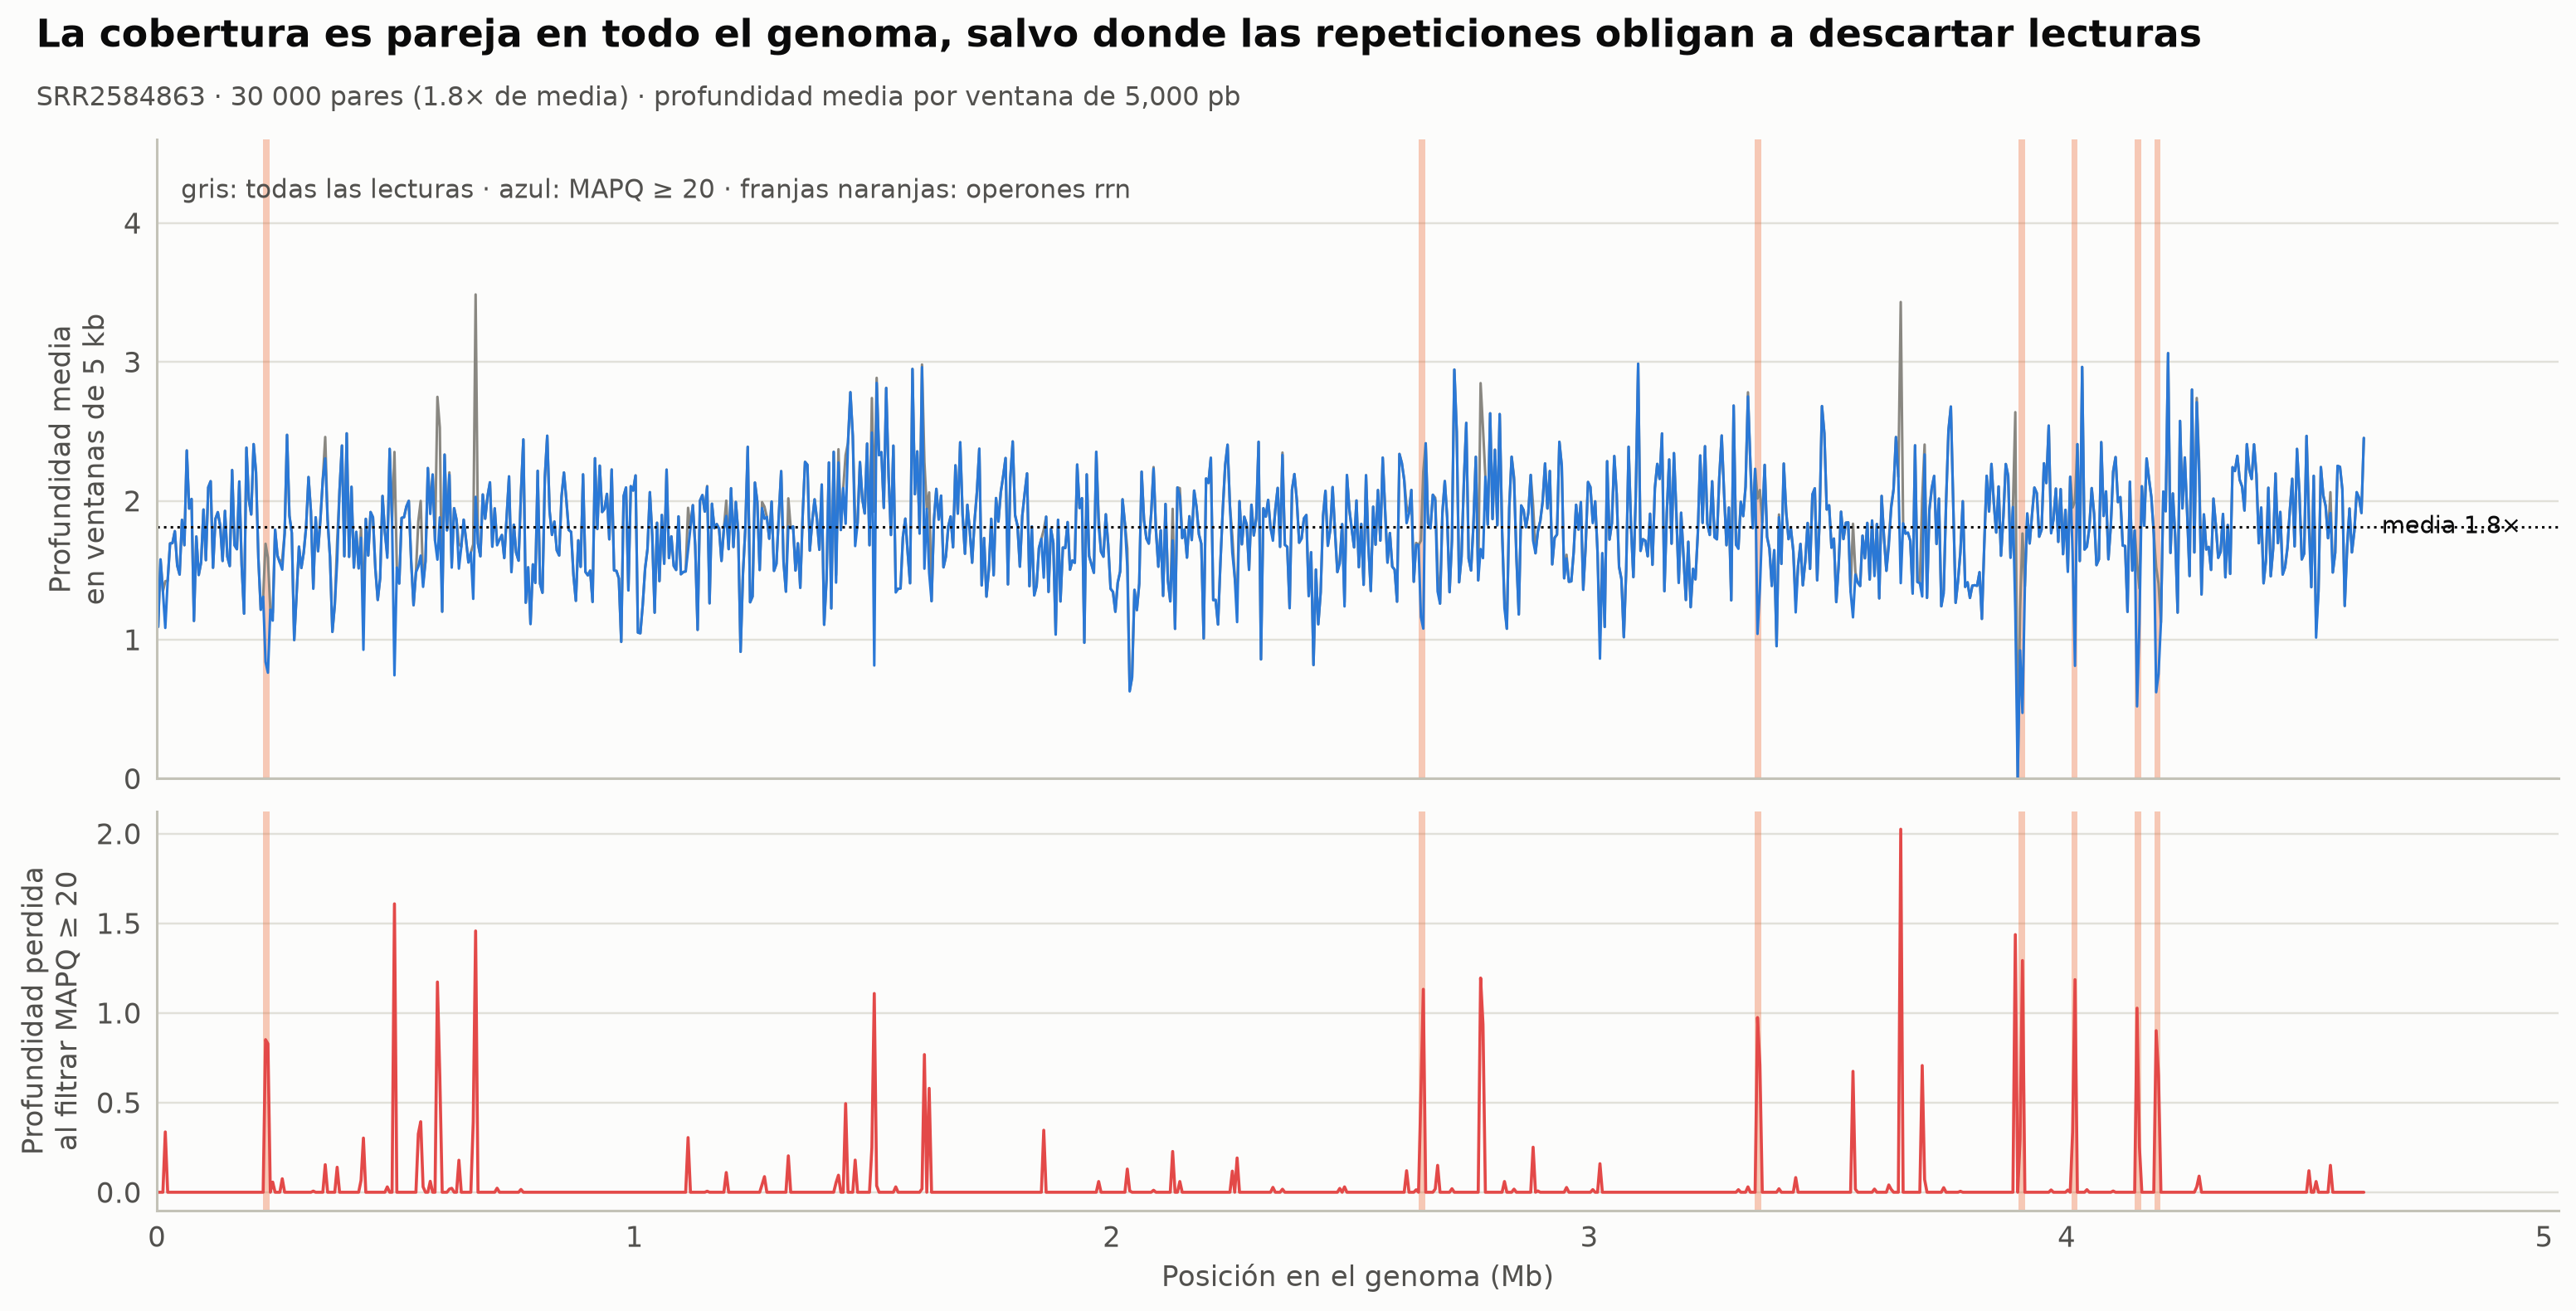

In [53]:
def depth_array(df):
    diff = np.zeros(G + 1, np.int32)
    np.add.at(diff, df.pos.values - 1, 1)
    np.add.at(diff, df.end.values, -1)
    return np.cumsum(diff[:-1])

mapped = aln[~aln.unmapped]
depth_all_g = depth_array(mapped)
depth_q20_g = depth_array(mapped[mapped.mapq >= 20])
c_mean = depth_all_g.mean()
print(f"Profundidad media: {c_mean:.2f}× (esperada {2 * len(seqs1) * L / G:.2f}× antes de recortes) · "
      f"bases con profundidad 0: {np.mean(depth_all_g == 0):.1%} (Poisson: e^-c = {np.exp(-c_mean):.1%})")
print(f"Con MAPQ ≥ 20: {depth_q20_g.mean():.2f}× · bases con profundidad 0: {np.mean(depth_q20_g == 0):.1%}")

BIN = 5000
nb_ = G // BIN
bin_all = depth_all_g[:nb_ * BIN].reshape(nb_, BIN).mean(1)
bin_q20 = depth_q20_g[:nb_ * BIN].reshape(nb_, BIN).mean(1)
xb = (np.arange(nb_) + 0.5) * BIN / 1e6
fig, axes = plt.subplots(2, 1, figsize=(14, 6.4), gridspec_kw=dict(height_ratios=[1.6, 1]), sharex=True)
ax = axes[0]
ax.plot(xb, bin_all, color=ec.MUTED, lw=1)
ax.plot(xb, bin_q20, color=ec.BLUE, lw=1)
for s, e in zip(operons.start, operons.end):
    ax.axvspan(s / 1e6 - 0.004, e / 1e6 + 0.004, color=ec.ORANGE, alpha=0.35, lw=0)
ax.axhline(c_mean, color=ec.INK, ls=":", lw=1)
ax.text(G / 1e6 + 0.03, c_mean, f"media {c_mean:.1f}×", va="center", fontsize=9.5)
ax.text(0.01, 0.94, "gris: todas las lecturas · azul: MAPQ ≥ 20 · franjas naranjas: operones rrn",
        transform=ax.transAxes, fontsize=10, color=ec.INK_2, va="top")
ax.set_ylabel(f"Profundidad media\nen ventanas de {BIN // 1000} kb")
ax.set_ylim(0, max(bin_all.max(), 4) * 1.15)
ax = axes[1]
ax.plot(xb, bin_all - bin_q20, color=ec.RED, lw=1.2)
for s, e in zip(operons.start, operons.end):
    ax.axvspan(s / 1e6 - 0.004, e / 1e6 + 0.004, color=ec.ORANGE, alpha=0.35, lw=0)
ax.set_ylabel("Profundidad perdida\nal filtrar MAPQ ≥ 20")
ax.set_xlabel("Posición en el genoma (Mb)"); ax.set_xlim(0, G / 1e6 + 0.4)
ec.fig_title(fig, "La cobertura es pareja en todo el genoma, salvo donde las repeticiones obligan a descartar lecturas",
             f"SRR2584863 · 30 000 pares ({c_mean:.1f}× de media) · profundidad media por ventana de {BIN:,} pb")
plt.show()

> 🔎 **Qué observamos.** Con solo ≈ 1.8× de profundidad media, la cobertura por ventana de 5 kb fluctúa, pero no hay
> grandes huecos: el mapeo contra la referencia correcta cubre todo el genoma. El panel de abajo muestra dónde se pierde
> profundidad al exigir MAPQ ≥ 20: picos que coinciden con los siete operones *rrn* y con otros picos más pequeños (las
> copias de IS). En una ventana de 5 kb que contiene un operón completo, casi toda la profundidad desaparece. Con la
> profundidad baja de este submuestreo, la fracción de bases sin cobertura (≈ 20 %) es algo mayor que la que predice la
> estadística de Lander–Waterman de la Lección 6.3 ($e^{-c} \approx 16$ %): las lecturas de un par no caen de forma
> independiente y la biblioteca real no es perfectamente uniforme.

El siguiente gráfico interactivo permite recorrer el genoma con **zoom** (arrastre sobre el eje) y ver, en ventanas de
2 kb, la profundidad con y sin filtro, la MAPQ media y los genes de cada ventana.

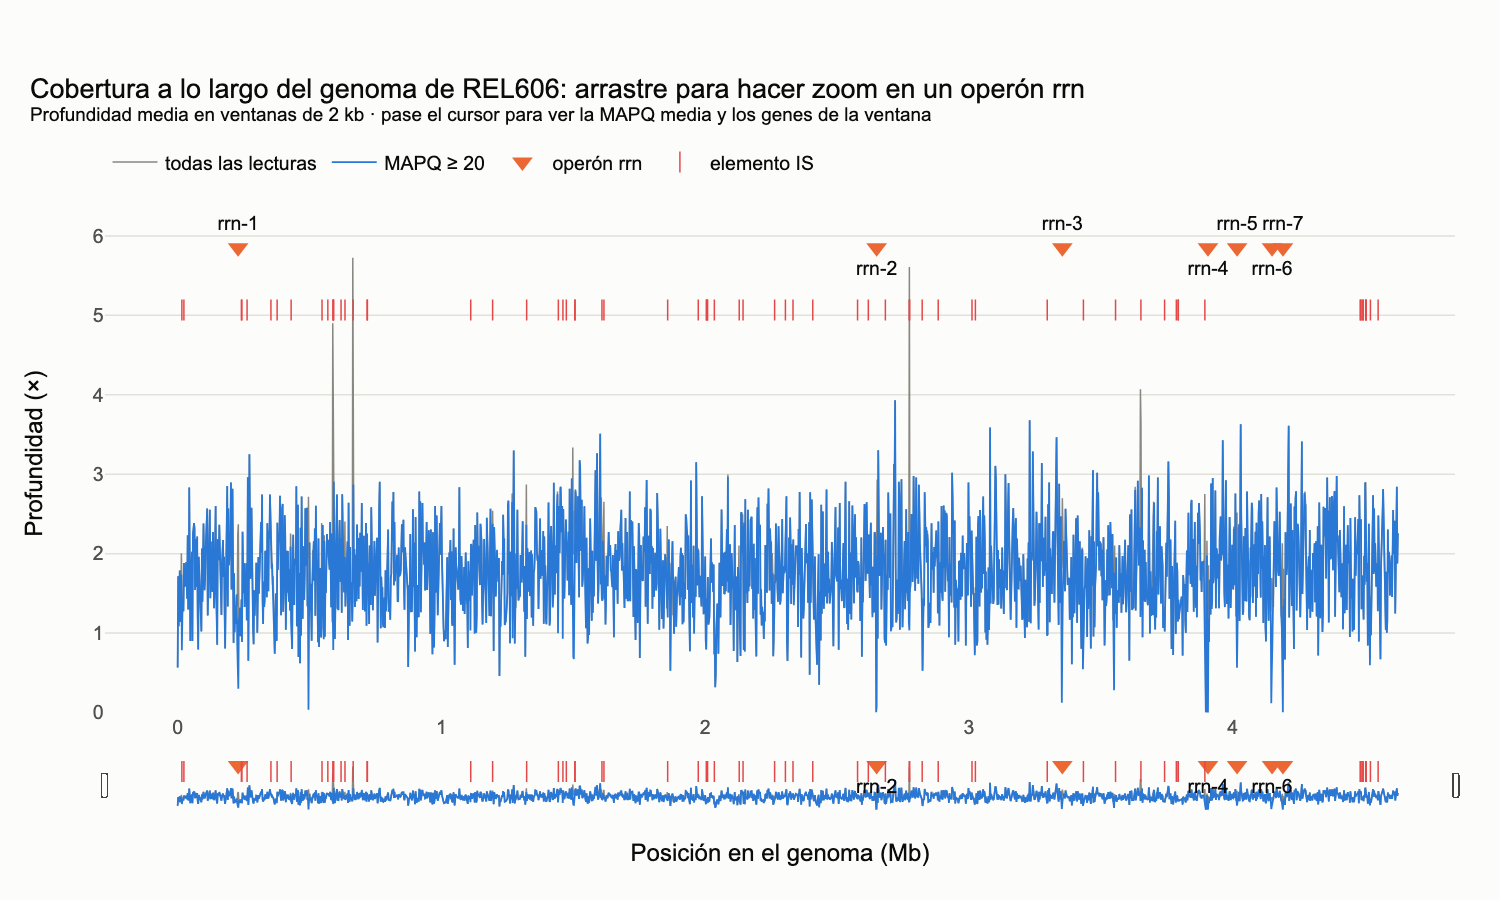

In [54]:
BIN2 = 2000
nb2 = G // BIN2
b_all = depth_all_g[:nb2 * BIN2].reshape(nb2, BIN2).mean(1)
b_q20 = depth_q20_g[:nb2 * BIN2].reshape(nb2, BIN2).mean(1)
bin_idx = np.clip((mapped.pos.values - 1) // BIN2, 0, nb2 - 1)
mq_sum = np.bincount(bin_idx, weights=mapped.mapq.values, minlength=nb2)
mq_n = np.bincount(bin_idx, minlength=nb2)
mq_mean = np.where(mq_n > 0, mq_sum / np.maximum(mq_n, 1), np.nan)
genes_bin = [[] for _ in range(nb2)]
named = feat[feat.type.isin(["CDS", "rRNA", "tRNA"])]
for s, e, gname, prod, t in zip(named.start, named.end, named.gene, named["product"], named.type):
    label = gname if isinstance(gname, str) and gname else (prod[:28] if t != "CDS" or "IS" in prod else "")
    if label:
        for b in range((s - 1) // BIN2, min(nb2 - 1, (e - 1) // BIN2) + 1):
            if len(genes_bin[b]) < 4:
                genes_bin[b].append(label)
genes_txt = [", ".join(g) if g else "—" for g in genes_bin]
xs2 = (np.arange(nb2) * BIN2 + 1)
cd = np.column_stack([xs2, xs2 + BIN2 - 1, b_all, b_q20, np.nan_to_num(mq_mean, nan=-1), genes_txt])
hover = ("ventana %{customdata[0]:,}–%{customdata[1]:,}<br>profundidad: %{customdata[2]:.2f}× · MAPQ ≥ 20: "
         "%{customdata[3]:.2f}×<br>MAPQ media: %{customdata[4]:.1f}<br>genes: %{customdata[5]}<extra></extra>")
fig = go.Figure()
fig.add_scatter(x=xs2 / 1e6, y=b_all, mode="lines", name="todas las lecturas", line=dict(color=ec.MUTED, width=1),
                customdata=cd, hovertemplate=hover)
fig.add_scatter(x=xs2 / 1e6, y=b_q20, mode="lines", name="MAPQ ≥ 20", line=dict(color=ec.BLUE, width=1.2),
                customdata=cd, hovertemplate=hover)
ymax = float(np.percentile(b_all, 99.9)) * 1.3
fig.add_scatter(x=(operons.start + operons.end) / 2e6, y=[ymax * 0.97] * len(operons), mode="markers+text",
                marker=dict(symbol="triangle-down", size=12, color=ec.ORANGE), text=operons.name,
                textposition=["top center" if i % 2 == 0 else "bottom center" for i in range(len(operons))],
                name="operón rrn", hovertext=[f"{n}: {s:,}–{e:,} ({st})" for n, s, e, st in
                zip(operons.name, operons.start, operons.end, operons.strand)], hoverinfo="text")
isx = (is_elems.start + is_elems.end) / 2e6
fig.add_scatter(x=isx, y=[ymax * 0.84] * len(is_elems), mode="markers", marker=dict(symbol="line-ns-open", size=10,
                color=ec.RED), name="elemento IS", hovertext=[f"{p} · {s:,}–{e:,}" for p, s, e in
                zip(is_elems["product"], is_elems.start, is_elems.end)], hoverinfo="text")
fig.update_layout(
    title=dict(text="Cobertura a lo largo del genoma de REL606: arrastre para hacer zoom en un operón rrn"
                    "<br><sup>Profundidad media en ventanas de 2 kb · pase el cursor para ver la MAPQ media y los genes de la ventana</sup>"),
    xaxis=dict(title="Posición en el genoma (Mb)", rangeslider=dict(visible=True, thickness=0.08)),
    yaxis=dict(title="Profundidad (×)", range=[0, ymax * 1.08]), height=600,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=130, l=70, r=30, b=60))
fig.show()

## 9. BWA-MEM vs minimap2 vs nuestro mapeador

Tenemos tres mapeos de las mismas lecturas. Comparémoslos con los criterios que importan en la práctica: tiempo,
fracción mapeada, pares propios, lecturas ambiguas y, sobre todo, **si ponen cada lectura en el mismo sitio**.

> 🤔 **Antes de ejecutar, prediga.** ¿En qué lecturas cree que BWA-MEM y minimap2 van a discrepar?

In [55]:
def summarize(df, name, seconds):
    p = df[(df.flag & 0x900) == 0]                                # primarios
    mp = p[(p.flag & 0x4) == 0]
    return {"mapeador": name, "tiempo (s)": round(seconds, 2),
            "% mapeadas": 100 * len(mp) / len(p),
            "% pares propios": 100 * np.mean((p.flag & 0x2) > 0),
            "% MAPQ 0": 100 * np.mean(mp.mapq == 0),
            "% diferencias (NM/bases)": 100 * mp.NM.sum() / mp.cigar.map(
                lambda c: sum(int(n) for n, op in re.findall(r"(\d+)([MI])", c))).sum()}

bwa_tab = aln.assign(flag=aln.flag)[["qname", "flag", "pos", "mapq", "cigar", "NM", "AS", "XS"]]
comp = pd.DataFrame([summarize(bwa_tab, "BWA-MEM", timing["bwa mem"]),
                     summarize(mm2, "minimap2 -x sr", timing["minimap2 -ax sr"])]).set_index("mapeador")
comp.round(2)

,tiempo (s),% mapeadas,% pares propios,% MAPQ 0,% diferencias (NM/bases)
mapeador,,,,,
BWA-MEM,1.16,99.34,96.94,1.96,0.63
minimap2 -x sr,0.54,97.26,73.00,2.07,0.54


In [56]:
key = lambda df: df.qname + np.where((df.flag & 0x40) > 0, "/1", "/2")

def unclipped_start(pos, cigar):
    """Posición donde empezaría la lectura si no se hubiera recortado su extremo izquierdo (POS − recorte suave)."""
    m = re.match(r"(\d+)S", cigar) if isinstance(cigar, str) else None
    return pos - (int(m.group(1)) if m else 0)

b_ = bwa_tab[(bwa_tab.flag & 0x900) == 0].assign(k=lambda d: key(d)).set_index("k")
m2 = mm2[(mm2.flag & 0x900) == 0].assign(k=lambda d: key(d)).set_index("k")
both = b_.join(m2, lsuffix="_bwa", rsuffix="_mm2", how="inner")
both_mapped = both[((both.flag_bwa & 4) == 0) & ((both.flag_mm2 & 4) == 0)]
us_bwa = [unclipped_start(p, c) for p, c in zip(both_mapped.pos_bwa, both_mapped.cigar_bwa)]
us_mm2 = [unclipped_start(p, c) for p, c in zip(both_mapped.pos_mm2, both_mapped.cigar_mm2)]
same = pd.Series(np.abs(np.array(us_bwa) - np.array(us_mm2)) <= 5, index=both_mapped.index)
print(f"Lecturas mapeadas por ambos: {len(both_mapped):,} · misma posición (±5 pb): {same.mean():.2%}")
disc = both_mapped[~same]
print(f"Discrepantes: {len(disc):,} · con MAPQ 0 en BWA o en minimap2: {np.mean((disc.mapq_bwa == 0) | (disc.mapq_mm2 == 0)):.1%}")
only_bwa = both[((both.flag_bwa & 4) == 0) & ((both.flag_mm2 & 4) > 0)]
aligned_len = only_bwa.cigar_bwa.map(lambda c: sum(int(n) for n, op in re.findall(r"(\d+)([M])", c)))
print(f"Mapeadas sólo por BWA-MEM: {len(only_bwa):,} · mediana de bases alineadas por BWA: {aligned_len.median():.0f} de {L}")

# pares propios: ¿por qué minimap2 marca menos?
pp = both[(both.flag_bwa & 0x40) > 0]
lost = pp[((pp.flag_bwa & 2) > 0) & ((pp.flag_mm2 & 2) == 0)]
tl_ = aln.set_index(key(aln))["tlen"].abs()
print(f"Pares propios en BWA pero no en minimap2: {len(lost):,} · con |TLEN| > 800 pb: "
      f"{np.mean(tl_.reindex(lost.index) > 800):.1%}")

Lecturas mapeadas por ambos: 58,355 · misma posición (±5 pb): 98.23%
Discrepantes: 1,035 · con MAPQ 0 en BWA o en minimap2: 93.8%
Mapeadas sólo por BWA-MEM: 1,247 · mediana de bases alineadas por BWA: 82 de 150
Pares propios en BWA pero no en minimap2: 7,215 · con |TLEN| > 800 pb: 77.1%


In [57]:
# nuestro mapeador (R1, primeras 1 000 lecturas) frente a BWA-MEM
tb = toy.assign(k=toy.qname + "/1").set_index("k").join(b_[["pos", "mapq", "cigar", "flag"]])
tb_ok = tb[tb.toy_pos.notna() & ((tb.flag & 4) == 0)]
raw_same = (tb_ok.toy_pos - tb_ok.pos).abs() <= 5
us_toy = np.array([unclipped_start(p, c) for p, c in zip(tb_ok.toy_pos, tb_ok.toy_cigar)])
us_b = np.array([unclipped_start(p, c) for p, c in zip(tb_ok.pos, tb_ok.cigar)])
same_toy = pd.Series(np.abs(us_toy - us_b) <= 5, index=tb_ok.index)
print(f"Comparando POS tal cual: {raw_same.mean():.1%} · comparando el inicio sin recorte (POS − S inicial): {same_toy.mean():.1%}")
ej = tb_ok[~raw_same & same_toy].head(3)
print("Ejemplos en los que sólo cambia el recorte:\n", ej[["toy_pos", "toy_cigar", "toy_score", "pos", "cigar"]].to_string())
print(f"Mapeador de juguete vs BWA-MEM: {same_toy.mean():.1%} en la misma posición ({same_toy.sum()} de {len(tb_ok)})")
print("Discrepantes, MAPQ de BWA:", tb_ok.loc[~same_toy, "mapq"].value_counts().to_dict())
cross = pd.crosstab(pd.cut(tb_ok.mapq, [-1, 0, 19, 60], labels=["BWA 0", "BWA 1–19", "BWA ≥ 20"]),
                    pd.cut(tb_ok.toy_mapq, [-1, 3, 19, 60], labels=["juguete ≤ 3", "juguete 4–19", "juguete ≥ 20"]))
cross

Comparando POS tal cual: 97.1% · comparando el inicio sin recorte (POS − S inicial): 98.0%
Ejemplos en los que sólo cambia el recorte:
                   toy_pos toy_cigar  toy_score      pos   cigar
k                                                              
SRR2584863.161/1  1462184  6S139M5S        134  1462178  145M5S
SRR2584863.240/1   946873   27S123M        123   946846    150M
SRR2584863.277/1  2517034   10S140M        135  2517024    150M
Mapeador de juguete vs BWA-MEM: 98.0% en la misma posición (980 de 1000)
Discrepantes, MAPQ de BWA: {0: 18, 27: 1, 40: 1}


toy_mapq,juguete ≤ 3,juguete 4–19,juguete ≥ 20
mapq,,,
BWA 0,21,0,0
BWA 1–19,0,0,1
BWA ≥ 20,3,1,974


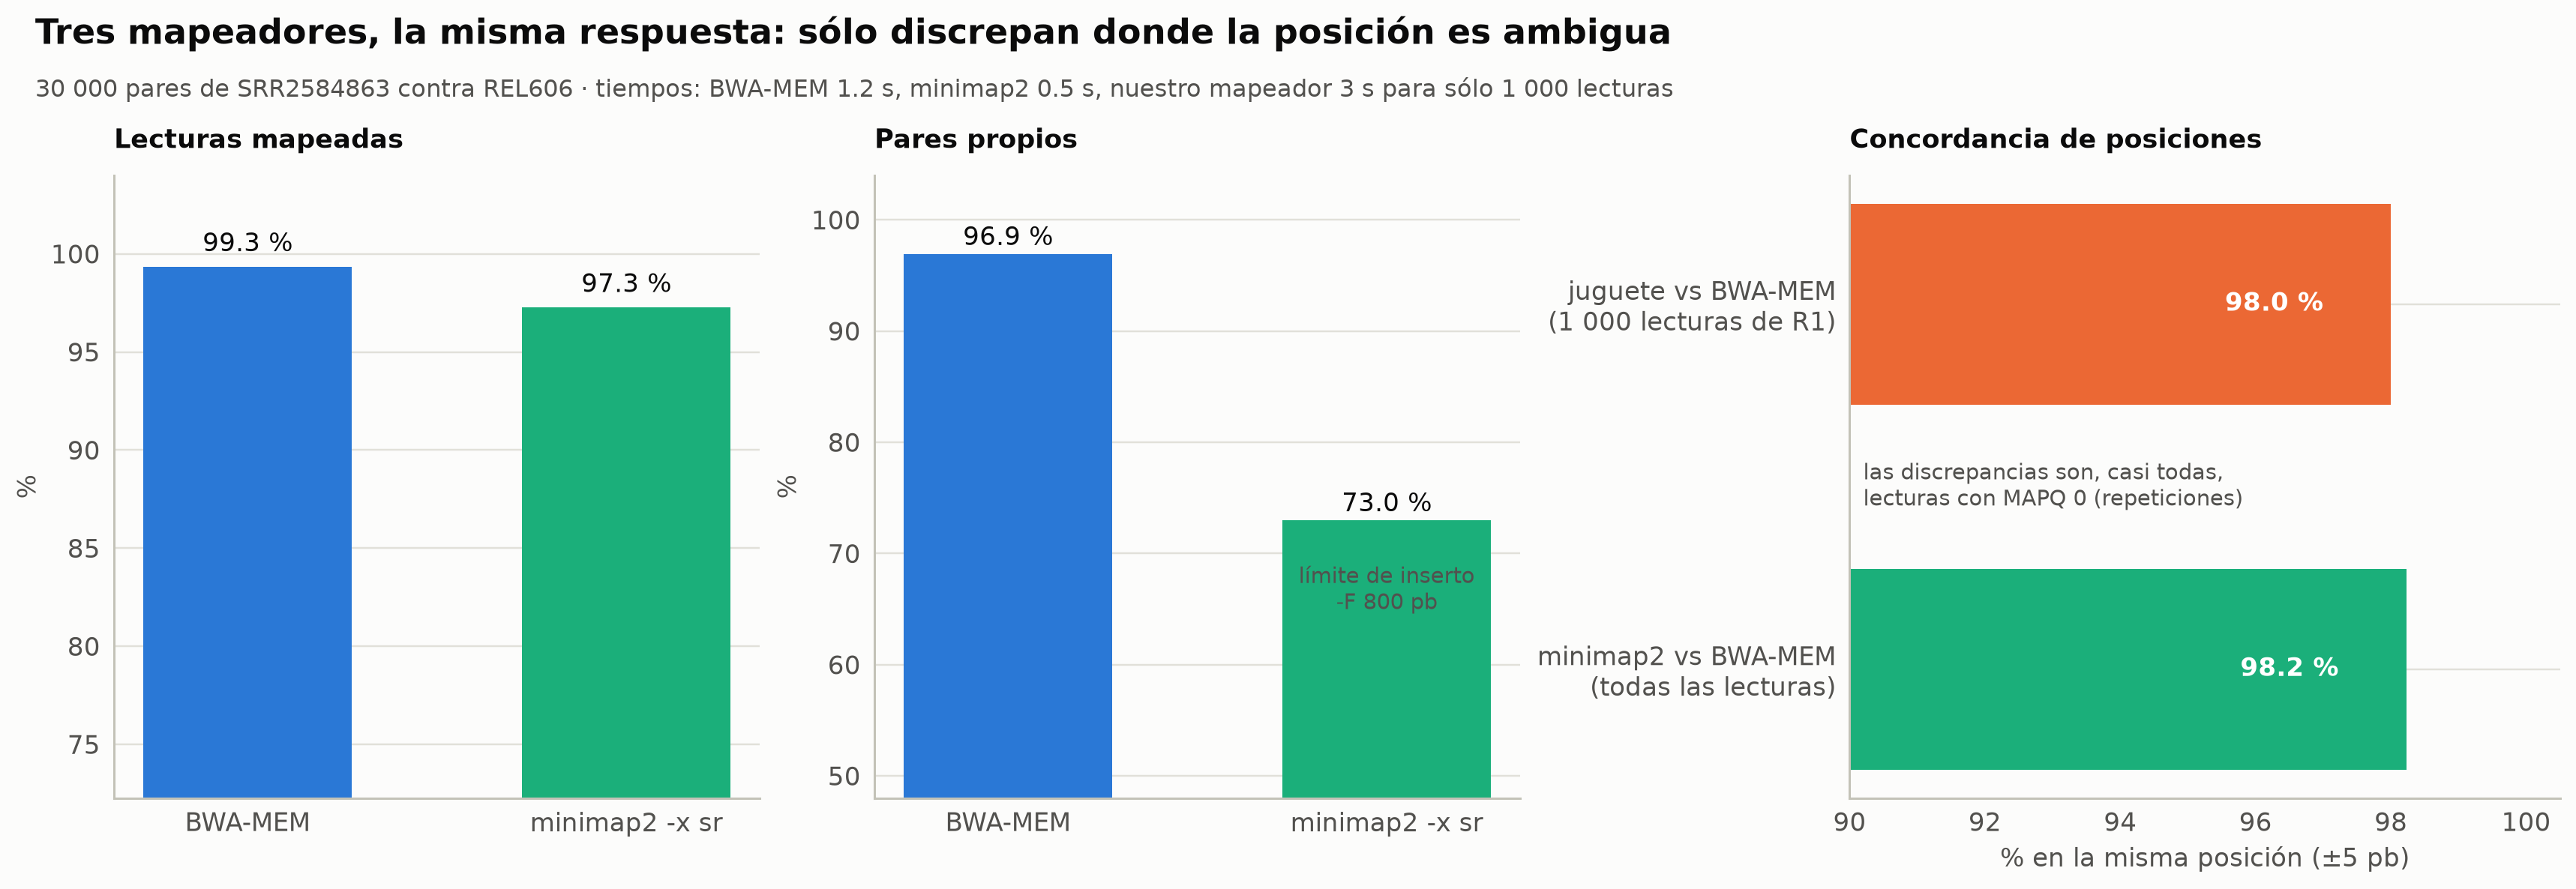

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), gridspec_kw=dict(width_ratios=[1, 1, 1.1]))
names_ = ["BWA-MEM", "minimap2 -x sr"]
for ax, col_name, title_ in [(axes[0], "% mapeadas", "Lecturas mapeadas"), (axes[1], "% pares propios", "Pares propios")]:
    vals = comp[col_name].values
    ax.bar(names_, vals, color=[ec.BLUE, ec.AQUA], width=0.55)
    for i_, v_ in enumerate(vals):
        ax.text(i_, v_ + 0.8, f"{v_:.1f} %", ha="center", fontsize=11)
    ax.set_ylim(min(vals) - 25, 104)
    ax.set_ylabel("%")
    ax.set_title(title_, fontsize=11.5, loc="left")
axes[1].text(1, comp["% pares propios"].iloc[1] - 8, "límite de inserto\n-F 800 pb", ha="center", fontsize=9.5,
             color=ec.INK_2)
ax = axes[2]
agree = [100 * same.mean(), 100 * same_toy.mean()]
ax.barh([0, 1], agree, color=[ec.AQUA, ec.ORANGE], height=0.55)
for i_, v_ in enumerate(agree):
    ax.text(v_ - 1, i_, f"{v_:.1f} %", ha="right", va="center", color="white", fontsize=11, fontweight="bold")
ax.set_yticks([0, 1], ["minimap2 vs BWA-MEM\n(todas las lecturas)", "juguete vs BWA-MEM\n(1 000 lecturas de R1)"])
ax.set_xlim(90, 100.5); ax.set_xlabel("% en la misma posición (±5 pb)")
ax.text(90.2, 0.5, "las discrepancias son, casi todas,\nlecturas con MAPQ 0 (repeticiones)", fontsize=9.5,
        color=ec.INK_2, va="center")
ax.set_title("Concordancia de posiciones", fontsize=11.5, loc="left")
ec.fig_title(fig, "Tres mapeadores, la misma respuesta: sólo discrepan donde la posición es ambigua",
             f"30 000 pares de SRR2584863 contra REL606 · tiempos: BWA-MEM {timing['bwa mem']:.1f} s, "
             f"minimap2 {timing['minimap2 -ax sr']:.1f} s, nuestro mapeador {t_toy:.0f} s para sólo 1 000 lecturas")
plt.show()

> 🔎 **Qué observamos.**
>
> * **Posiciones.** BWA-MEM y minimap2 ponen más del 98 % de las lecturas en el mismo sitio, y casi todas las
>   discrepancias son lecturas con MAPQ 0: los dos mapeadores eligieron **copias distintas** de la misma repetición, y
>   ambos avisaron de que no estaban seguros. (Comparamos el inicio **sin recorte**, POS menos el `S` inicial, porque dos
>   mapeadores pueden colocar la lectura en la misma diagonal y recortar distinto su extremo.)
> * **Nuestro mapeador.** Comparando POS tal cual, coincide con BWA-MEM en ≈ 97 %; casi todas las "discrepancias" con
>   MAPQ 60 son la misma diagonal con otro recorte: nuestro Smith–Waterman local corta el extremo en cuanto una
>   diferencia lo hace rentable (`27S123M`, puntuación 123), mientras que BWA-MEM cobra 5 puntos por recortar y, a igual
>   puntuación, prefiere llegar hasta el final (`150M`, `AS` 123). Con el inicio sin recorte, la concordancia sube a
>   ≈ 98 % y lo que queda son lecturas multimapeadas, en las que BWA-MEM a veces rescata la posición con ayuda del
>   compañero y nuestro mapeador, que mira cada lectura por separado, no puede.
> * **Fracción mapeada.** minimap2 deja sin mapear algo más de lecturas. Mirando qué hizo BWA-MEM con ellas, la mediana
>   de bases alineadas es de apenas ~80 de 150: son lecturas con mucho adaptador o de muy baja calidad, en las que
>   BWA-MEM encuentra un alineamiento local corto y minimap2 no alcanza su puntuación mínima de cadena.
> * **Pares propios.** La gran diferencia (≈ 97 % frente a ≈ 73 %) **no** es un fallo de minimap2: con `-x sr`,
>   minimap2 sólo considera propio un par con fragmento ≤ 800 pb (opción `-F`), mientras que BWA-MEM **estima** el
>   límite a partir de los propios datos (≈ 2 180 pb aquí). Casi todos los pares que BWA-MEM marca como propios y
>   minimap2 no tienen |TLEN| > 800 pb: la biblioteca Nextera tiene insertos largos. Con `-F 2000` la diferencia
>   desaparecería. Leer los valores por defecto de una herramienta es parte del análisis.
> * **Velocidad.** Con lecturas cortas, minimap2 es algo más rápido que BWA-MEM; ambos, varios órdenes de magnitud más
>   rápidos que nuestro mapeador en Python, que hace el mismo trabajo lectura por lectura.

> ✅ **Compruebe su comprensión.** Un colega le dice: "minimap2 es peor para lecturas cortas porque sólo el 73 % de los
> pares son propios". ¿Qué le respondería y cómo lo comprobaría?
>
> *Respuesta:* Que la diferencia viene del límite de fragmento por defecto (`-F 800`) y no de la calidad del mapeo;
> lo comprobaría mirando la distribución de |TLEN| de los pares afectados (casi todos > 800 pb) o repitiendo el mapeo
> con `minimap2 -ax sr -F 2000`.

## 10. Lecturas largas: cuando la lectura es más larga que la repetición

Ningún algoritmo puede decidir de qué copia viene una lectura de 150 nt que es idéntica en siete copias. La única
solución es **leer más lejos**: una lectura que empieza en secuencia única, atraviesa el operón completo (≈ 5 kb) y
termina en secuencia única tiene **un solo** lugar posible. Esa es la gran ventaja de las lecturas largas de
nanoporo y PacBio (Lección 6.1) para resolver repeticiones, a pesar de sus errores.

Las lecturas largas simuladas se generaron con estas funciones (errores independientes de sustitución, inserción y
deleción en cada base; ≈ 2 % + 1.5 % + 1.5 %):

In [59]:
def add_errors(seq, r, p_sub, p_ins, p_del):
    """Introduce sustituciones, inserciones y deleciones independientes en cada posición."""
    out = []
    u = r.random((len(seq), 3))
    for i, b in enumerate(seq):
        if u[i, 2] < p_del:
            continue
        if u[i, 0] < p_sub:
            b = "ACGT"[("ACGT".index(b) + r.integers(1, 4)) % 4] if b in "ACGT" else b
        out.append(b)
        if u[i, 1] < p_ins:
            out.append("ACGT"[r.integers(4)])
    return "".join(out)

def simulate_long(genome, starts, lengths, r, p_sub=0.02, p_ins=0.015, p_del=0.015):
    """Lecturas largas tipo nanoporo (≈ 5 % de error) con la verdad en el nombre: lr<i>_<inicio>_<fin>_<hebra>."""
    reads = []
    for i, (s, Lr) in enumerate(zip(starts, lengths)):
        s = int(min(max(s, 0), len(genome) - Lr))
        frag = genome[s:s + Lr]
        strand = "+" if r.random() < 0.5 else "-"
        if strand == "-":
            frag = revcomp(frag)
        reads.append((f"lr{i}_{s + 1}_{s + Lr}_{strand}", add_errors(frag, r, p_sub, p_ins, p_del)))
    return reads

# un ejemplo pequeño para ver el efecto de los errores
ex_read = simulate_long(genome, [226_000], [60], np.random.default_rng(1))[0]
print("original:", genome[226_000:226_060]); print("simulada:", ex_read[1], "·", ex_read[0])

long_names = [l[1:].strip() for l in gzip.decompress(course_bytes("sim_REL606_long.fasta.gz")).decode().splitlines()
              if l.startswith(">")]
print(f"\nLecturas largas del curso: {len(long_names)}")

original: GTAAACCACATCCGGGGATGCTTTTGTCAGCACGCGATTATTTGCATATTGATATGGCCG
simulada: CGGCCATATCAATATGCAAAGAATCGCGTGTGACAAAAGCATCCCCGGATGTGGTTTAC · lr0_226001_226060_-

Lecturas largas del curso: 148


In [60]:
paf["true_start"] = paf.qname.str.split("_").str[1].astype(int)
paf["true_end"] = paf.qname.str.split("_").str[2].astype(int)
paf["identity"] = paf.nmatch / paf.alen
paf["correct"] = (paf.tstart + 1 - paf.true_start).abs() < 200
paf["spans_rrn"] = [any((s <= o.start - 200) and (e >= o.end + 200) for o in operons.itertuples())
                    for s, e in zip(paf.true_start, paf.true_end)]
print(f"Mapeadas: {len(paf)} de {len(long_names)} · en la posición correcta: {paf.correct.mean():.0%} · "
      f"identidad media: {paf.identity.mean():.1%}")
print(paf.groupby("spans_rrn").agg(lecturas=("qname", "size"), mapq_media=("mapq", "mean"),
                                   mapq_min=("mapq", "min"), correctas=("correct", "mean")))

Mapeadas: 148 de 148 · en la posición correcta: 100% · identidad media: 95.2%
           lecturas  mapq_media  mapq_min  correctas
spans_rrn                                           
False           120        60.0        60        1.0
True             28        60.0        60        1.0


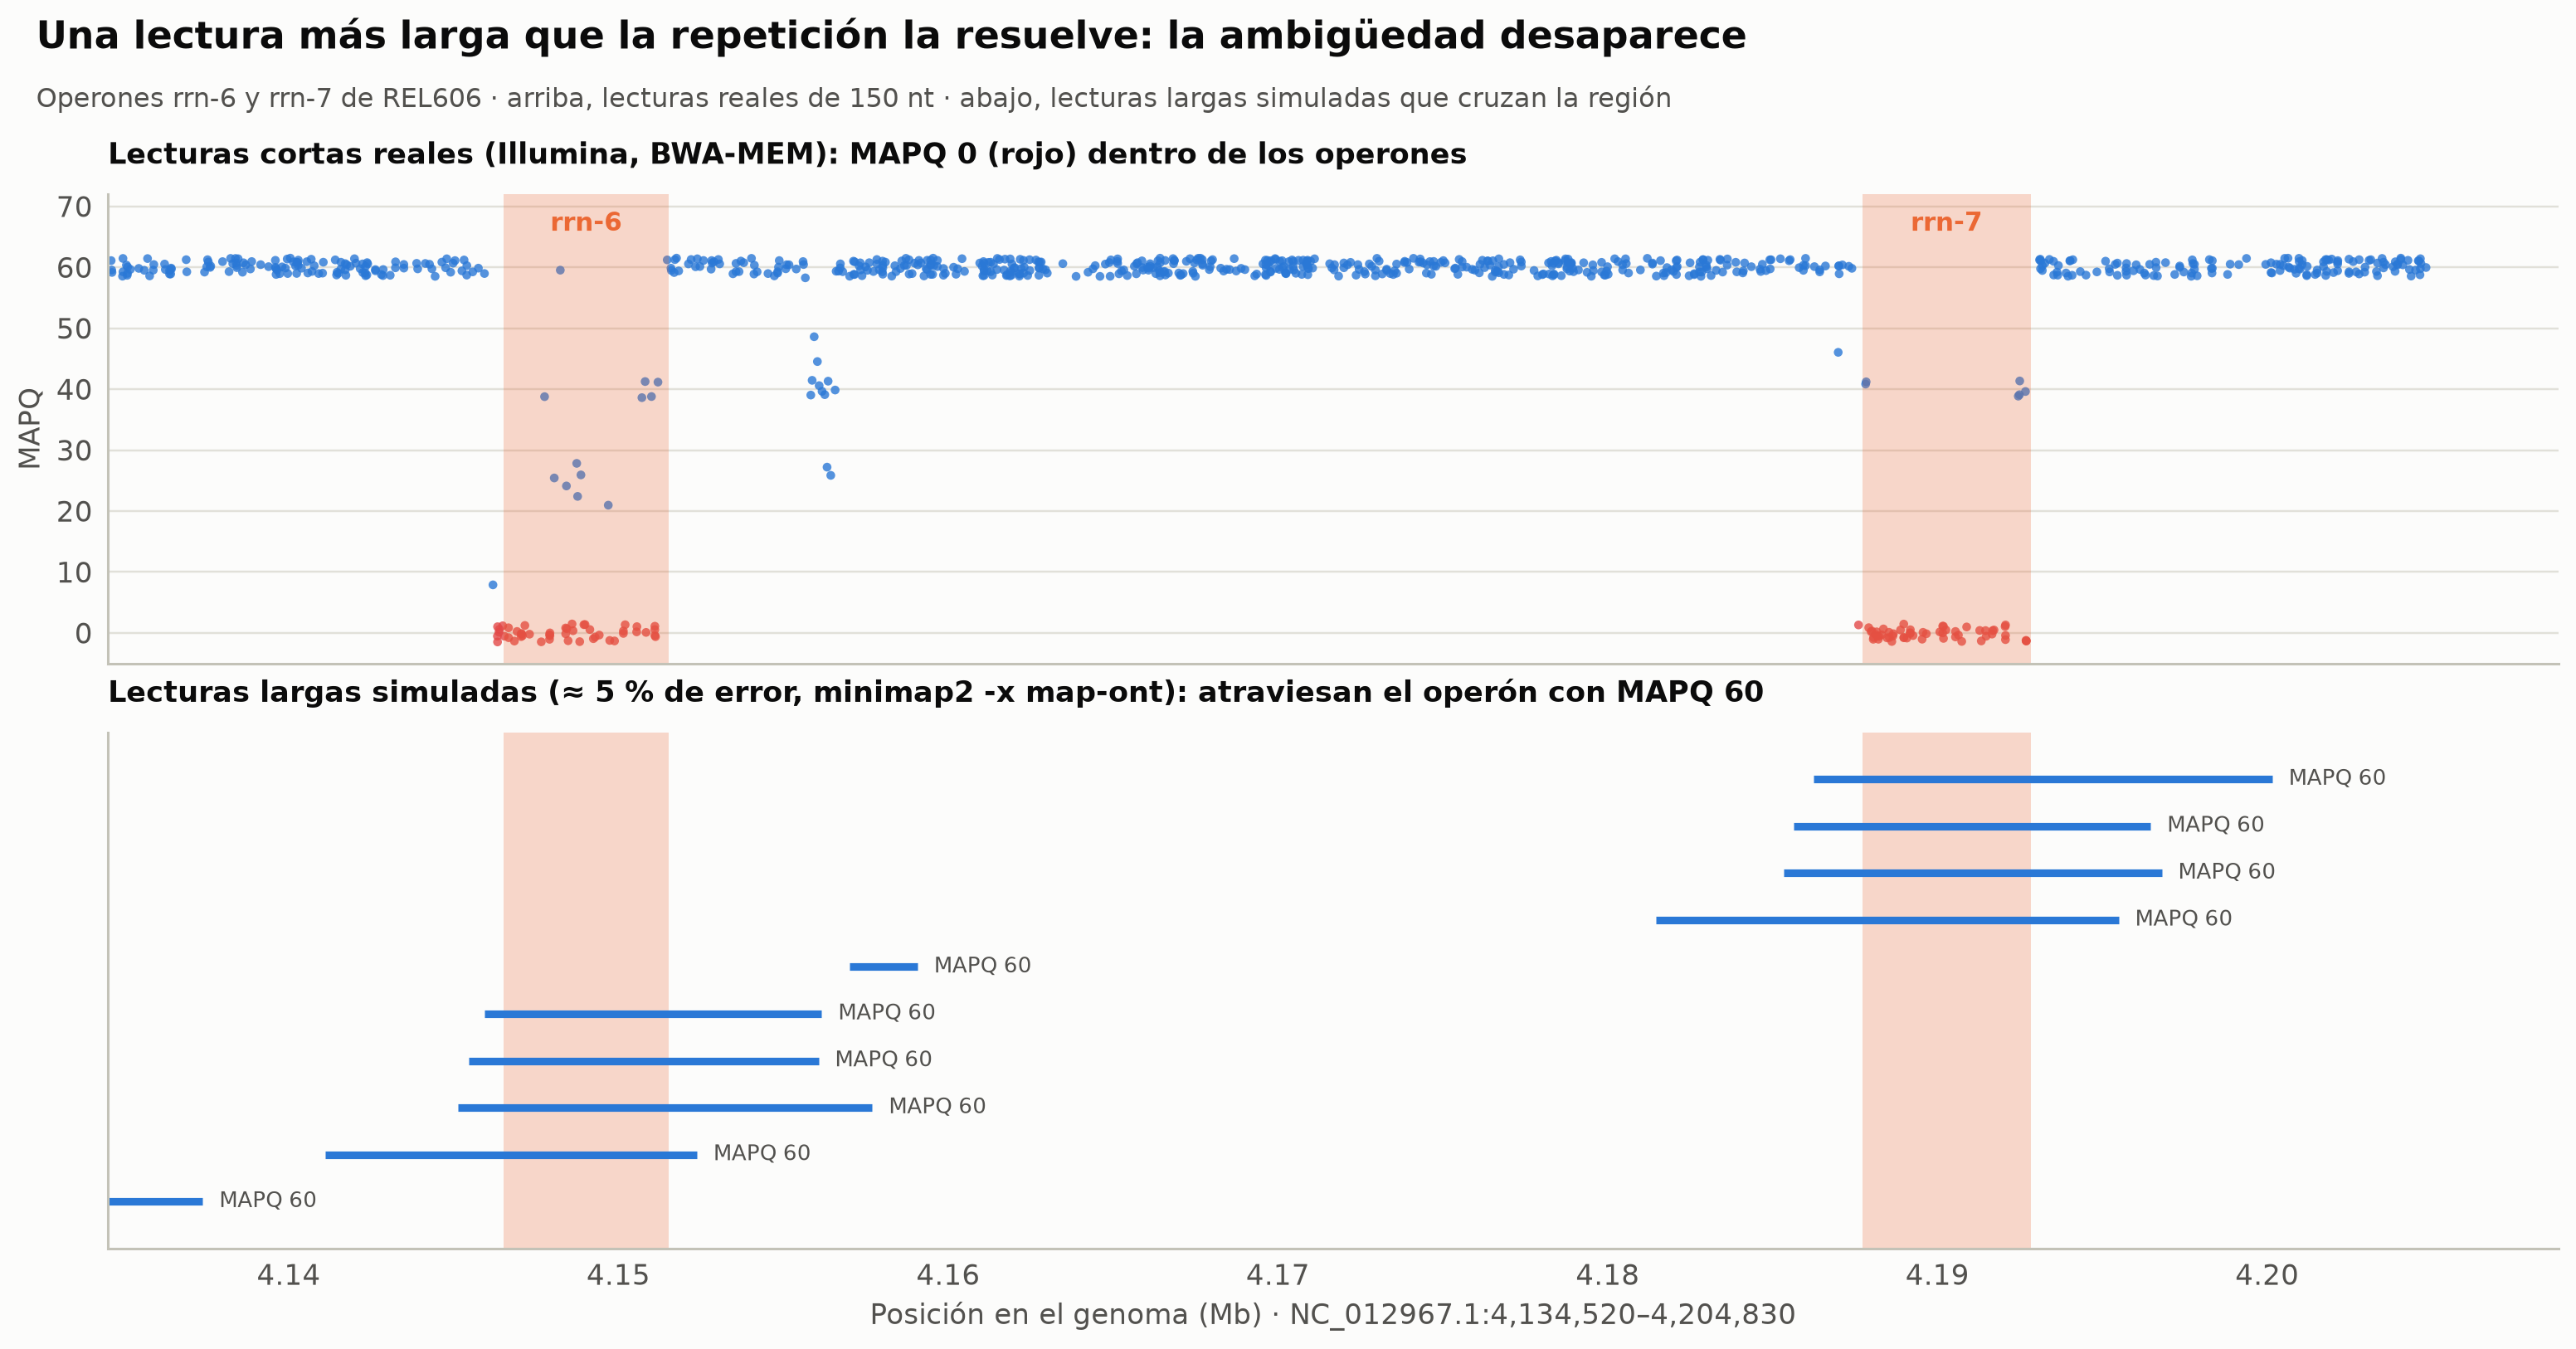

In [61]:
op_show = operons.iloc[5:7]                                  # rrn-6 y rrn-7, a 36 kb uno del otro
w0, w1 = int(op_show.start.min() - 12_000), int(op_show.end.max() + 12_000)
fig, axes = plt.subplots(2, 1, figsize=(14, 6.6), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.1]))
ax = axes[0]
win_reads = mapped[(mapped.pos > w0) & (mapped.pos < w1)]
jit = rng.uniform(-1.5, 1.5, len(win_reads))
ax.scatter(win_reads.pos / 1e6, win_reads.mapq + jit, s=12,
           color=np.where(win_reads.mapq == 0, ec.RED, ec.BLUE), alpha=0.8)
for o in op_show.itertuples():
    ax.axvspan(o.start / 1e6, o.end / 1e6, color=ec.ORANGE, alpha=0.25, lw=0)
    ax.text((o.start + o.end) / 2e6, 66, o.name, ha="center", fontsize=10, color=ec.ORANGE, fontweight="bold")
ax.set_ylabel("MAPQ"); ax.set_ylim(-5, 72)
ax.set_title("Lecturas cortas reales (Illumina, BWA-MEM): MAPQ 0 (rojo) dentro de los operones", fontsize=11.5, loc="left")
ax = axes[1]
lr_win = paf[(paf.tend > w0) & (paf.tstart < w1)].sort_values("tstart")
for y_, r_ in enumerate(lr_win.itertuples()):
    col = ec.BLUE if r_.mapq >= 20 else ec.RED
    ax.plot([max(r_.tstart, w0) / 1e6, min(r_.tend, w1) / 1e6], [y_, y_], color=col, lw=3, solid_capstyle="butt")
    ax.text(min(r_.tend, w1) / 1e6 + 0.0005, y_, f"MAPQ {r_.mapq}", va="center", fontsize=8.5, color=ec.INK_2)
for o in op_show.itertuples():
    ax.axvspan(o.start / 1e6, o.end / 1e6, color=ec.ORANGE, alpha=0.25, lw=0)
ax.set_yticks([]); ax.set_ylim(-1, max(len(lr_win), 1))
ax.set_xlabel(f"Posición en el genoma (Mb) · {ACC}:{w0:,}–{w1:,}"); ax.set_xlim(w0 / 1e6, w1 / 1e6 + 0.004)
ax.set_title("Lecturas largas simuladas (≈ 5 % de error, minimap2 -x map-ont): atraviesan el operón con MAPQ 60",
             fontsize=11.5, loc="left")
ec.fig_title(fig, "Una lectura más larga que la repetición la resuelve: la ambigüedad desaparece",
             "Operones rrn-6 y rrn-7 de REL606 · arriba, lecturas reales de 150 nt · abajo, lecturas largas simuladas que cruzan la región")
plt.show()

> 🔎 **Qué observamos.** Arriba, las lecturas cortas que caen dentro de los operones tienen MAPQ 0 (rojo), mientras
> que las de los flancos tienen MAPQ 60. Abajo, las lecturas largas que atraviesan los operones se mapean con MAPQ 60,
> y en la posición correcta, a pesar de tener ≈ 5 % de error (unas 20 veces más que Illumina): sus extremos anclados en
> secuencia única deciden la copia. minimap2 las alinea con la misma estrategia de minimizers, cadenas y DP con
> bandas, sólo que con $k = 15$, $w = 10$ (el ajuste `map-ont`, que tolera más errores) y bandas y huecos pensados para
> lecturas largas. Por eso los ensambladores y los estudios de variantes estructurales combinan lecturas cortas
> (exactas, baratas) con largas (que resuelven repeticiones).

## ✍️ Ejercicios

**Ejercicio 1 — Minimizers a mano.** Calcule a mano los minimizers de `ACGTTGCATGTCGCATGATGCATGAGAGCT` con $k = 3$,
$w = 3$ y orden alfabético. ¿Qué densidad obtiene? Compruebe con `minimizers_naive` y compare con $2/(w+1)$.

**Ejercicio 2 — De MAPQ a probabilidad.** (a) ¿Qué probabilidad de error corresponde a MAPQ 13, 23 y 37?
(b) Con nuestro modelo, ¿qué MAPQ tendría una lectura con tres candidatas de puntuaciones 148, 143 y 143?
(c) ¿Cuántas lecturas del BAM real con MAPQ ≥ 20 esperaría que estén mal colocadas si la MAPQ fuera exacta?

**Ejercicio 3 — Regiones ciegas.** Usando `depth_q20_g`, calcule qué fracción de cada operón *rrn* y de las copias de
IS1 queda con profundidad 0 tras filtrar MAPQ ≥ 20, y compárela con el resto del genoma.

**Ejercicio 4 — Sensibilidad del mapeador de juguete.** Cambie $w$ a 25 (índice más pequeño) y vuelva a mapear 300
lecturas. ¿Cuánto se reduce el índice? ¿Cuántas lecturas se quedan sin anclas o cambian de posición?

In [62]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
ex_seq = "ACGTTGCATGTCGCATGATGCATGAGAGCT"
p_ = minimizers_naive(ex_seq, 3, 3)
n_k = len(ex_seq) - 2
print("Minimizers (1-based):", [x + 1 for x in p_], [ex_seq[x:x + 3] for x in p_])
print(f"Densidad: {len(p_)}/{n_k} = {len(p_) / n_k:.2f} · teoría 2/(w+1) = {2 / 4:.2f}")
print("En una secuencia corta la densidad fluctúa alrededor de la teoría; el orden alfabético suele dar algo más.")

Minimizers (1-based): [1, 2, 3, 6, 7, 8, 10, 12, 14, 15, 18, 21, 22, 25, 27] ['ACG', 'CGT', 'GTT', 'GCA', 'CAT', 'ATG', 'GTC', 'CGC', 'CAT', 'ATG', 'ATG', 'CAT', 'ATG', 'AGA', 'AGC']
Densidad: 15/28 = 0.54 · teoría 2/(w+1) = 0.50
En una secuencia corta la densidad fluctúa alrededor de la teoría; el orden alfabético suele dar algo más.


In [63]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for q in (13, 23, 37):
    print(f"MAPQ {q}: P(incorrecta) = 10^(-{q}/10) = {10 ** (-q / 10):.4f}")
print("MAPQ con puntuaciones (148, 143, 143):", mapq_from_scores([148, 143, 143]),
      "→ dos alternativas a 5 puntos: P(incorrecta) ≈ 2·0.01/(1 + 2·0.01) ≈ 0.02 → MAPQ ≈ 17")
hq = m_[m_.mapq >= 20]
print(f"Lecturas con MAPQ ≥ 20: {len(hq):,}; errores esperados = Σ 10^(-MAPQ/10) = {np.sum(10 ** (-hq.mapq / 10)):.2f}")

MAPQ 13: P(incorrecta) = 10^(-13/10) = 0.0501
MAPQ 23: P(incorrecta) = 10^(-23/10) = 0.0050
MAPQ 37: P(incorrecta) = 10^(-37/10) = 0.0002
MAPQ con puntuaciones (148, 143, 143): 17 → dos alternativas a 5 puntos: P(incorrecta) ≈ 2·0.01/(1 + 2·0.01) ≈ 0.02 → MAPQ ≈ 17
Lecturas con MAPQ ≥ 20: 58,380; errores esperados = Σ 10^(-MAPQ/10) = 0.40


In [64]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
def zero_frac(starts, ends, depth):
    return np.mean(np.concatenate([depth[s - 1:e] == 0 for s, e in zip(starts, ends)]))
print(f"Operones rrn: {zero_frac(operons.start, operons.end, depth_q20_g):.1%} de bases sin cobertura con MAPQ ≥ 20 "
      f"(sin filtro: {zero_frac(operons.start, operons.end, depth_all_g):.1%})")
print(f"Copias de IS1: {zero_frac(is1.start, is1.end, depth_q20_g):.1%} "
      f"(sin filtro: {zero_frac(is1.start, is1.end, depth_all_g):.1%})")
print(f"Genoma completo: {np.mean(depth_q20_g == 0):.1%} (sin filtro: {np.mean(depth_all_g == 0):.1%})")

Operones rrn: 74.3% de bases sin cobertura con MAPQ ≥ 20 (sin filtro: 16.8%)
Copias de IS1: 29.7% (sin filtro: 14.6%)
Genoma completo: 21.0% (sin filtro: 20.1%)


In [65]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
saved = (W, g_pos, g_val, g_strand)
W = 25
g_pos, g_val, g_strand = minimizers(genome, K, W)
o_ = np.argsort(g_val, kind="stable"); g_pos, g_val, g_strand = g_pos[o_], g_val[o_], g_strand[o_]
print(f"Índice con w = 25: {len(g_pos):,} minimizers ({len(g_pos) / len(saved[1]):.0%} del índice con w = 11)")
changed = no_anchor = 0
for s, p0 in zip(seqs1[:300], toy.toy_pos[:300]):
    r_ = toy_map(s)
    if r_ is None:
        no_anchor += 1
    elif abs(r_["pos"] - p0) > 5:
        changed += 1
print(f"De 300 lecturas: {no_anchor} sin anclas y {changed} en otra posición (casi siempre repeticiones)")
W, g_pos, g_val, g_strand = saved                    # restaurar el índice original

Índice con w = 25: 356,749 minimizers (46% del índice con w = 11)


De 300 lecturas: 3 sin anclas y 1 en otra posición (casi siempre repeticiones)


## 📌 Resumen

* **Mapear** es resolver $(\hat u,\hat v) = \arg\max_{u\le v}\max\{S(q, R_{u..v}), S(\bar q, R_{u..v})\}$ (las dos
  hebras) **y** cuantificar la confianza. La programación dinámica completa es inviable ($\sim 10^{13}$ celdas aquí,
  $2.9\times10^{20}$ en un humano a 30×); los mapeadores **indexan** el genoma y siguen la estrategia **semilla →
  encadenamiento → extensión**, y la extensión se detiene con el criterio ***X-drop***.
* **BWA-MEM** busca semillas **SMEM** (coincidencias exactas supermaximales) con un índice FM basado en la transformada de
  Burrows–Wheeler (tras BWA-*backtrack* y BWA-SW; Bowtie 2 usa también un índice FM); **minimap2** usa **minimizers**
  en una tabla hash. Ambos encadenan anclas colineales, minimap2 con $f(i) = \max\{\max_{j<i}\{f(j)+\alpha(j,i)-\beta(j,i)\}, w_i\}$
  sobre los 50 predecesores más cercanos, y extienden con DP en **bandas**.
* Un **minimizer** es el menor $k$-mero de cada ventana de $w$ $k$-meros. Con un orden por hash, su densidad es
  $\delta \approx 2/(w+1)$ (verificado en REL606: 0.1667 con $w = 11$), y dos secuencias que comparten $w + k - 1$ nt idénticos
  comparten un minimizer.
* **MAPQ** $= -10\log_{10}\big(1-\Pr(\hat u\mid q)\big)$: 20.0 en el ejemplo Q35 frente a Q25 + Q30; 3.01 con dos
  copias idénticas, aunque por convención se escribe 0 cuando `AS` = `XS`. minimap2 usa
  $40(1-f_2/f_1)\min\{1,a/10\}\ln f_1$ (53 con $f_2 = 150$, 5 con $f_2 = 195$). Depende de la distancia entre la mejor
  y la segunda mejor candidata, no de lo bien que alinea la lectura. En las repeticiones (7 operones *rrn*, decenas de IS1)
  las lecturas cortas reciben MAPQ 0 y se colocan al azar (86 % mal colocadas en la simulación, ≈ 6/7).
* El flujo profesional: `bwa index` → `bwa mem -R` → `samtools fixmate -m` → `sort` → `markdup` → `index` →
  `flagstat`/`stats`/`idxstats`/`depth`; `-F 0x904` deja un registro primario por lectura mapeada, y **CRAM** guarda
  sólo las diferencias con la referencia. **pysam** permite leer cada campo del BAM desde Python.
* Los pares se puntúan con $S_{ij} = S_i + S_j - \min\{-a\log_4 P(d_{ij}), U\}$ bajo un modelo normal del inserto;
  los pares fuera de $\mu\pm4\sigma$ son discordantes. La referencia importa: T2T-CHM13 añadió ≈ 200 Mb que GRCh38 no
  tenía.
* En los datos reales de la 6.2: 99 % mapeado, 97 % en pares propios **FR**, insertos Nextera muy variables (mediana
  ≈ 550 pb), pares que **cruzan el origen** del cromosoma circular, diferencias que crecen al final de la lectura y
  colas de adaptador recortadas suavemente (`S`).
* BWA-MEM y minimap2 coinciden en más del 98 % de las posiciones; sus diferencias están en las lecturas ambiguas y en
  **valores por defecto** (como `-F 800` de minimap2 para los pares propios).
* Las **lecturas largas** más largas que la repetición la resuelven, aun con 5 % de error.

## 📚 Para profundizar

* Li, H. & Durbin, R. (2009). Fast and accurate short read alignment with Burrows–Wheeler transform. *Bioinformatics*
  25(14): 1754–1760.
* Li, H. & Durbin, R. (2010). Fast and accurate long-read alignment with Burrows–Wheeler transform. *Bioinformatics*
  26(5): 589–595.
* Langmead, B. & Salzberg, S. L. (2012). Fast gapped-read alignment with Bowtie 2. *Nature Methods* 9(4): 357–359.
* Li, H., Ruan, J. & Durbin, R. (2008). Mapping short DNA sequencing reads and calling variants using mapping quality
  scores. *Genome Research* 18(11): 1851–1858.
* Li, H. (2013). Aligning sequence reads, clone sequences and assembly contigs with BWA-MEM. *arXiv*:1303.3997.
* Li, H. (2018). Minimap2: pairwise alignment for nucleotide sequences. *Bioinformatics* 34(18): 3094–3100.
* Li, H., Handsaker, B., Wysoker, A., Fennell, T., Ruan, J., Homer, N., Marth, G., Abecasis, G., Durbin, R. & 1000 Genome
  Project Data Processing Subgroup (2009). The Sequence Alignment/Map format and SAMtools. *Bioinformatics* 25(16):
  2078–2079.
* Danecek, P., Bonfield, J. K., Liddle, J., Marshall, J., Ohan, V., Pollard, M. O., Whitwham, A., Keane, T., McCarthy,
  S. A., Davies, R. M. & Li, H. (2021). Twelve years of SAMtools and BCFtools. *GigaScience* 10(2): giab008.
* Faust, G. G. & Hall, I. M. (2014). SAMBLASTER: fast duplicate marking and structural variant read extraction.
  *Bioinformatics* 30(17): 2503–2505.
* Schleimer, S., Wilkerson, D. S. & Aiken, A. (2003). Winnowing: local algorithms for document fingerprinting.
  *Proceedings of the 2003 ACM SIGMOD International Conference on Management of Data*: 76–85.
* Schneider, V. A. *et al.* (2017). Evaluation of GRCh38 and de novo haploid genome assemblies demonstrates the
  enduring quality of the reference assembly. *Genome Research* 27(5): 849–864.
* Nurk, S. *et al.* (2022). The complete sequence of a human genome. *Science* 376(6588): 44–53.
* Roberts, M., Hayes, W., Hunt, B. R., Mount, S. M. & Yorke, J. A. (2004). Reducing storage requirements for biological
  sequence comparison. *Bioinformatics* 20(18): 3363–3369.
* Jeong, H., Barbe, V., Lee, C. H., Vallenet, D., Yu, D. S., Choi, S.-H., *et al.* (2009). Genome sequences of
  *Escherichia coli* B strains REL606 and BL21(DE3). *Journal of Molecular Biology* 394(4): 644–652.
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*
  536(7615): 165–170. (Origen de las lecturas: BioProject PRJNA295606.)
* Documentación: manual de BWA (https://bio-bwa.sourceforge.net/bwa.shtml), de minimap2
  (https://lh3.github.io/minimap2/minimap2.html), de samtools (https://www.htslib.org/doc/samtools.html) y de pysam
  (https://pysam.readthedocs.io).

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)